# 00 · Foundations — the words the cookbook assumes

The notebook that comes **before** everything else. It builds the core vocabulary — potential
outcomes, counterfactuals, confounding, selection bias, randomization, identification, the
do-operator, DAGs, ATE vs ATT vs CATE — from nothing, with one marketing example, and works through
an **estimator ladder**: naive → regression-adjust → IPW → doubly-robust — the naive rung fails on
purpose, and each adjustment rung then recovers a known effect from confounded data. It then shows
what **no rung can fix** (an unmeasured confounder, broken overlap), runs the full **Bayesian
workflow** — prior → likelihood → posterior → R-hat/ESS — on one small model, replays the lesson on
the most famous real dataset in causal inference, and closes by **pricing the identification error
in euros** and mapping every later notebook to its estimand.

No new theory here — it mirrors `docs/causal_inference_primer.pdf`. Skim it once and every later
notebook reads as a *named tool* rather than new vocabulary.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from cmp import classical as cl, dgp, estimators as est, plots
from cmp.cache import load_or_run   # fit once, load forever — a live lecture never waits on NUTS
plots.use_style()
rng = np.random.default_rng(0)
FAST = os.environ.get("CMP_FAST", "1") == "1"   # FAST=1: fewer seeds/bootstraps in the multi-seed ladder

## 1 · Treatment, unit, outcome — and the counterfactual

A **treatment** is any action whose effect we want (send a discount, show an ad, change a price).
The **unit** receives it (customer, store, region); the **outcome** is what we measure after.

For binary $T\in\{0,1\}$ each unit has **two potential outcomes**: $Y(1)$ if treated, $Y(0)$ if not.
We only observe **one** — $Y=T\,Y(1)+(1-T)\,Y(0)$ — so the individual effect $Y(1)-Y(0)$ is never
seen. This **fundamental problem of causal inference** is a *missing-data* problem; everything
downstream is principled imputation of the half of the table we didn't get to see.


In [2]:
# Three customers, both potential outcomes — we OBSERVE only the branch matching the treatment given.
demo = pd.DataFrame({"customer": ["Anna","Ben","Cara"],
    "Y(0) not emailed": [30, 55, 20], "Y(1) emailed": [80, 60, 22]})
demo["individual effect"] = demo["Y(1) emailed"] - demo["Y(0) not emailed"]
demo["emailed?"] = ["yes","no","yes"]
demo["→ OBSERVED"] = [80, 55, 22]; demo["→ MISSING (counterfactual)"] = [30, 60, 20]
demo

,customer,Y(0) not emailed,Y(1) emailed,individual effect,emailed?,→ OBSERVED,→ MISSING (counterfactual)
0,Anna,30,80,50,yes,80,30
1,Ben,55,60,5,no,55,60
2,Cara,20,22,2,yes,22,20


The trap in plain sight: comparing the **emailed** customers' *observed* spend to the **not-emailed** ones' is **not** the true average effect — that naive observed contrast is **confounded** by *who got chosen* to be emailed, and the gap between it and the real individual-effect average is the entire subject of this cookbook.

## 2 · From individuals to averages, and the enemy: confounding

Decisions run on **averages**: the **Average Treatment Effect** $\text{ATE}=\mathbb E[Y(1)-Y(0)]$.
The whole difficulty collapses onto one word — **comparable**: to estimate $\mathbb E[Y(0)]$ for the
treated we need a control group *like them in every way except the treatment*.

**Confounding** breaks comparability. If we email our *loyal* customers and compare to *casual*
controls, loyal customers spend more anyway — "loyalty" drove both who got emailed and how much they
spend. A **confounder** is a common cause of treatment and outcome; the naive "treated − control"
difference then blames the treatment for a gap that was really about *who ended up in each group*.


## 3 · The gold standard, and life without it

**Randomization** (an A/B test) annihilates confounding by design: a coin flip makes treatment
independent of every confounder, measured or not, so $\text{ATE}=\mathbb{E}[Y\mid T{=}1]-\mathbb{E}[Y\mid T{=}0]$ — a plain difference of means. We can *see* this: the same simulator run in
**randomized** vs **observational** mode gives the same true effect, but only the randomized naive
estimate is unbiased.

**The data-generating model behind this demo** — `dgp.uplift_customers`, the notebook-01 simulator
(its full equations are in notebook 01, step 2). Each customer has features $x$ (recency $R$,
frequency $F$, monetary $M$, tenure, engagement $E$), a known baseline $\mu_0(x)$, and a planted
effect $\tau(x)$, with spend

$$
Y = \mu_0(x) + \tau(x)\,T + \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\, 8^{2}).
$$

The **only** thing that differs between the two bars is how $T$ is assigned:

$$
\begin{aligned}
\text{randomized: } & T \sim \text{Bernoulli}(\tfrac12)\\[2pt]
\text{observational: } & T \sim \text{Bernoulli}\Big(\sigma\big(1.8\,(E-0.4)
  + 1.2\,\tfrac{150-R}{150} + 0.15\,(F-5)\big)\Big),
\end{aligned}
$$

where $\sigma(z)=1/(1+e^{-z})$ is the **logistic (sigmoid)** function — it maps any score to a
probability between 0 and 1, so a higher score just means a higher chance of being emailed.

i.e. marketers historically emailed engaged, recently-active customers — the same characteristics
that raise spend through $\mu_0(x)$. Identical true effect in both worlds; only the *assignment
mechanism* changes, and that alone moves the naive estimate.

**Predict before you run.** Marketers emailed engaged, recently active customers — the same traits that
raise spend through $\mu_0(x)$. Will the observational naive bar overshoot or undershoot the true ATE, and
is that miss noise or bias? Decide from the assignment equations above, then check against the printed
SE-distance lines.

true ATE €5.6  ·  randomized naive €4.8 ± 0.6 (SE)  ·  observational naive €9.7 ± 0.6 (SE)

Similar sampling noise (SE €0.6 randomized, €0.6 observational), opposite reasons for missing the truth:
  · randomized €4.8 is 1.2 SE from €5.6 — pure NOISE (unbiased; the gap shrinks like 1/sqrt(n)).
  · observational €9.7 is 6.5 SE from €5.6 — that gap is BIAS (it does NOT shrink with n).

Decision at €8/contact: the TRUE effect €5.6 is BELOW €8, so emailing everyone does NOT pay.
But the confounded naive €9.7 is ABOVE €8 and would (wrongly) say 'email everyone' — the same identification error, now flipping a real go/no-go.


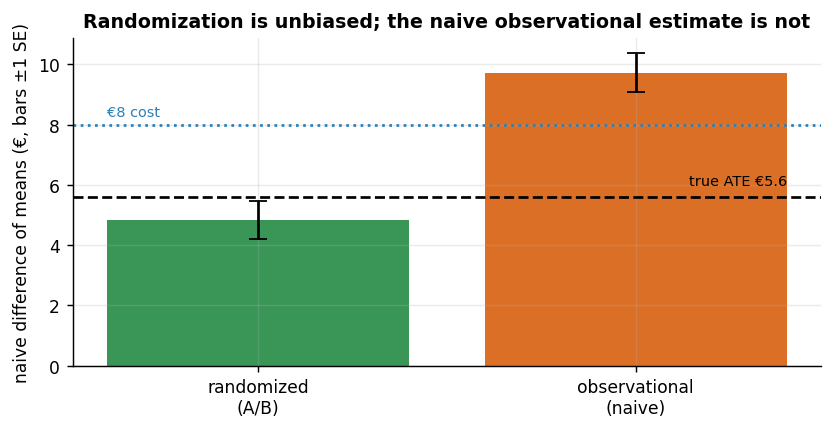

In [3]:
COST = 8.0
rand = dgp.uplift_customers(n=3000, regime="randomized", seed=1)
obs  = dgp.uplift_customers(n=3000, regime="observational", seed=1)
def naive_se(d):                                    # difference of means + its standard error
    yt, yc = d.loc[d["T"]==1, "y"].values, d.loc[d["T"]==0, "y"].values
    return yt.mean() - yc.mean(), np.sqrt(yt.var(ddof=1)/len(yt) + yc.var(ddof=1)/len(yc))
(dr, ser), (do, seo) = naive_se(rand), naive_se(obs)
true = rand.tau.mean()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(["randomized\n(A/B)", "observational\n(naive)"], [dr, do], yerr=[ser, seo],
       color=[plots.GREEN, plots.ORANGE], alpha=0.9, capsize=5, ecolor="k")   # error bars = +/-1 SE
ax.axhline(true, color="k", ls="--"); ax.text(1.4, true+0.4, f"true ATE €{true:.1f}", ha="right", fontsize=8)
ax.axhline(COST, color=plots.BLUE, ls=":"); ax.text(-0.4, COST+0.3, f"€{COST:.0f} cost", fontsize=8, color=plots.BLUE)
ax.set_ylabel("naive difference of means (€, bars ±1 SE)")
ax.set_title("Randomization is unbiased; the naive observational estimate is not")
fig.tight_layout()
print(f"true ATE €{true:.1f}  ·  randomized naive €{dr:.1f} ± {ser:.1f} (SE)  ·  observational naive €{do:.1f} ± {seo:.1f} (SE)")
print(f"\nSimilar sampling noise (SE €{ser:.1f} randomized, €{seo:.1f} observational), opposite reasons for missing the truth:")
print(f"  · randomized €{dr:.1f} is {abs(dr-true)/ser:.1f} SE from €{true:.1f} — pure NOISE (unbiased; the gap shrinks like 1/sqrt(n)).")
print(f"  · observational €{do:.1f} is {abs(do-true)/seo:.1f} SE from €{true:.1f} — that gap is BIAS (it does NOT shrink with n).")
print(f"\nDecision at €{COST:.0f}/contact: the TRUE effect €{true:.1f} is BELOW €{COST:.0f}, so emailing everyone does NOT pay.\n"
      f"But the confounded naive €{do:.1f} is ABOVE €{COST:.0f} and would (wrongly) say 'email everyone' — the same "
      f"identification error, now flipping a real go/no-go.")

### The anatomy of the naive difference — selection bias, named

The orange bar's failure has an exact algebraic name. Write the naive contrast with the two observed
group means (always computable from a dashboard), use consistency ($Y=Y(1)$ when $T{=}1$, $Y=Y(0)$ when
$T{=}0$), and add-and-subtract the counterfactual mean $\mathbb E[Y(0)\mid T{=}1]$ — what the emailed
customers *would* have spent with no email:

$$
\underbrace{\mathbb E[Y\mid T{=}1]-\mathbb E[Y\mid T{=}0]}_{\text{naive difference (observable)}}
\;=\;
\underbrace{\mathbb E[Y(1)-Y(0)\mid T{=}1]}_{\text{ATT: effect on the treated}}
\;+\;
\underbrace{\mathbb E[Y(0)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]}_{\text{selection bias}}
$$

Two new words, both load-bearing for the whole cookbook:

- **ATT** $=\mathbb E[Y(1)-Y(0)\mid T{=}1]$ — the *average treatment effect on the treated*: the effect
  among the customers who actually got the email. It differs from the ATE whenever treatment was
  *targeted* (here, marketers historically emailed exactly the customers the email works best on), and
  it is the **estimand** — the precise quantity a method targets, the four of which §5 lays out — that
  difference-in-differences (notebook 08) and the LaLonde data below actually identify.
- **Selection bias** $=\mathbb E[Y(0)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]$ — how much more the emailed
  customers would have spent *even with no email*. A statement about **who** was chosen, not about what
  the email did.

Randomization makes $T$ independent of $Y(0)$, so the selection term is **exactly zero** and ATT $=$
ATE — that is the entire one-line proof behind the green bar. The simulator lets us watch the identity
balance, because it knows every customer's unobserved branch $Y(0)=Y-\tau\,T$:

In [4]:
# Verify the decomposition on the confounded sample: recover each customer's untreated
# branch Y(0) = y - tau*T (unobservable in real life; known in the simulator).
y0 = obs["y"] - obs["tau"] * obs["T"]
tr, ct = obs["T"] == 1, obs["T"] == 0
naive_obs = obs.loc[tr, "y"].mean() - obs.loc[ct, "y"].mean()
att       = obs.loc[tr, "tau"].mean()                     # ATT: mean planted effect among the emailed
sel_bias  = y0[tr].mean() - y0[ct].mean()                 # selection bias: the Y(0) gap between arms
ate       = obs["tau"].mean()
print(f"naive difference       €{naive_obs:6.2f}")
print(f"  = ATT                €{att:6.2f}   (effect ON THE EMAILED — targeting favoured high-effect customers)")
print(f"  + selection bias     €{sel_bias:6.2f}   (the emailed would have spent this much more ANYWAY)")
print(f"  check: ATT + bias  = €{att + sel_bias:6.2f}   (the identity balances to machine precision, in-sample)")
print(f"\nATE (all customers)    €{ate:6.2f}  →  the naive−ATE gap of €{naive_obs - ate:.2f} splits into")
print(f"  €{sel_bias:.2f} of selection bias + €{att - ate:.2f} of targeting gap (ATT − ATE: past sends favoured high-τ customers).")
print(f"\nRandomization zeroes the €{sel_bias:.2f} selection term by construction (T ⊥ Y(0)) and equates ATT with ATE —")
print("that single fact is the whole content of the green bar above.")

naive difference       €  9.73
  = ATT                €  7.34   (effect ON THE EMAILED — targeting favoured high-effect customers)
  + selection bias     €  2.39   (the emailed would have spent this much more ANYWAY)
  check: ATT + bias  = €  9.73   (the identity balances to machine precision, in-sample)

ATE (all customers)    €  5.58  →  the naive−ATE gap of €4.15 splits into
  €2.39 of selection bias + €1.76 of targeting gap (ATT − ATE: past sends favoured high-τ customers).

Randomization zeroes the €2.39 selection term by construction (T ⊥ Y(0)) and equates ATT with ATE —
that single fact is the whole content of the green bar above.


Without randomization we must **identify** the effect using assumptions:

1. **Unconfoundedness** $\{Y(0),Y(1)\}\perp T\mid X$ (the symbol $\perp$ reads "is independent of") —
   within units alike on measured $X$, treatment is as-good-as-random. *(The big, untestable one.)*
2. **Positivity / overlap** $0<e(x)<1$, $e(x)=P(T{=}1\mid X{=}x)$ the **propensity score** — every
   kind of unit could have gone either way.
3. **SUTVA** — no interference, one version of treatment.

Under these, the **adjustment (g-)formula** compares like-with-like *within* strata of $X$ and averages
back up:
$\text{ATE}=\mathbb E_X[\mathbb E[Y\mid T{=}1,X]-\mathbb E[Y\mid T{=}0,X]]$.


### The adjustment formula at work — stratify, compare like with like, average back up

Before the ladder automates it (§6), watch the g-formula work once **by hand**. For a discrete
confounder the formula on means reads

$$
\widehat{\text{ATE}}_{\text{strat}} \;=\; \sum_{k}\frac{n_k}{n}\,\big(\bar Y_{1k}-\bar Y_{0k}\big),
$$

where $k$ indexes strata of the confounder, $n_k$ is the number of customers in stratum $k$ (out of $n$
total), and $\bar Y_{1k},\bar Y_{0k}$ are the treated / control mean outcomes **within** stratum $k$:
compare only like with like, then average the within-stratum contrasts, each weighted by its stratum's
population share. The demo data is `dgp.dag_control_demo` — the same dataset §6's ladder and notebook 05
dissect (full equations in §6): one observed confounder, loyalty $L$, drives both who gets the email and
spend, and the planted effect is exactly **€6**. We cut $L$ into five quintile strata and run the
formula:

**Predict before you run.** Loyalty drives both the send and the spend. Before the table prints: will the
`% emailed` column climb or fall across the quintiles, and will the stratified average land above or below
the pooled contrast? Check both against the printed table and its two summary lines.

stratum loyalty range   n  % emailed  diff within (€)
     Q1  [-3.5, -0.8] 600      25.83             6.08
     Q2  [-0.8, -0.3] 600      41.83             5.64
     Q3   [-0.3, 0.2] 600      48.67             6.32
     Q4    [0.2, 0.8] 600      61.17             5.29
     Q5    [0.8, 3.6] 600      76.33             6.74

pooled naive difference       €9.26   (mixes the loyalty composition gap into the 'effect')
stratified weighted average   €6.02   (true planted effect €6)


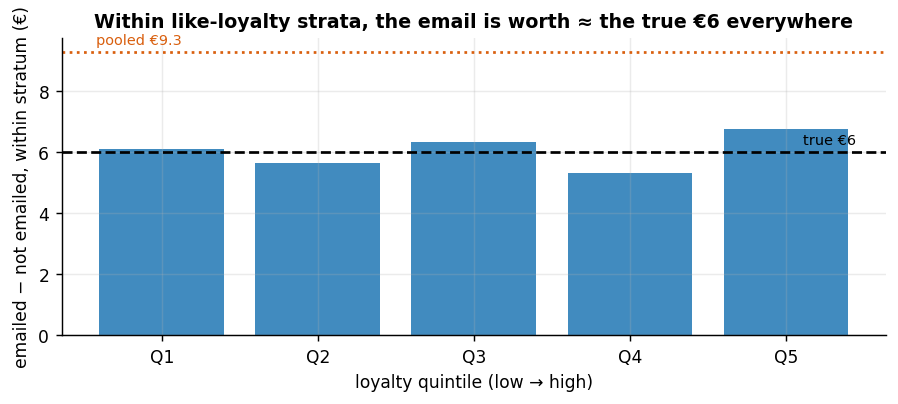

In [5]:
d0, true0 = dgp.dag_control_demo(n=3000, seed=17)           # the exact data §6's ladder will use
strat = pd.qcut(d0["loyalty"], 5, labels=False)              # five like-loyalty bins
rows = []
for k in range(5):
    g = d0[strat == k]
    rows.append({"stratum": f"Q{k+1}",
                 "loyalty range": f"[{g['loyalty'].min():.1f}, {g['loyalty'].max():.1f}]",
                 "n": len(g), "% emailed": 100 * g["email"].mean(),
                 "diff within (€)": g.loc[g.email == 1, "spend"].mean() - g.loc[g.email == 0, "spend"].mean()})
tab = pd.DataFrame(rows)
strat_ate = float(np.average(tab["diff within (€)"], weights=tab["n"]))
pooled = d0.loc[d0.email == 1, "spend"].mean() - d0.loc[d0.email == 0, "spend"].mean()
print(tab.round(2).to_string(index=False))
print(f"\npooled naive difference       €{pooled:.2f}   (mixes the loyalty composition gap into the 'effect')")
print(f"stratified weighted average   €{strat_ate:.2f}   (true planted effect €{true0:.0f})")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(tab["stratum"], tab["diff within (€)"], color=plots.BLUE, alpha=0.9)
ax.axhline(true0, color="k", ls="--"); ax.text(4.45, true0 + 0.25, f"true €{true0:.0f}", ha="right", fontsize=8)
ax.axhline(pooled, color=plots.ORANGE, ls=":"); ax.text(-0.42, pooled + 0.25, f"pooled €{pooled:.1f}", fontsize=8, color=plots.ORANGE)
ax.set_xlabel("loyalty quintile (low → high)"); ax.set_ylabel("emailed − not emailed, within stratum (€)")
ax.set_title("Within like-loyalty strata, the email is worth ≈ the true €6 everywhere")
fig.tight_layout()

**Read-out.** *Within* like-loyalty customers the email is worth roughly the same ≈€6 everywhere; the
pooled ≈€9 was never an email effect. The extra ≈€3 is the composition gap the `% emailed` column makes
visible — the share of emailed customers climbs steadily with loyalty, so the pooled contrast compares
loyal emailed customers with casual controls. Every rung of §6's ladder is a smarter way of doing exactly
this stratification: **regression** replaces the five bins with a line, **IPW** re-weights each arm so the
loyalty mix matches the population, **AIPW** does both at once. (Finer strata would shave the small
residual within-stratum confounding — which is precisely why we hand the job to fitted models next.)

## 4 · Seeing vs doing (the do-operator), DAGs, colliders

**Observing** $X=x$ (units where $X$ happened to be $x$, carrying all the reasons it got there) differs
from **doing** $do(X=x)$ (reaching in and *setting* it). Causal effects are about *doing*. In notation:
$P(Y\mid T{=}t)$ describes the units we *happened to observe* at $T{=}t$; $P(Y\mid do(T{=}t))$ describes
what $Y$ would look like if we *forced* everyone to $t$. Confounding is precisely their disagreement —
in the stratification demo just above, "seeing" gave ≈€9 while "doing" is worth the true €6. When the
backdoor variables $X$ are measured, the **backdoor adjustment formula** converts seeing into doing:

$$
P\big(y\mid do(T{=}t)\big)\;=\;\sum_{x}P\big(y\mid T{=}t,\,X{=}x\big)\,P(X{=}x),
$$

i.e. condition on $X{=}x$, then average over the *population* distribution of $X$ — not over its
distribution within an arm, which is what the naive contrast implicitly does. Taking means turns this
into §3's g-formula; the stratification table above **is** this equation executed by hand. A **DAG**
draws each variable as a node and each direct cause as an arrow, and tells you exactly what to control
for:

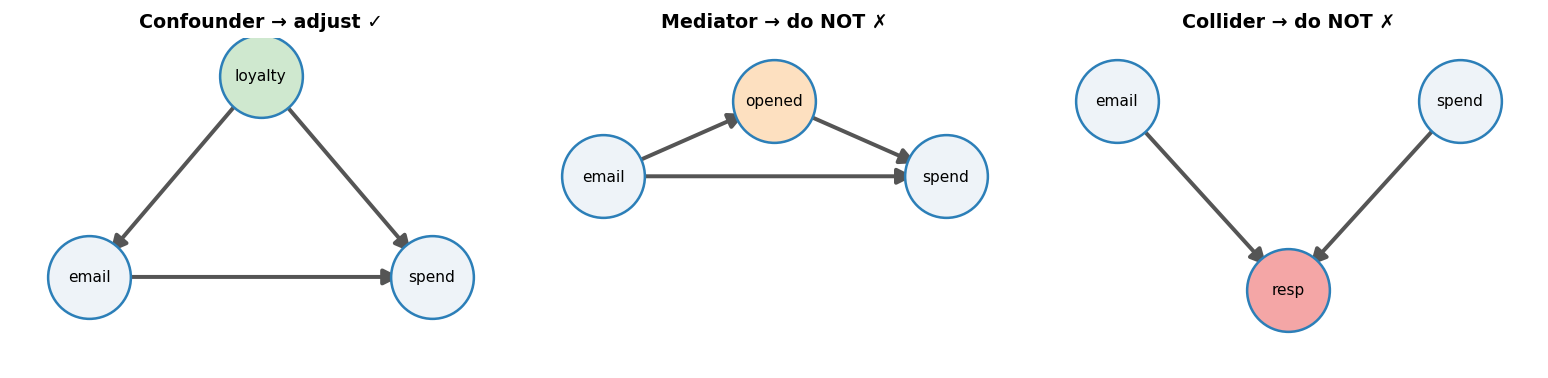

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.0))
plots.draw_dag(ax[0], {"loyalty":(0.5,1.0),"email":(0.05,0.2),"spend":(0.95,0.2)},
    [("loyalty","email"),("loyalty","spend"),("email","spend")], node_colors={"loyalty":"#cfe8cf"}, title="Confounder → adjust ✓")
plots.draw_dag(ax[1], {"email":(0.05,0.6),"opened":(0.5,0.9),"spend":(0.95,0.6)},
    [("email","opened"),("opened","spend"),("email","spend")], node_colors={"opened":"#fde0c0"}, title="Mediator → do NOT ✗")
plots.draw_dag(ax[2], {"email":(0.05,0.9),"spend":(0.95,0.9),"resp":(0.5,0.15)},
    [("email","resp"),("spend","resp")], node_colors={"resp":"#f4a6a6"}, title="Collider → do NOT ✗")
fig.tight_layout()

- **Backdoor path** (arrow *into* T, e.g. $T\leftarrow$ loyalty $\rightarrow Y$): block it by
  conditioning — the minimal blocking set is the $X$ in the adjustment formula.
- **Mediator** ($T\to M\to Y$): controlling for $M$ removes part of the effect you want.
- **Collider** ($T\to C\leftarrow Y$): conditioning on $C$ *manufactures* a spurious association.
  Notebook 05 is the whole "what to control for" story.


The third panel above draws exactly this: **response** is a *common effect* of email and spend (a collider), so conditioning on it opens a spurious email–spend path — which is why that panel is flagged "do NOT control."

**The collider trap, demonstrated with numbers** (the third DAG panel, made real). The most common
self-inflicted wound in marketing analytics is analysing only the customers who *responded* — opened,
clicked, replied, converted. "Responded" is a **common effect** of the treatment and the outcome, and
conditioning on a common effect *manufactures* association. Plant an email whose true effect is
**exactly zero**:

$$
T\sim\text{Bernoulli}(\tfrac12),\qquad
Y = 20 + 0\cdot T + \varepsilon,\quad \varepsilon\sim\mathcal N(0,\,5^2),\qquad
C=\mathbb 1\{\,1.2\,T + 1.2\,\tilde Y + \eta > 0.8\,\},\quad \eta\sim\mathcal N(0,1),
$$

where $T$ is the (randomized!) email, $Y$ is spend, $\tilde Y$ is spend standardized to unit variance,
$\mathbb 1\{\cdot\}$ is 1 when its bracketed condition holds and 0 otherwise,
and $C$ is "responded to the survey" — more likely if you were emailed *and* if you spend a lot. Because
$T$ is a coin flip, even the naive comparison is unbiased… until we filter on $C$:

(One design note: this trap is wired into the cookbook's own data too — `dgp.dag_control_demo`, the dataset
§3's stratification demo just used and §6's ladder is about to reuse, ships the same collider as its
`responded` column, caused by both the email and spend. Same dataset, many lessons.)

**Predict before you run.** The email's true effect is €0, and responding is *more* likely if you were
emailed and *more* likely if you spend a lot. Among responders only, will the estimated email effect come
out positive or negative? Derive the sign from the third DAG panel before running the cell, then check it
against the two printed coefficients.

In [7]:
rng_c = np.random.default_rng(42)
nC = 4000
Tc = rng_c.integers(0, 2, nC).astype(float)                    # randomized email
Yc = 20 + 0.0 * Tc + rng_c.normal(0, 5, nC)                    # planted email effect: exactly €0
Cc = (1.2 * Tc + 1.2 * (Yc - Yc.mean()) / Yc.std() + rng_c.normal(0, 1, nC)) > 0.8   # "responded"
_tcoef = lambda t_, y_: np.linalg.lstsq(np.column_stack([np.ones(len(t_)), t_]), y_, rcond=None)[0][1]
print(f"email coefficient, all customers         : €{_tcoef(Tc, Yc):+.2f}   (true effect €0 — randomized, unbiased)")
print(f"email coefficient, responders only (C=1) : €{_tcoef(Tc[Cc], Yc[Cc]):+.2f}   ({Cc.mean():.0%} of customers respond)")
print("\nAn email 'effect' out of thin air. Among responders, being emailed already explains the response,")
print("so the emailed responders needed LESS spend to get there — conditioning on the common effect induces")
print("a spurious negative email–spend link ('explaining away'). The same mechanics fire if you condition on")
print("opens, clicks or conversion: post-treatment variables stay OUT of the adjustment set. Notebook 05")
print("dissects this fully — including a collider your drawn DAG cannot even see.")

email coefficient, all customers         : €+0.03   (true effect €0 — randomized, unbiased)
email coefficient, responders only (C=1) : €-1.80   (44% of customers respond)

An email 'effect' out of thin air. Among responders, being emailed already explains the response,
so the emailed responders needed LESS spend to get there — conditioning on the common effect induces
a spurious negative email–spend link ('explaining away'). The same mechanics fire if you condition on
opens, clicks or conversion: post-treatment variables stay OUT of the adjustment set. Notebook 05
dissects this fully — including a collider your drawn DAG cannot even see.


## 5 · Which average? — the estimand table (ATE, ATT, CATE, LATE)

"The effect" is never one number: before choosing a method you must name **whose** average you want —
the **estimand**. The four that run this cookbook:

| estimand | formula | plain meaning | who identifies it |
|---|---|---|---|
| **ATE** | $\mathbb E[Y(1)-Y(0)]$ | effect on a *randomly chosen* customer — "does the program pay overall?" | A/B tests; the §6 ladder; program-level analogues in MMM / geo-lift / ITS (notebooks 06, 07, 10) |
| **ATT** | $\mathbb E[Y(1)-Y(0)\mid T{=}1]$ | effect *on those actually treated* (defined in §3's decomposition) | DiD (notebook 08), synthetic control (07) — and the LaLonde section below: its ≈ +\$1,800 is an effect *on the trainees* |
| **CATE** | $\tau(x)=\mathbb E[Y(1)-Y(0)\mid X{=}x]$ | effect *for customers like $x$* — the targeting quantity | uplift / heterogeneity notebooks 01–04 |
| **LATE** | $\mathbb E[Y(1)-Y(0)\mid \text{compliers}]$ | effect on the units an *instrument* (a nudge that shifts exposure without otherwise touching the outcome) actually moves | IV (notebook 11) |

They answer different business questions about the same campaign: ATE prices *"roll out to everyone?"*,
ATT audits *"what did our past sends earn?"*, CATE decides *"who's next?"*, and LATE is the honest scope
when you could only *encourage* exposure, not assign it. §3's decomposition already showed ATT ≠ ATE
the moment treatment is targeted. The histogram below shows why even the right ATE can still be the
wrong summary — targeting exists *because* $\tau(x)$ varies (if it were identical for everyone there
would be nobody to select):

ATE €5.6 < €8 cost → 'email no one'. Yet 29% of customers individually clear the €8 bar,
and 30% have a NEGATIVE effect (the email backfires on them). One number, opposite per-customer calls.


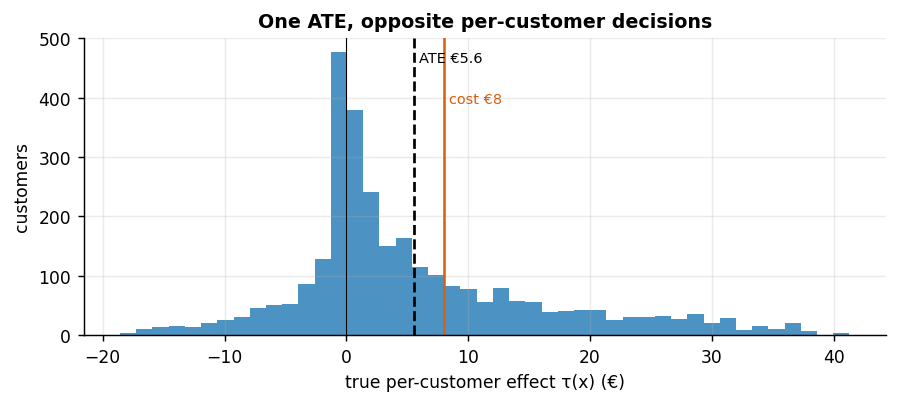

In [8]:
# The randomized sample from §3 carries the planted per-customer effect tau; the ATE hides its spread.
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(rand["tau"], bins=45, color=plots.BLUE, alpha=0.85)
ax.axvline(rand["tau"].mean(), color="k", ls="--")
ax.text(rand["tau"].mean() + 0.4, ax.get_ylim()[1] * 0.92, f"ATE €{rand['tau'].mean():.1f}", fontsize=8)
ax.axvline(COST, color=plots.ORANGE, lw=1.4)
ax.text(COST + 0.4, ax.get_ylim()[1] * 0.78, f"cost €{COST:.0f}", fontsize=8, color=plots.ORANGE)
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("true per-customer effect τ(x) (€)"); ax.set_ylabel("customers")
ax.set_title("One ATE, opposite per-customer decisions")
fig.tight_layout()
share_hi, share_neg = (rand["tau"] > COST).mean(), (rand["tau"] < 0).mean()
print(f"ATE €{rand['tau'].mean():.1f} < €{COST:.0f} cost → 'email no one'. Yet {share_hi:.0%} of customers individually clear the €{COST:.0f} bar,")
print(f"and {share_neg:.0%} have a NEGATIVE effect (the email backfires on them). One number, opposite per-customer calls.")

The spread *is* the business case: at €8 a contact the ATE says stop, while roughly three customers in
ten are individually profitable and a similar share would be actively harmed by the send. So whenever a
stakeholder quotes "the" effect, the first question is *which estimand* (the table above) and the second
is *how much it varies* — recovering the $\tau(x)$ that separates these groups is notebooks 01–04, and
§9 below prices what that separation is worth in euros.

## 6 · The estimator ladder — four ways to recover one effect

> **This section is the *classical* read: point estimates and confidence intervals — no
> likelihood, no priors, no sampler.** Everything below is estimated the way a competent
> analyst would estimate it without ever opening PyMC: a number, a standard error chosen to
> match the data (Welch for a difference of means, HC1 for a cross-section whose error
> structure is not known in advance, a percentile bootstrap where no closed form exists), and
> an interval built from it. In every *method* notebook (01–11) this move appears under its own
> heading, **Step 0 · the classical read**, before that notebook's Bayesian section. In the
> foundations notebook it *is* §6 — and §7.1 below explains exactly what the Bayesian layer adds
> to it, and what it does not.

Where the machinery enters. On the **confounded** data (true effect €6), we climb a ladder of
estimators, each leaning on different assumptions. On a **single** sample any estimate can land a
little off — an honest 90% interval misses about 1 time in 10 — so the test of a *good* estimator is
not "exact on this draw" but **unbiased**: centred on the truth *over repeated samples*, while the
naive difference stays stubbornly biased. The right-hand panel below shows exactly that across many
fresh samples.

1. **Naive** difference of means — ignores $X$, biased up. *(**Welch** standard error: it does not
   assume the two arms have equal variances. It costs almost nothing when they happen to be equal, and
   it is the only one of the two still right when they are not — and nobody tells you in advance which
   world you are in.)*
2. **Regression adjustment** — model $\mathbb E[Y\mid T,X]$, average the contrast (right if the outcome
   model is right). *(**HC1** heteroskedasticity-robust standard error — insurance against an error
   variance that moves with $X$. The ladder's DGP is **homoskedastic by construction** (see its equations
   below: the noise term does not depend on $L$), so here the insurance is nearly free rather than
   necessary — and the cell below **measures the premium**: it refits the identical model with an iid
   standard error and prints the gap, which is a fraction of a per cent. That is the honest case for a
   robust default. You cannot know the premium is small until you look, and real spend data is rarely so
   well behaved.)*
3. **IPW** — reweight by the inverse propensity so treated/control look alike (right if the propensity
   model is right). *(No closed-form standard error survives the estimated propensity, so: **bootstrap**.)*
4. **AIPW (doubly-robust)** — combine both; consistent if *either* model is right, reported here with a
   **bootstrap confidence interval** — an interval built by re-drawing the sample *with replacement*
   many times and re-estimating, so the spread of those re-estimates measures the sampling uncertainty
   (AIPW is a frequentist estimator — this is *not* a Bayesian credible interval).

The standard-error column is not bookkeeping. An interval built on the wrong standard error is worse
than no interval — it is a confident lie — so `cmp.classical` (the toolkit these fits use, `cl` in the
code) makes the covariance choice explicit and refuses to default it silently.

**The four estimators, written down.** Let $\hat m(t,x)\approx\mathbb E[Y\mid T{=}t,X{=}x]$ be a
fitted outcome model, $\hat e(x)\approx P(T{=}1\mid X{=}x)$ a fitted propensity, and $\bar Y_1,\bar Y_0$
the raw arm means over the $n$ customers. The four rungs are:

$$
\hat\tau_{\text{naive}}=\bar Y_1-\bar Y_0,
\qquad
\hat\tau_{\text{reg}}=\frac1n\sum_{i=1}^{n}\big[\hat m(1,x_i)-\hat m(0,x_i)\big],
\qquad
\hat\tau_{\text{IPW}}=\frac1n\sum_{i=1}^{n}\left[\frac{T_i\,Y_i}{\hat e(x_i)}-\frac{(1-T_i)\,Y_i}{1-\hat e(x_i)}\right],
$$

$$
\hat\tau_{\text{AIPW}}=\frac1n\sum_{i=1}^{n}\left[\hat m(1,x_i)-\hat m(0,x_i)
+\frac{T_i\big(Y_i-\hat m(1,x_i)\big)}{\hat e(x_i)}
-\frac{(1-T_i)\big(Y_i-\hat m(0,x_i)\big)}{1-\hat e(x_i)}\right].
$$

*Why IPW works:* weighting a treated unit by $1/\hat e(x_i)$ makes rarely-emailed kinds of customers
count for more, so the re-weighted treated arm matches the **whole population's** feature mix — the
balance panel two cells down shows the loyalty imbalance — its **standardized mean difference (SMD)**,
the gap in loyalty's mean between the arms measured in pooled standard deviations — collapsing from far
above the conventional **0.1** "balanced" threshold to ≈0 under exactly these weights.
*Why double robustness works, in two lines:* AIPW is the regression answer plus a weighted-residual
correction. If $\hat m$ is right, the residuals $Y-\hat m$ are mean-zero noise and the correction
vanishes — you keep rung 2. If instead $\hat e$ is right, the correction is an unbiased IPW estimate of
precisely the error a wrong $\hat m$ makes, and repairs it. Either model being correct suffices. In the
code below, `reg` computes $\hat\tau_{\text{reg}}$ with a linear $\hat m$ (one `lstsq` line — for a
linear model with a single $T$ coefficient the average contrast *is* that coefficient), `ipw` computes
$\hat\tau_{\text{IPW}}$ with a clipped logistic $\hat e$, and `est.aipw_ate` computes
$\hat\tau_{\text{AIPW}}$ with **cross-fitting** — five folds: $\hat m$ and $\hat e$ are fit on four folds
and evaluated on the held-out fifth, rotating, so no customer is ever scored by a model that was trained
on it (this removes an overfitting bias in the correction term) — plus its own propensity clip at
$[0.02,\,0.98]$, which winsorizes the weights without dropping anybody, so the estimand stays the
full-population ATE. One deliberate difference on that rung: its outcome model $\hat m$ is not rung 2's
straight line but a **gradient-boosted tree ensemble**, a flexible learner that never assumed linearity.
That is part of the design: AIPW here is an *independent* cross-check on the linear model, not the same
specification in different clothes — which is why its agreement with rung 2 is evidence about the
specification and not just about the arithmetic.

**The data-generating model for the ladder** — `dgp.dag_control_demo`, the same dataset notebook 05
dissects (equations there too). One **observed confounder**, loyalty $L \sim \mathcal N(0,1)$, and an
independent unobserved trait $G \sim \mathcal N(0,1)$ that adds outcome noise but never touches $T$
(so it is *not* a confounder):

$$
T = \text{email} \sim \text{Bernoulli}\big(\sigma(0.8\,L)\big), \qquad
Y = \text{spend} = 20 + 5\,L + 6\,T + 3\,G + \varepsilon, \quad \varepsilon \sim \mathcal N(0,\, 4^{2}).
$$

$L$ raises both the emailing probability and spend — the open backdoor that rung 1 (naive) ignores
and rungs 2–4 close, each in its own way: rung 2 models $L$ in the outcome, rung 3 models $L$ in the
propensity, rung 4 does both. The true ATE the ladder must recover is the **6**. Note what the outcome
equation does *not* contain: any term that lets the noise grow with $L$. The errors are homoskedastic —
which is exactly what turns the HC1-vs-iid line below into a *measurement* of the robustness premium
rather than a demonstration of its necessity.

[cache] MISS '00_ladder_multiseed' — fitting (this is the slow path)...


[cache] stored '00_ladder_multiseed' after 62s -> 00_ladder_multiseed-ec05df068520-d8bca55d42e7.pkl
The classical ladder on this sample — point estimate + 90% confidence interval, all in € (true €6):
  1. naive (difference in means)    9.26  [90% CI 8.84, 9.68]  ·  SE 0.25  ·  Welch (unequal variances)
  2. regression adjustment (OLS)    5.60  [90% CI 5.28, 5.92]  ·  SE 0.19  ·  HC1 heteroskedasticity-robust
  3. IPW                            5.80  [90% CI 5.37, 6.21]  ·  SE 0.26  ·  percentile bootstrap (500 resamples)
  4. AIPW (doubly robust)           5.57  [90% CI 5.27, 5.86]  ·  SE 0.20  ·  cross-fitted influence function, bootstrap (300 resamples)

The robustness premium, measured: rung 2's HC1 standard error is €0.19493; the iid one on the
identical fit is €0.19443 — a gap of +0.26%. On a homoskedastic DGP that is what HC1 is
supposed to cost: nothing. Report it anyway — the premium is paid before you know the error structure.

What this 90% confidence interval does NOT say: t

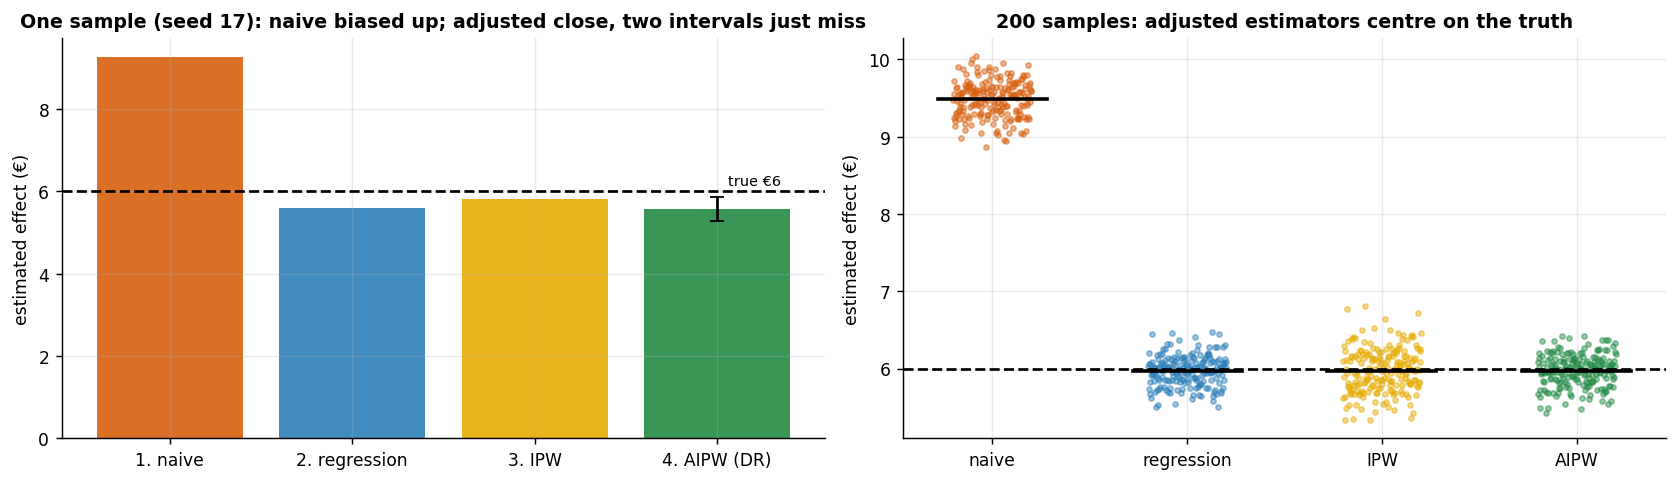

In [9]:
import textwrap

d, true_ate = dgp.dag_control_demo(n=3000, seed=17)
X = d[["loyalty"]].values; T = d["email"].values; Y = d["spend"].values

def ladder_pts(Xv, Tv, Yv):
    naive = Yv[Tv == 1].mean() - Yv[Tv == 0].mean()
    D = np.column_stack([np.ones(len(Yv)), Tv, Xv[:, 0]]); reg = np.linalg.lstsq(D, Yv, rcond=None)[0][1]
    e = np.clip(est.propensity_scores(Xv, Tv), 0.05, 0.95)  # clip bounds e away from 0/1 for a stable IPW correction; here it almost never binds
    ipw = (Tv * Yv / e).mean() - ((1 - Tv) * Yv / (1 - e)).mean()
    return naive, reg, ipw

aipw = est.aipw_ate(X, T, Y, seed=1, n_boot=300)      # cross-fitted: 5 folds, boosted-tree outcome, e clipped at 0.02
AIPW_FOLDS, AIPW_TRIM = 5, 0.02                       # est.aipw_ate's defaults, named so the book can cite them

# --- The classical read: four point estimates, four honest 90% CONFIDENCE intervals ------
# cmp.classical (cl) forces the covariance choice to be stated. Rungs 1-2 have closed-form
# SEs (Welch; HC1). Rungs 3-4 have none once the propensity is itself estimated, so they are
# bootstrapped: resample customers with replacement, refit, take percentiles.
NB_IPW = 200 if FAST else 500
idx = np.arange(len(Y))
rungs = [
    cl.diff_in_means(Y, T, name="1. naive (difference in means)"),
    cl.ols(d, "spend ~ email + loyalty", target="email", cov="HC1",
           name="2. regression adjustment (OLS)"),
    cl.bootstrap_ci(idx, lambda ii: ladder_pts(X[ii], T[ii], Y[ii])[2],   # IPW refit per resample
                    n_boot=NB_IPW, seed=2, name="3. IPW"),
    cl.Classical("4. AIPW (doubly robust)", aipw["ate"], aipw["se"], aipw["ci90"], 0.10,
                 f"cross-fitted influence function, bootstrap ({len(aipw['boot'])} resamples)", len(Y)),
]
ladder = {n: r.estimate for n, r in
          zip(["1. naive", "2. regression", "3. IPW", "4. AIPW (DR)"], rungs)}

# The robustness premium, MEASURED rather than asserted: the same rung-2 fit with an iid SE.
# This DGP is homoskedastic (the noise never depends on loyalty), so HC1 should cost ~nothing —
# and "should" is not a number. HC1 stays the reported default: you buy the insurance BEFORE
# you know whether you needed it.
ols_iid = cl.ols(d, "spend ~ email + loyalty", target="email", cov="nonrobust",
                 name="2'. same OLS, iid SE (premium check, not reported)")
se_gap_pct = 100.0 * (rungs[1].se - ols_iid.se) / ols_iid.se

# "Unbiased" is a statement about the AVERAGE over repeated samples, not any single draw (this
# seed's AIPW and OLS intervals, in fact, BOTH just miss €6 — one unlucky panel, read twice). So we
# refit on many fresh confounded panels and show the sampling spread of each estimator. Many, not a
# handful: with NS panels the mean estimate itself carries a Monte-Carlo error of sd/sqrt(NS), and a
# bias claim that is not compared against its own MC error is not a claim at all.
labels = ["naive", "regression", "IPW", "AIPW"]
NS, NB = (10, 40) if FAST else (200, 100)
def _ladder_multiseed():
    draws_ = {k: [] for k in labels}; covered_ = 0
    for s in range(NS):
        ds, ta = dgp.dag_control_demo(n=3000, seed=200 + s)
        Xs, Ts, Ys = ds[["loyalty"]].values, ds["email"].values, ds["spend"].values
        nv, rg, iw = ladder_pts(Xs, Ts, Ys); ap = est.aipw_ate(Xs, Ts, Ys, seed=1, n_boot=NB)
        for k, v in zip(labels, [nv, rg, iw, ap["ate"]]): draws_[k].append(v)
        covered_ += int(ap["ci90"][0] <= ta <= ap["ci90"][1])
    return draws_, covered_

draws, covered = load_or_run("00_ladder_multiseed", _ladder_multiseed,
                             inputs=dict(n_seeds=NS, n_boot=NB, aipw_seed=1, n=3000, fast=FAST))
mcse = {k: float(np.std(draws[k]) / np.sqrt(NS)) for k in labels}   # Monte-Carlo error of each mean

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
cols = [plots.ORANGE, plots.BLUE, plots.GOLD, plots.GREEN]
ax[0].bar(list(ladder.keys()), list(ladder.values()), color=cols, alpha=0.9)
ax[0].axhline(true_ate, color="k", ls="--"); ax[0].text(3.35, true_ate + 0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax[0].errorbar(3, aipw["ate"], yerr=[[aipw["ate"] - aipw["ci90"][0]], [aipw["ci90"][1] - aipw["ate"]]], color="k", capsize=4)
ax[0].set_ylabel("estimated effect (€)"); ax[0].set_title("One sample (seed 17): naive biased up; adjusted close, two intervals just miss")
for i, k in enumerate(labels):
    jit = np.linspace(-0.20, 0.20, len(draws[k]))
    ax[1].scatter(np.full(len(draws[k]), i) + jit, draws[k], s=8, color=cols[i], alpha=0.45)
    ax[1].plot([i - 0.28, i + 0.28], [np.mean(draws[k])] * 2, color="k", lw=2)
ax[1].axhline(true_ate, color="k", ls="--"); ax[1].set_xticks(range(4)); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("estimated effect (€)"); ax[1].set_title(f"{NS} samples: adjusted estimators centre on the truth")
fig.tight_layout()
print(f"The classical ladder on this sample — point estimate + 90% confidence interval, all in € "
      f"(true €{true_ate:.0f}):")
for r in rungs:
    print(f"  {r.name:33s} {r.line()}")
print(f"\nThe robustness premium, measured: rung 2's HC1 standard error is €{rungs[1].se:.5f}; the iid one on the")
print(f"identical fit is €{ols_iid.se:.5f} — a gap of {se_gap_pct:+.2f}%. On a homoskedastic DGP that is what HC1 is")
print("supposed to cost: nothing. Report it anyway — the premium is paid before you know the error structure.")
print("\n" + textwrap.fill(rungs[3].cannot_say(), 100))
print(f"\nAcross {NS} fresh samples — mean estimate, bias vs the true €{true_ate:.0f}, and the MONTE-CARLO error of that mean:")
for k in labels:
    b = np.mean(draws[k]) - true_ate
    print(f"  {k:12s} mean €{np.mean(draws[k]):.2f}  bias {b:+.2f}  sd {np.std(draws[k]):.2f}  "
          f"MC-SE {mcse[k]:.3f}  → bias/MC-SE {b / mcse[k]:+.1f}")
print(f"  Read the last column, not the third: the naive rung's bias is {abs(np.mean(draws['naive']) - true_ate) / mcse['naive']:.0f} MC-SEs from zero — it is real, and")
print(f"  it does not shrink with n. The adjusted rungs sit within a couple of MC-SEs of zero: that residual is the")
print(f"  finite number of panels talking, not the estimator. AIPW's 90% interval covered the truth in {covered}/{NS} "
      f"samples ({covered/NS:.0%}).")

overlap (raw e(x), no clip): emailed arm spans [0.14, 0.95], control arm [0.06, 0.90] — the two arms live in the same region, which is what positivity asks.
the [0.05, 0.95] clip would bind on 1 of 3,000 customers (0.03%) — a count, not a rounded zero.
balance: IPW shrinks the loyalty imbalance from SMD 0.76 to 0.02 (bar: 0.1).


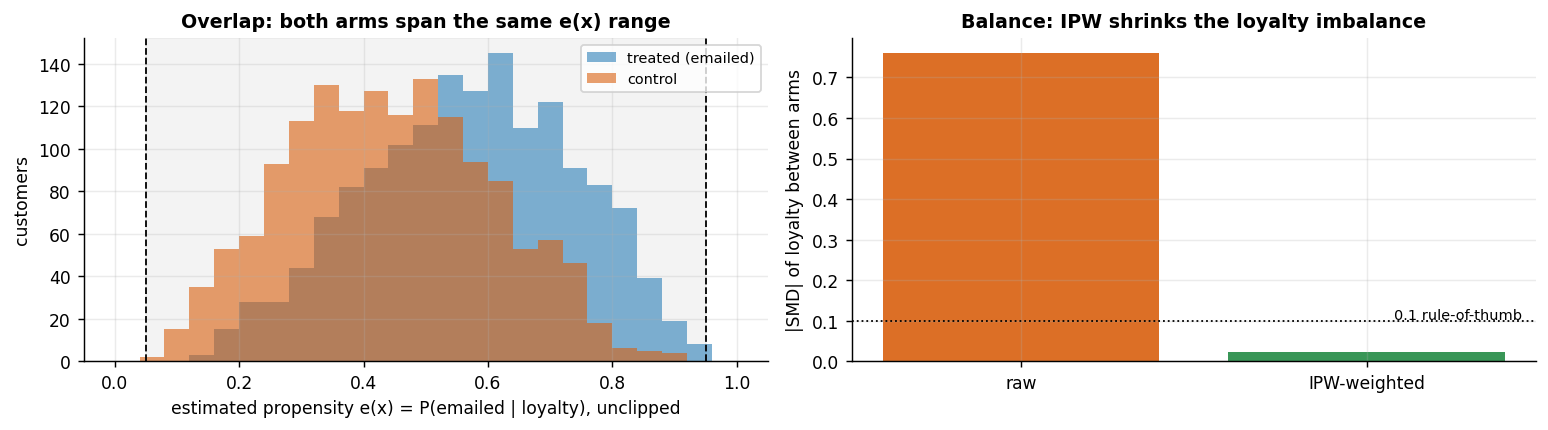

In [10]:
# --- Overlap & balance: is the positivity assumption plausible, and does IPW help? ---
# Positivity/overlap = every kind of customer had a real chance of BOTH arms. If some region of
# feature space is (near-)always treated, 1/e or 1/(1-e) explodes and the IPW rung is untrustworthy.
#
# One discipline point, and it is the whole reason this cell exists: the DIAGNOSTIC reads the RAW
# propensity. Clipping first and then reporting the range would report the clip — the test could not
# fail at the very boundary it is being checked against. The clip belongs inside the WEIGHTS only.
clip_lo, clip_hi = 0.05, 0.95
e_raw = est.propensity_scores(X, T)                          # the honest diagnostic input
e = np.clip(e_raw, clip_lo, clip_hi)                         # the same e(x) the IPW rung above uses
loyalty = X[:, 0]
w = T / e + (1 - T) / (1 - e)                                # IPW weights (finite thanks to the clip)

def _smd(x, t, wt=None):
    t1, t0 = (t == 1), (t == 0)
    s1, s0 = x[t1].std(ddof=1), x[t0].std(ddof=1)            # unweighted pooled SD in the denominator
    pooled = np.sqrt((s1 ** 2 + s0 ** 2) / 2.0)
    if wt is None:
        m1, m0 = x[t1].mean(), x[t0].mean()
    else:
        m1 = np.average(x[t1], weights=wt[t1]); m0 = np.average(x[t0], weights=wt[t0])
    return (m1 - m0) / pooled if pooled > 0 else 0.0          # guard divide-by-zero

smd_raw, smd_ipw = _smd(loyalty, T), _smd(loyalty, T, w)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
bins = np.linspace(0, 1, 26)
ax[0].hist(e_raw[T == 1], bins=bins, alpha=0.6, color=plots.BLUE, label="treated (emailed)")
ax[0].hist(e_raw[T == 0], bins=bins, alpha=0.6, color=plots.ORANGE, label="control")
ax[0].axvspan(clip_lo, clip_hi, color="0.85", alpha=0.30, zorder=0)   # the [clip_lo, clip_hi] keep-region
for b in (clip_lo, clip_hi):
    ax[0].axvline(b, color="k", ls="--", lw=1)
ax[0].set_xlabel("estimated propensity e(x) = P(emailed | loyalty), unclipped"); ax[0].set_ylabel("customers")
ax[0].set_title("Overlap: both arms span the same e(x) range"); ax[0].legend(fontsize=8)

ax[1].bar(["raw", "IPW-weighted"], [abs(smd_raw), abs(smd_ipw)],
          color=[plots.ORANGE, plots.GREEN], alpha=0.9)
ax[1].axhline(0.1, color="k", ls=":", lw=1); ax[1].text(1.45, 0.105, "0.1 rule-of-thumb", ha="right", fontsize=8)
ax[1].set_ylabel("|SMD| of loyalty between arms")
ax[1].set_title("Balance: IPW shrinks the loyalty imbalance")
fig.tight_layout()

outside = (e_raw <= clip_lo) | (e_raw >= clip_hi)
clip_n, frac_clip = int(outside.sum()), float(outside.mean())
e_trt_lo, e_trt_hi = float(e_raw[T == 1].min()), float(e_raw[T == 1].max())
e_ctl_lo, e_ctl_hi = float(e_raw[T == 0].min()), float(e_raw[T == 0].max())
print(f"overlap (raw e(x), no clip): emailed arm spans [{e_trt_lo:.2f}, {e_trt_hi:.2f}], control arm "
      f"[{e_ctl_lo:.2f}, {e_ctl_hi:.2f}] — the two arms live in the same region, which is what positivity asks.")
print(f"the [{clip_lo}, {clip_hi}] clip would bind on {clip_n} of {len(e_raw):,} customers ({frac_clip:.2%}) — a count, "
      f"not a rounded zero.")
print(f"balance: IPW shrinks the loyalty imbalance from SMD {abs(smd_raw):.2f} to {abs(smd_ipw):.2f} (bar: 0.1).")

### What adjustment cannot fix — the unmeasured backdoor

Everything so far is a success story, and that is a dangerous thing to teach: the ladder recovered €6
because the *one* confounder was **in the data**. Unconfoundedness (§3, assumption 1) is untestable, so
the foundations question is *what happens when it fails*. We rerun the whole ladder on notebook 01's
customer simulator with a **hidden** trait $U$ — think "a salesperson's hunch" or an unlogged loyalty
signal — wired into both assignment and outcome (the same two knobs notebook 01's Depth B sweeps):

$$
\begin{aligned}
T &\sim \text{Bernoulli}\Big(\sigma\big(\text{observed-feature logit} + a_T\,U\big)\Big),\\[2pt]
Y &= \mu_0(x)+\tau(x)\,T+b_Y\,U+\varepsilon,\qquad U\sim\mathcal N(0,1)\ \text{unobserved},
\end{aligned}
$$

with $a_T=2.0$ ($U$ shifts the emailing logit) and $b_Y=3.0$ ($U$ adds €3 of spend per SD). Every rung is
fit on the five *observed* features only — exactly the information a real analyst would have:

**Predict before you run.** Every rung below sees the five observed features only, while the open backdoor
runs through $U$. Which rungs will still land near the truth — and does AIPW's double robustness buy any
protection here? Commit to an answer, then check it against the printed table.

[cache] MISS '00_hidden_confounder_ladder' — fitting (this is the slow path)...


[cache] stored '00_hidden_confounder_ladder' after 7s -> 00_hidden_confounder_ladder-1f2375cb7a19-5066d5c94f85.pkl
  naive        mean €12.87   range [12.22, 13.99]   (true €5.79)
  regression   mean € 9.55   range [9.23, 9.96]   (true €5.79)
  IPW          mean € 9.59   range [9.09, 9.99]   (true €5.79)
  AIPW         mean € 9.44   range [8.78, 9.74]   (true €5.79)

Every adjusted rung sits at least €3.6 above the truth: regression, weighting and double
robustness fail TOGETHER, because all three adjust for the same measured features while the open
backdoor runs through U, which none of them can see. No estimator upgrade fixes missing data.

Positivity failure, seen (10 seeds, true €6, confounder fully observed): under gentle selection the clip
binds on 0.03% of customers and IPW averages €6.12 (sd 0.26); under near-deterministic
selection the clip binds on 44% of customers and IPW drifts to €7.51 (sd 0.42) — when some
customers essentially can't appear in both arms, no reweighting re

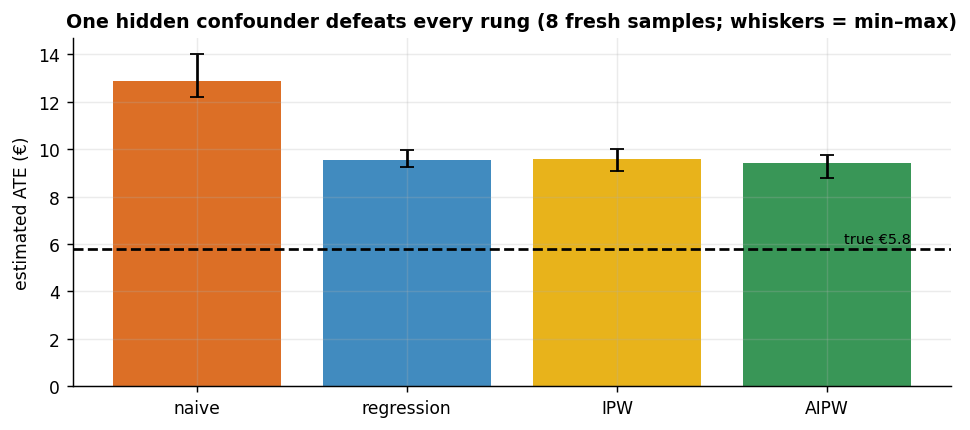

In [11]:
# The four rungs on hidden-confounder data, adjusting for the OBSERVED features only.
featU = ["recency", "frequency", "monetary", "tenure", "engage"]

def ladder_pts_multi(Xv, Tv, Yv):        # naive / regression / IPW — multi-feature twin of ladder_pts
    naive = Yv[Tv == 1].mean() - Yv[Tv == 0].mean()
    D = np.column_stack([np.ones(len(Yv)), Tv, Xv]); reg = np.linalg.lstsq(D, Yv, rcond=None)[0][1]
    e = np.clip(est.propensity_scores(Xv, Tv), 0.05, 0.95)
    ipw = (Tv * Yv / e).mean() - ((1 - Tv) * Yv / (1 - e)).mean()
    return naive, reg, ipw

NSU = 3 if FAST else 8
labelsU = ["naive", "regression", "IPW", "AIPW"]
def _hidden_ladder():
    drawsU_ = {k: [] for k in labelsU}; truthsU_ = []
    for s in range(NSU):
        du = dgp.uplift_customers(n=3000, regime="observational", conf_t=2.0, conf_y=3.0, seed=300 + s)
        Xu, Tu, Yu = du[featU].values, du["T"].values, du["y"].values
        nv, rg, iw = ladder_pts_multi(Xu, Tu, Yu)
        ap = est.aipw_ate(Xu, Tu, Yu, seed=1, n_boot=50 if FAST else 200)
        for k, v in zip(labelsU, [nv, rg, iw, ap["ate"]]): drawsU_[k].append(v)
        truthsU_.append(du["tau"].mean())
    return drawsU_, truthsU_

drawsU, truthsU = load_or_run("00_hidden_confounder_ladder", _hidden_ladder,
                              inputs=dict(n_seeds=NSU, n_boot=50 if FAST else 200, aipw_seed=1,
                                          n=3000, conf_t=2.0, conf_y=3.0, fast=FAST))
trueU = float(np.mean(truthsU))
meansU = [float(np.mean(drawsU[k])) for k in labelsU]
err_lo = [m - float(np.min(drawsU[k])) for k, m in zip(labelsU, meansU)]
err_hi = [float(np.max(drawsU[k])) - m for k, m in zip(labelsU, meansU)]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(labelsU, meansU, color=[plots.ORANGE, plots.BLUE, plots.GOLD, plots.GREEN], alpha=0.9,
       yerr=[err_lo, err_hi], capsize=4, ecolor="k")
ax.axhline(trueU, color="k", ls="--"); ax.text(3.4, trueU + 0.25, f"true €{trueU:.1f}", ha="right", fontsize=8)
ax.set_ylabel("estimated ATE (€)")
ax.set_title(f"One hidden confounder defeats every rung ({NSU} fresh samples; whiskers = min–max)")
fig.tight_layout()

for k, m in zip(labelsU, meansU):
    print(f"  {k:12s} mean €{m:5.2f}   range [{np.min(drawsU[k]):.2f}, {np.max(drawsU[k]):.2f}]   (true €{trueU:.2f})")
adj_bias = min(np.mean(drawsU[k]) for k in ["regression", "IPW", "AIPW"]) - trueU
print(f"\nEvery adjusted rung sits at least €{adj_bias:.1f} above the truth: regression, weighting and double")
print("robustness fail TOGETHER, because all three adjust for the same measured features while the open")
print("backdoor runs through U, which none of them can see. No estimator upgrade fixes missing data.")

# --- and the OTHER assumption: when positivity fails, IPW degrades even with the confounder observed ---
# Both arms of the contrast get the SAME measurement — "the clip never binds" is a number, not an adjective.
ipw_ok, ipw_bad, clip_ok, clip_bad = [], [], [], []
for s in range(10):
    rs = np.random.default_rng(1000 + s)
    Lb = rs.normal(0, 1, 3000); epsb = rs.normal(0, 4, 3000)
    for a_sel, store, clips in [(0.8, ipw_ok, clip_ok), (4.0, ipw_bad, clip_bad)]:   # gentle vs near-deterministic selection on L
        Tb = (rs.uniform(size=3000) < 1 / (1 + np.exp(-a_sel * Lb))).astype(float)
        Yb = 20 + 5 * Lb + 6 * Tb + epsb
        eb = est.propensity_scores(Lb[:, None], Tb)
        clips.append(float(np.mean((eb <= 0.05) | (eb >= 0.95))))    # measured on the RAW score, for BOTH arms
        eb = np.clip(eb, 0.05, 0.95)
        store.append((Tb * Yb / eb).mean() - ((1 - Tb) * Yb / (1 - eb)).mean())
print(f"\nPositivity failure, seen (10 seeds, true €6, confounder fully observed): under gentle selection the clip")
print(f"binds on {np.mean(clip_ok):.2%} of customers and IPW averages €{np.mean(ipw_ok):.2f} (sd {np.std(ipw_ok):.2f}); under near-deterministic")
print(f"selection the clip binds on {np.mean(clip_bad):.0%} of customers and IPW drifts to €{np.mean(ipw_bad):.2f} (sd {np.std(ipw_bad):.2f}) — when some")
print("customers essentially can't appear in both arms, no reweighting recovers a full-population ATE. §6's overlap")
print("histogram above is the diagnostic that catches this before you trust the number.")

**The boundary of estimation, drawn.** Adjustment closes the backdoors you *measured*. A backdoor you
didn't measure defeats every rung equally — and double robustness offers no protection, because it
insures against a mis-specified *model of the observed features*, never against a missing feature. When
positivity fails, the problem is worse still: the data simply contain no like-with-like comparisons to
reweight. The honest responses are better data, better *design* (randomize — §3), or **sensitivity
analysis**: asking how strong a hidden $U$ would have to be to change the decision, which notebook 01's
Depth B prices as a tipping point and an E-value. That boundary is why the discipline box below is the
most important sentence in the cookbook:

### 6b · Every diagnostic passes — and the answer is still wrong. In euros.

"The failure is silent" is the strongest claim in this notebook, and so far it is only a claim: §6 ran its
overlap and balance diagnostics on the *observed*-confounder data, where they were supposed to pass. Run
them where it matters — on one hidden-$U$ panel, the data on which every adjusted rung is €3–4 out — and
see whether anything in the diagnostic sheet flinches.

Then price it. The hidden-$U$ panels come from the same simulator and the same €8-per-contact world as §3
and §9, so the miss is not an abstraction: it is a go/no-go.

In [12]:
# The SAME two diagnostics §6 ran, now on data whose backdoor is open — plus the AIPW standard error,
# and the euro consequence at the €8 contact cost.
duh = dgp.uplift_customers(n=3000, regime="observational", conf_t=2.0, conf_y=3.0, seed=300)
Xh, Th, Yh = duh[featU].values, duh["T"].values, duh["y"].values
true_h = float(duh["tau"].mean())

e_h = est.propensity_scores(Xh, Th)                                   # RAW score, as in §6's overlap panel
e_hc = np.clip(e_h, 0.05, 0.95)
w_h = Th / e_hc + (1 - Th) / (1 - e_hc)
out_h = int(((e_h <= 0.05) | (e_h >= 0.95)).sum())
smd_h_raw = max(abs(_smd(Xh[:, j], Th))       for j in range(Xh.shape[1]))   # worst of the five features
smd_h_ipw = max(abs(_smd(Xh[:, j], Th, w_h))  for j in range(Xh.shape[1]))
aipw_h = est.aipw_ate(Xh, Th, Yh, seed=1, n_boot=100 if FAST else 300)

print("Diagnostics on a hidden-U panel (seed 300, n=3,000) — the same sheet §6 signed off on:")
print(f"  overlap  : raw e(x) spans [{e_h.min():.2f}, {e_h.max():.2f}]; {out_h} customers outside [0.05, 0.95]. PASS")
print(f"  balance  : worst feature |SMD| {smd_h_raw:.2f} raw → {smd_h_ipw:.2f} IPW-weighted (bar 0.1). PASS")
print(f"  precision: AIPW €{aipw_h['ate']:.2f}, SE €{aipw_h['se']:.2f}, 90% CI "
      f"[€{aipw_h['ci90'][0]:.2f}, €{aipw_h['ci90'][1]:.2f}] — tight, and it converged. PASS")
print(f"\nEvery testable assumption passes. The planted truth is €{true_h:.2f}. AIPW is €{aipw_h['ate'] - true_h:+.2f} out,")
print("and NOTHING in the three lines above says so — because the one assumption that failed (unconfoundedness)")
print("is the one with no test. This is what a confidently wrong analysis looks like from the inside.")

# --- the same miss, denominated ---------------------------------------------------------------
gain_h = duh["tau"] - COST                                   # realised per-customer profit if contacted
hidden_burn = float(-gain_h.sum())
hidden_ship = bool(aipw_h["ate"] > COST)
hidden_verdict = "SHIP — email everyone" if hidden_ship else "do not send"
print(f"\nIn euros, at the €{COST:.0f} contact cost:")
print(f"  truth €{true_h:.2f} < €{COST:.0f}  → the correct call is 'email no one' (realises €0, loses €0).")
print(f"  AIPW  €{aipw_h['ate']:.2f} > €{COST:.0f}  → the ladder's call is {hidden_verdict}, which on this base realises "
      f"€{gain_h.sum():,.0f}: it BURNS €{hidden_burn:,.0f}.")
print("That is the identical euro error as §3's confounded dashboard — now wearing a doubly-robust badge and a")
print("clean diagnostic sheet. The badge is the danger: it is what makes the number credible in the meeting.")

Diagnostics on a hidden-U panel (seed 300, n=3,000) — the same sheet §6 signed off on:
  overlap  : raw e(x) spans [0.16, 0.86]; 0 customers outside [0.05, 0.95]. PASS
  balance  : worst feature |SMD| 0.46 raw → 0.01 IPW-weighted (bar 0.1). PASS
  precision: AIPW €9.25, SE €0.39, 90% CI [€8.64, €9.86] — tight, and it converged. PASS

Every testable assumption passes. The planted truth is €5.61. AIPW is €+3.64 out,
and NOTHING in the three lines above says so — because the one assumption that failed (unconfoundedness)
is the one with no test. This is what a confidently wrong analysis looks like from the inside.

In euros, at the €8 contact cost:
  truth €5.61 < €8  → the correct call is 'email no one' (realises €0, loses €0).
  AIPW  €9.25 > €8  → the ladder's call is SHIP — email everyone, which on this base realises €-7,169: it BURNS €7,169.
That is the identical euro error as §3's confounded dashboard — now wearing a doubly-robust badge and a
clean diagnostic sheet. The badge is the 

> The discipline: **Bayes/ML sharpens estimation, never identification.** A tight, beautiful posterior
> computed under a false unconfoundedness assumption is *confidently wrong*. Priors don't fix broken
> causal arguments — the graph does. Every notebook keeps identification (this ladder's assumptions)
> separate from estimation (which rung you climb).


## 7 · The Bayesian workflow, on one model — prior → likelihood → posterior → diagnostics

Everything above returned points *and* 90% **confidence intervals** — four of each. From notebook 01
onwards every estimate in this cookbook is instead a **posterior distribution**, and the upgrade is
therefore *not* point → interval (§6 already has intervals): it is **confidence interval → credible
interval**, two objects that print almost identically and mean entirely different things. §7.1 makes that
distinction exact; the vocabulary it needs lives here, on the smallest possible causal model: ladder **rung 2 made Bayesian**, on the same confounded data `d` ($n=3{,}000$,
true effect €6):

$$
y_i \sim \mathcal N\big(\alpha+\tau\,T_i+\beta\,L_i,\ \sigma^2\big),\qquad
\alpha\sim\mathcal N(20,\,10^2),\quad
\tau\sim\mathcal N(0,\,10^2),\quad
\beta\sim\mathcal N(0,\,10^2),\quad
\sigma\sim\text{HalfNormal}(10).
$$

Symbols: $y_i$ is customer $i$'s spend (€), $T_i$ the email indicator, $L_i$ loyalty; $\alpha$ is the
baseline spend of a loyalty-0 un-emailed customer, $\tau$ the email effect — **the estimand**, $\beta$
the spend slope per SD of loyalty (the term doing the causal adjustment), $\sigma$ the residual spend
noise. The first equation is the **likelihood** — exactly rung 2's linear outcome model. The rest are
**priors**, each defensible in one clause: all are *weakly informative on the € scale of the data*
($\alpha$ centred near typical spend of ~€20; $\beta$ and $\sigma$ wide enough for anything plausible),
and $\tau\sim\mathcal N(0,10^2)$ is *skeptical-but-open* — centred on "the email does nothing", yet wide
enough to learn a €30 effect if the data insist. The **posterior** $p(\tau\mid \text{data})$ is what
MCMC samples below. **MCMC** (Markov-chain Monte Carlo) is the workhorse algorithm that, when the
posterior has no closed form, draws a large sample of plausible $\tau$ values from it — each **draw** is
one such value, and we run several independent **chains** (fresh restarts) so we can check they agree.
The first `tune` draws are a warm-up the sampler discards while it calibrates itself; only the
post-warm-up `draws` are kept — exactly what the `BAYES` dict sets below (`draws=1000, tune=1000,
chains=4` in the FULL run these stored outputs come from; a cheaper `400/400/2` under `CMP_FAST=1`). That code
also prints a one-line sampler health check (R-hat, ESS, divergences); the box right after it defines
those three numbers.

**Credible vs confidence interval — say it right in the meeting.** A 90% **credible interval** answers:
*given the data and this model, there is a 90% probability the effect lies in this range* — the sentence
managers actually want to hear. The confidence intervals of §6 answer a different question: *the
procedure that built this interval captures the truth in 90% of repeated samples* — a statement about the
procedure, not about this dataset. Different logic; numerically they nearly coincide when priors are weak
and $n$ is large (as here), and they part ways when data are thin — which is exactly when priors earn
their keep (notebook 06's MMM). §7.1 below makes that distinction exact and demonstrates it on the two
fits this notebook has already run.

In [13]:
import logging
import pymc as pm
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)   # SamplerWarnings log at ERROR; silence fully

BAYES = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1000, tune=1000, chains=4)
L_obs = X[:, 0]                                            # loyalty, from §6's ladder cell

def fit_rung2(adjust=True, tau_prior_sd=10.0, **kw):
    "Bayesian rung 2 on (T, Y) from §6: linear outcome model, optionally dropping the confounder L."
    with pm.Model():
        alpha = pm.Normal("alpha", 20, 10)
        tau_rv = pm.Normal("tau", 0, tau_prior_sd)
        mu = alpha + tau_rv * T
        if adjust:
            mu = mu + pm.Normal("beta", 0, 10) * L_obs
        sigma = pm.HalfNormal("sigma", 10)
        pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y)
        return pm.sample(**{**BAYES, **kw}, cores=1, random_seed=1, progressbar=False)

idata_adj = load_or_run("00_bayes_adjusted", lambda: fit_rung2(adjust=True),
                        inputs=dict(seed=1, fast=FAST, model="adjusted", tau_prior_sd=10.0, **BAYES))
tau_post = idata_adj.posterior["tau"].values.ravel()
lo_b, hi_b = np.quantile(tau_post, [0.05, 0.95])
rep = est.convergence_report(idata_adj)
print(f"posterior for τ:  mean €{tau_post.mean():.2f}  ·  90% credible interval [€{lo_b:.2f}, €{hi_b:.2f}]   (true €{true_ate:.0f})")
print(f"AIPW (frequentist rung 4), same data:  €{aipw['ate']:.2f}  ·  90% bootstrap CI [€{aipw['ci90'][0]:.2f}, €{aipw['ci90'][1]:.2f}]")
if lo_b <= true_ate <= hi_b:
    print("\nThis sample's 90% credible interval covers the €6 truth — as it should, roughly 9 times in 10.")
else:
    print("\nThis sample's 90% credible interval narrowly misses €6 — the SAME ~1-in-10 sampling event §6's")
    print("AIPW interval showed on this seed: one dataset, one shared wobble; over fresh samples both centre on €6.")
if abs(tau_post.mean() - aipw["ate"]) < 0.5:
    print("Bayesian and frequentist land together here: with weak priors and n=3,000 the likelihood dominates.")
clean_geo = rep["min_ess_bulk"] > 200 and not (rep["n_divergences"] or 0)
if rep["max_rhat"] < 1.01 and clean_geo:
    verdict = "  → chains agree, draws are plentiful, geometry is clean."
elif rep["max_rhat"] < 1.03 and clean_geo and FAST:
    verdict = ("  → R-hat grazes the 1.01 bar — an artifact of FAST's short chains, not of this easy model;"
               "\n  re-run with CMP_FAST=0 for interval-grade draws. The habit is the point: read this line FIRST.")
else:
    verdict = "  → a diagnostic is off; add draws (or fix the model) before reading the numbers."
print(f"convergence: {rep['summary']}{verdict}")

[cache] MISS '00_bayes_adjusted' — fitting (this is the slow path)...


[cache] stored '00_bayes_adjusted' after 3s -> 00_bayes_adjusted-a78c4a09e59e-75d2db4298e1.pkl
posterior for τ:  mean €5.60  ·  90% credible interval [€5.28, €5.93]   (true €6)
AIPW (frequentist rung 4), same data:  €5.57  ·  90% bootstrap CI [€5.27, €5.86]

This sample's 90% credible interval narrowly misses €6 — the SAME ~1-in-10 sampling event §6's
AIPW interval showed on this seed: one dataset, one shared wobble; over fresh samples both centre on €6.
Bayesian and frequentist land together here: with weak priors and n=3,000 the likelihood dominates.
convergence: max r-hat 1.000 - min ESS 2513 - divergences 0  → chains agree, draws are plentiful, geometry is clean.


> **Did the sampler converge? — the three numbers to read before trusting any posterior.** An MCMC
> posterior is only as good as the sampling that produced it, so every Bayesian fit in this cookbook
> prints the same one-line report (`est.convergence_report`). The vocabulary, in plain terms:
>
> - **R-hat** — run several independent chains and compare where they think the posterior is. Agreement
>   gives R-hat ≈ 1.00; above ~1.01, keep sampling or fix the model.
> - **ESS** (*effective sample size*) — consecutive draws are autocorrelated, so 800 draws may carry the
>   information of far fewer independent ones; ESS is that independent-equivalent count. You want it
>   comfortably in the hundreds for stable interval endpoints.
> - **Divergences** — NUTS (the No-U-Turn sampler, the default MCMC engine here) raising an alarm that
>   it hit posterior geometry it couldn't integrate; more than a
>   handful means the posterior is suspect (raise `target_accept`, or reparameterize).
>
> A four-parameter linear model is easy geometry, so this one passes without drama — the point is the
> **habit**. (Notebook 01's BART models are sampled by particle Gibbs, where divergences don't apply but
> R-hat/ESS still do; notebook 06's MMM is hard enough geometry that FULL runs need
> `target_accept = 0.99`.)
>
> One check is deliberately deferred: the **posterior predictive check** — simulating data from the fitted
> model to ask whether the *model* fits the data, a different question from whether the *sampler* is
> healthy — earns its keep where the likelihood itself is in doubt, so notebooks 03 (price elasticity) and
> 04 (mediation) run it there; a four-parameter linear model on data we simulated is not that place.

**Predict before you run.** The next cell refits the same model with the loyalty term deleted. Two calls to
make in advance: where will that posterior centre — near the €6 truth, or near §6's naive rung? — and will
its interval be wide enough to warn you that something is wrong? Check both against the printed jump and
the two posterior sds.

[cache] MISS '00_bayes_unadjusted' — fitting (this is the slow path)...


[cache] stored '00_bayes_unadjusted' after 2s -> 00_bayes_unadjusted-c6b0d61af711-8f71232ba159.pkl
[cache] MISS '00_bayes_prior_sweep' — fitting (this is the slow path)...


[cache] stored '00_bayes_prior_sweep' after 3s -> 00_bayes_prior_sweep-c1b564a1a4c2-d60d9528e9cc.pkl
same data, same priors, one dropped covariate: the τ posterior jumps €+3.66, to €9.26 ± 0.25 —
NEARLY as tight as the correct model's (± 0.20) — only 28% wider — and centred on the
naive rung's answer, not on €6: being confidently WRONG is not punished with a wide interval.
prior sweep: the posterior mean moves ≤ €0.05 as the τ prior sd goes 2 → 50 — with 3,000 customers the
likelihood dominates. Priors matter when data are thin: notebook 06's MMM fits saturation curves to 156
weeks, and there the priors carry real weight.


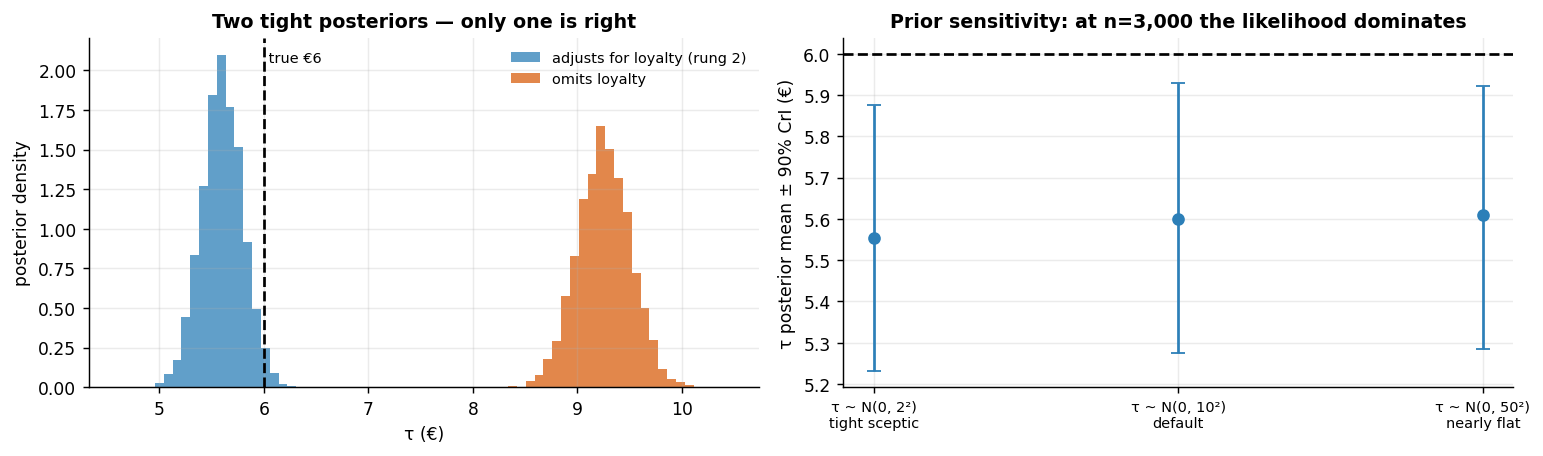

In [14]:
# The twist that makes the discipline box concrete: the SAME model, minus the confounder.
idata_noadj = load_or_run("00_bayes_unadjusted", lambda: fit_rung2(adjust=False),
                          inputs=dict(seed=1, fast=FAST, model="unadjusted", tau_prior_sd=10.0, **BAYES))
tau_noadj = idata_noadj.posterior["tau"].values.ravel()

# Prior sensitivity: the adjusted model under a 5x tighter and a 5x looser tau prior.
kw_s = dict(draws=300, tune=300) if FAST else {}
sens = load_or_run(
    "00_bayes_prior_sweep",
    lambda: {sd_p: fit_rung2(adjust=True, tau_prior_sd=sd_p, **kw_s).posterior["tau"].values.ravel()
             for sd_p in (2.0, 50.0)},
    inputs=dict(seed=1, fast=FAST, model="adjusted", tau_prior_sds=(2.0, 50.0), **{**BAYES, **kw_s}))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
lo_all = float(min(tau_post.min(), tau_noadj.min())) - 0.3
hi_all = float(max(tau_post.max(), tau_noadj.max())) + 0.3
bins_t = np.linspace(lo_all, hi_all, 70)
ax[0].hist(tau_post, bins=bins_t, color=plots.BLUE, alpha=0.75, density=True, label="adjusts for loyalty (rung 2)")
ax[0].hist(tau_noadj, bins=bins_t, color=plots.ORANGE, alpha=0.75, density=True, label="omits loyalty")
ax[0].axvline(true_ate, color="k", ls="--"); ax[0].text(true_ate, ax[0].get_ylim()[1] * 0.93, " true €6", fontsize=8)
ax[0].set_xlabel("τ (€)"); ax[0].set_ylabel("posterior density")
ax[0].set_title("Two tight posteriors — only one is right"); ax[0].legend(fontsize=8, frameon=False)

posts = [sens[2.0], tau_post, sens[50.0]]
p_means = [p.mean() for p in posts]
p_lo = [np.quantile(p, 0.05) for p in posts]; p_hi = [np.quantile(p, 0.95) for p in posts]
ax[1].errorbar(range(3), p_means, yerr=[np.subtract(p_means, p_lo), np.subtract(p_hi, p_means)],
               fmt="o", color=plots.BLUE, capsize=4)
ax[1].axhline(true_ate, color="k", ls="--")
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(["τ ~ N(0, 2²)\ntight sceptic", "τ ~ N(0, 10²)\ndefault", "τ ~ N(0, 50²)\nnearly flat"], fontsize=8)
ax[1].set_ylabel("τ posterior mean ± 90% CrI (€)")
ax[1].set_title("Prior sensitivity: at n=3,000 the likelihood dominates")
fig.tight_layout()

gap_b = tau_noadj.mean() - tau_post.mean()
shift = max(abs(sens[2.0].mean() - tau_post.mean()), abs(sens[50.0].mean() - tau_post.mean()))
print(f"same data, same priors, one dropped covariate: the τ posterior jumps €{gap_b:+.2f}, to €{tau_noadj.mean():.2f} ± {tau_noadj.std():.2f} —")
print(f"NEARLY as tight as the correct model's (± {tau_post.std():.2f}) — only {tau_noadj.std() / tau_post.std() - 1:.0%} wider — and centred on the")
print("naive rung's answer, not on €6: being confidently WRONG is not punished with a wide interval.")
print(f"prior sweep: the posterior mean moves ≤ €{shift:.2f} as the τ prior sd goes 2 → 50 — with 3,000 customers the")
print("likelihood dominates. Priors matter when data are thin: notebook 06's MMM fits saturation curves to 156")
print("weeks, and there the priors carry real weight.")

**Both posteriors are beautiful. Only one is right.** The no-loyalty model is not a worse *Bayesian*
model — its chains converge, its R-hat is ≈1.00, and its interval is *nearly* as tight as the correct
model's — the cell above prints both posterior sds; the wrong model's is only about a quarter wider, a gap
no one would read as a warning. It is a worse **causal**
model: dropping $L$ re-opened the backdoor, and the posterior obediently concentrated around the
confounded answer. The prior didn't fail — the **graph** did, and no prior on $\tau$ can encode "you
forgot a confounder". This is what *confidently wrong* looks like (the discipline box above, now
demonstrated), and it is why every later notebook settles identification **before** admiring the
posterior: the DAG decides *which variables enter the model*; Bayes only quantifies uncertainty about
their coefficients. The prior-sensitivity panel adds the complementary calibration: with $n=3{,}000$ the
prior is nearly irrelevant — so when a stakeholder worries that "the priors drive the answer", the sweep
is the reply; and when data are thin (notebook 06), the same sweep is how you find out that they do.

### 7.1 · Point estimate vs posterior — the distinction the rest of this cookbook rests on

<a id="point-estimate-vs-posterior"></a>

§6 produced a number and an interval. §7 produced a distribution. On the page they look almost
identical — the same effect, roughly the same range — and that resemblance conceals the single idea
every later notebook leans on. So state it once, exactly, and re-use it.

**A confidence interval is a property of the procedure.** Treat the effect $\tau$ as a fixed, unknown
constant; the *data* are what is random. An interval estimator $[L(D),\,U(D)]$ has 90% coverage when

$$
\Pr_{\,D\sim P_\tau}\big(L(D)\le \tau \le U(D)\big) \;=\; 0.90 \qquad \text{for every possible } \tau .
$$

Read where the probability sits: on $D$, the dataset that could have come out otherwise — **not** on
$\tau$, which is not a random variable at all in this calculus. Once the data are in hand, the printed
interval either contains $\tau$ or it does not. There is no "90% chance" left in it, exactly as a coin
already flipped and covered by your hand is not "50% heads" — you are simply ignorant of a settled fact.
Ninety percent describes the **factory**, not this one interval off the line. And §6 audits that factory
in the only way it can be audited: rebuild the interval on fresh samples and count how often it catches
the planted €6 (the coverage line printed under the ladder).

**A credible interval is a probability statement about the effect.** Put a distribution on $\tau$ itself
— a prior — and let the likelihood update it into a posterior $p(\tau \mid D)$. A 90% credible interval
is any $[a,b]$ with

$$
\Pr\big(a \le \tau \le b \;\big|\; D,\ \text{model},\ \text{prior}\big) \;=\; 0.90 .
$$

Now the probability *is* over $\tau$, conditional on the data you actually have. This is the sentence
everyone believes they are saying when they read a confidence interval aloud in a meeting. It is a
legitimate sentence — but only after paying its price of admission: a model and a prior, both of which
must then be defended (§7's prior sweep, notebook 05's DAG).

**Why this is commercial, not philosophical.** Every decision in this cookbook has the shape

$$
\Pr\big(\text{lift} > \text{cost} \mid \text{data}\big) \;\ge\; 0.9 \quad\Longrightarrow\quad \text{ship it,}
$$

and that expression is **natively a posterior quantity**: it integrates a distribution over the parameter
above a threshold. A confidence interval has no distribution over the parameter to integrate — there is
nothing there to take the mass of. The classical arm *can* manufacture a look-alike: bootstrap the
estimator, then count what share of the re-estimates clear the cost. But the object it produces is the
sampling distribution of the **estimator** $\hat\tau$ — how the *estimate* would jump around across
resampled datasets — and not a distribution of belief over the **parameter** $\tau$. The two land on
nearly the same number in the friendly case (large $n$, weak priors, near-symmetric likelihood — the case
below, which is precisely why the confusion is so durable and so hard to kill). They separate exactly
where the money is: thin data, hierarchical shrinkage across segments, a prior doing real work, and any
nonlinear function of the parameters — ROAS, a saturation curve, the value of a targeting policy — where
uncertainty must be *propagated*, not just reported. Reading a bootstrap as a belief is borrowing the
Bayesian sentence without paying for the model. (If you *are* willing to pay — flat prior, regular
likelihood — the two coincide by a theorem, not by luck; but then you have simply become a Bayesian.)

The demo below is deliberately anticlimactic. Both arms have already been fitted, on the same 3,000
customers, targeting the same $\tau$: the classical OLS rung 2 of §6 and its Bayesian twin of §7 — the
*same* linear specification, with priors bolted on. We put them side by side, and then ask the one
question only one of them can answer.

**One knob, declared before the code runs.** The go/no-go threshold below is `CONTACT_COST = €5.25`, not
the €8 the rest of this notebook uses — and both halves of that deserve a sentence. It *may* move because
§6–§7 run on a different simulated base (`dag_control_demo`, planted effect €6) from §3's and §9's
`uplift_customers` (planted ATE ≈ €5.6, naive €11.4 against an €8 cost): no cost carries over between two
made-up businesses. But it moved *to €5.25 specifically* to put the threshold where the comparison bites: close enough to the
posterior that the mass above it is visibly short of 1 — the code below prints exactly how far below the
posterior mean the cost sits, measured in posterior standard deviations — yet far enough that the verdict at
the 0.9 bar is a comfortable SHIP rather than a marginal one. (A genuine knife-edge against that bar would
need the cost only about 1.3 posterior standard deviations below the mean — the point where the mass above
it hovers at 0.90 itself — and this cost sits further out than that.) Put the cost at €3 and every method
prints 1.00; put it at €8 and every method prints 0.00; and either way the reader never gets to ask why the
posterior's mass and the bootstrap's share are different animals. That placement is the lesson in miniature:
the go/no-go hangs entirely on where the cost line falls relative to the posterior, which is exactly why the
rule consumes a distribution and not a point. The threshold is chosen to make that visible. Better to admit
it than to dress it up as a real print-and-post cost.

Same estimand τ (true €6), same data (n=3,000):

                         arm  estimate €  lo €  hi €  width €       interval
classical · OLS rung 2 (HC1)        5.60  5.28  5.92     0.64 90% CONFIDENCE
classical · AIPW (bootstrap)        5.57  5.27  5.86     0.60 90% CONFIDENCE
  Bayesian · rung 2 + priors        5.60  5.28  5.93     0.65   90% CREDIBLE

rung 2, both ways: the point estimates differ by €0.002 (0.3% of the confidence interval's width), and the two intervals
agree to within a couple of cents. Bayes did NOT change the answer.



P(τ > €5.25 | data, model) = 0.96   ← posterior mass above the cost. A probability ABOUT THE EFFECT:
   the number the rule 'ship if P(lift > cost) >= 0.9' literally asks for. Verdict at the 0.9 bar: SHIP.
   The €5.25 threshold sits 1.78 posterior sds below the posterior mean of €5.60 —
   inside the posterior's left tail but well past the ~1.3-sd point where a 0.9 bar would be a knife-edge:
   this SHIP is comfortable. Move the cost toward the mean and watch the verdict get nervous.

Bootstrap look-alike: 0.96 of the 2,000 re-estimates of τ̂ sit above €5.25.
   That is NOT P(τ > cost). It describes how the ESTIMATOR would scatter across resampled datasets,
   not how plausible each value of τ is. It is numerically close here — weak priors, n=3,000, a
   symmetric likelihood — and that near-coincidence is exactly why the mistake survives in industry.

And no confidence interval can be read that way at all: §6's ladder can only tell you that intervals
   built that way covered the pla

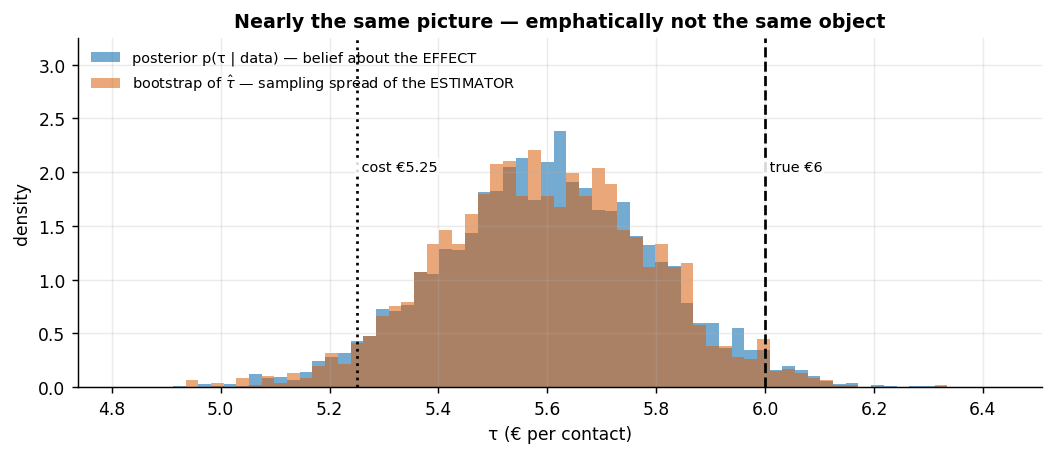

In [15]:
# The same estimand (τ, the email effect), the same 3,000 customers, two regimes of inference.
CONTACT_COST = 5.25          # € to print, post and process one contact — the go/no-go threshold

ols_rung2 = rungs[1]                                    # classical twin of the Bayesian model
b_lo, b_hi = np.quantile(tau_post, [0.05, 0.95])        # 90% credible interval, from the draws

side = pd.DataFrame([
    {"arm": "classical · OLS rung 2 (HC1)", "estimate €": ols_rung2.estimate,
     "lo €": ols_rung2.ci[0], "hi €": ols_rung2.ci[1],
     "width €": ols_rung2.ci[1] - ols_rung2.ci[0], "interval": "90% CONFIDENCE"},
    {"arm": "classical · AIPW (bootstrap)", "estimate €": aipw["ate"],
     "lo €": aipw["ci90"][0], "hi €": aipw["ci90"][1],
     "width €": aipw["ci90"][1] - aipw["ci90"][0], "interval": "90% CONFIDENCE"},
    {"arm": "Bayesian · rung 2 + priors", "estimate €": tau_post.mean(),
     "lo €": b_lo, "hi €": b_hi, "width €": b_hi - b_lo, "interval": "90% CREDIBLE"},
])
print(f"Same estimand τ (true €{true_ate:.0f}), same data (n={len(Y):,}):\n")
print(side.round(2).to_string(index=False))
gap = abs(tau_post.mean() - ols_rung2.estimate)
print(f"\nrung 2, both ways: the point estimates differ by €{gap:.3f} "
      f"({gap / (ols_rung2.ci[1] - ols_rung2.ci[0]):.1%} of the confidence interval's width), and the two "
      f"intervals\nagree to within a couple of cents. Bayes did NOT change the answer.")

# --- The one question only the posterior answers, and the classical look-alike -------------
p_pays = float((tau_post > CONTACT_COST).mean())        # posterior mass above the cost
cost_sds = float((tau_post.mean() - CONTACT_COST) / tau_post.std())   # how many posterior sds below the mean the cost sits

NBOOT = 400 if FAST else 2000                           # bootstrap the OLS estimator itself
rng_b = np.random.default_rng(7)
D_all = np.column_stack([np.ones(len(Y)), T, X[:, 0]])
boot_tau = np.array([np.linalg.lstsq(D_all[ii], Y[ii], rcond=None)[0][1]
                     for ii in (rng_b.integers(0, len(Y), (NBOOT, len(Y))))])
frac_above = float((boot_tau > CONTACT_COST).mean())

fig, ax = plt.subplots(figsize=(8.2, 3.6))
bins_c = np.linspace(min(tau_post.min(), boot_tau.min()) - 0.1,
                     max(tau_post.max(), boot_tau.max()) + 0.1, 70)
ax.hist(tau_post, bins=bins_c, density=True, color=plots.BLUE, alpha=0.65,
        label="posterior p(τ | data) — belief about the EFFECT")
ax.hist(boot_tau, bins=bins_c, density=True, color=plots.ORANGE, alpha=0.55,
        label=r"bootstrap of $\hat\tau$ — sampling spread of the ESTIMATOR")
top = ax.get_ylim()[1] * 1.30
ax.set_ylim(0, top)                                   # headroom so the labels clear the legend
box = dict(fc="white", ec="none", alpha=0.85, pad=1.0)
ax.axvline(CONTACT_COST, color="k", ls=":")
ax.text(CONTACT_COST, top * 0.62, f" cost €{CONTACT_COST:.2f}", fontsize=8, bbox=box)
ax.axvline(true_ate, color="k", ls="--")
ax.text(true_ate, top * 0.62, f" true €{true_ate:.0f}", fontsize=8, bbox=box)
ax.set_xlabel("τ (€ per contact)"); ax.set_ylabel("density")
ax.set_title("Nearly the same picture — emphatically not the same object")
ax.legend(fontsize=8, frameon=False, loc="upper left")
fig.tight_layout()

print(f"\nP(τ > €{CONTACT_COST:.2f} | data, model) = {p_pays:.2f}   ← posterior mass above the cost. A "
      f"probability ABOUT THE EFFECT:\n   the number the rule 'ship if P(lift > cost) >= 0.9' literally "
      f"asks for. Verdict at the 0.9 bar: "
      f"{'SHIP' if p_pays >= 0.9 else 'DO NOT SHIP (not yet convinced)'}.")
print(f"   The €{CONTACT_COST:.2f} threshold sits {cost_sds:.2f} posterior sds below the posterior mean of €{tau_post.mean():.2f} —")
print("   inside the posterior's left tail but well past the ~1.3-sd point where a 0.9 bar would be a knife-edge:")
print("   this SHIP is comfortable. Move the cost toward the mean and watch the verdict get nervous.")
print(f"\nBootstrap look-alike: {frac_above:.2f} of the {NBOOT:,} re-estimates of τ̂ sit above €{CONTACT_COST:.2f}.")
print("   That is NOT P(τ > cost). It describes how the ESTIMATOR would scatter across resampled datasets,")
print("   not how plausible each value of τ is. It is numerically close here — weak priors, n=3,000, a")
print("   symmetric likelihood — and that near-coincidence is exactly why the mistake survives in industry.")
print(f"\nAnd no confidence interval can be read that way at all: §6's ladder can only tell you that intervals")
print(f"   built that way covered the planted truth in {covered}/{NS} of the fresh samples it drew ({covered/NS:.0%}) —")
print("   a fact about the procedure. Ask it for P(lift > cost) and it has no distribution over τ to integrate.")


**What the demo shows, in three beats.**

1. **They agree.** The classical OLS rung 2 and its Bayesian twin land on the same effect, with intervals
   that overlap almost perfectly (printed above — a difference of a few cents on a €6 effect). This is the
   expected result, not a disappointment, and it is worth saying plainly to anyone who suspects Bayes of
   smuggling in the answer it wants: with $n=3{,}000$ and weakly-informative priors the likelihood
   dominates, and both arms are just reading the same data honestly.
2. **Only one of them answers the business question.** `P(τ > cost | data)` is a single line of arithmetic
   over the posterior draws — count the fraction above the threshold — and it is *the* input to the
   `P(lift > cost) ≥ 0.9` rule that every €-denominated decision in this cookbook uses. The classical arm
   has a point estimate and a coverage guarantee, and neither can be turned into that probability. The
   bootstrap number printed next to it is a different object wearing the same clothes: the scatter of the
   *estimator*, not the plausibility of the *effect*.
3. **What Bayes did *not* buy here.** Nothing in precision: the credible interval is no tighter than the
   HC1 confidence interval, and §7's prior sweep moved the posterior mean by cents as the prior went from
   sceptical to nearly flat. On easy data like this, the Bayesian layer buys **interpretability and a
   decision rule**, and that is all — say so. Where it buys more is where the data stop being easy:
   partial pooling across thin segments (notebook 02), priors carrying real weight on 156 weeks of MMM
   (06), uncertainty propagated through a saturation curve into ROAS (06) or through a policy into euros
   (01), and coherent sensitivity analysis over an assumption you cannot test (01's Depth B).

**How to read the rest of this cookbook.** Every method notebook (01–11) opens its estimation work with
**Step 0 · the classical read**: the same estimand, the same identification assumptions, the simplest
*correct* estimator — a 2×2 difference-in-differences, 2SLS, a local-linear regression discontinuity, an
SLSQP synthetic control — fitted with the standard errors that data structure demands (cluster on panels,
HAC on time series, HC1 on cross-sections), and *then* the Bayesian model. Two reasons, both on display
above. First, it lets you meet the **causal idea** — what identifies the effect — before meeting the
**Bayesian machinery**, instead of both at once; the causal content lives in the identification argument,
which is the same in either arm. Second, it keeps the comparison honest: when the two arms agree, the
Bayesian layer is not doing the work, and you should know that. Each notebook ends its Step 0 on the same
guardrail sentence printed under §6's ladder (`cmp.classical`'s `Classical.cannot_say()`), and closes the
loop with its own point-estimate-vs-posterior read-out.

When one of those read-outs feels slippery — and eventually one will — come back to **§7.1 · Point estimate
vs posterior**. It is the definition the whole cookbook cross-references.

## 8 · The same lesson on **real, famous data** (LaLonde 1986)

The ladder above ran on our simulator. Here is the identical confounding story on the most famous real
dataset in causal inference — **you don't provide anything; it's fetched from a public URL**:

> **LaLonde / NSW** — a 1970s job-training program. Because it included a **randomized** arm, we know the
> *true* effect of training on 1978 earnings: about **+\$1,800**. But if we throw away the randomized
> controls and instead compare the trained workers to a *non-experimental* comparison group (people
> pulled from national surveys), a naive difference is **negative** — it looks like training
> *hurt* earnings, because the trained group was far more disadvantaged to begin with (the confounding).
> Adjusting for the measured covariates pulls the estimate back toward the true +\$1,800. This single
> dataset is why the field takes confounding seriously.

Gated on `CMP_REAL=1` (keeps the offline test suite deterministic).


LaLonde (observational comparison group), effect of training on 1978 earnings:
  naive difference of means : $-635   (biased — trained group started far poorer)
  covariate-adjusted        : $1,548   (moves toward the ~$1,800 experimental truth)

overlap: 60% of the survey controls sit at e(x) < 0.10 vs 5% of trainees —
regression is extrapolating across thin support for most of the control pool, which is why the
adjusted estimate above still sits short of the ~$1,800 experimental truth.

trimmed to e(x) in (0.05, 0.95): 149 of 614 rows dropped, n = 465
  covariate-adjusted, trimmed : $1,390   (vs $1,548 untrimmed, ~$1,800 benchmark)
  worst covariate |SMD|       : 1.67 full sample → 1.34 trimmed (bar 0.1)

Read that honestly: the trim buys BALANCE — the comparison group now looks like the trainees —
and it does NOT buy the benchmark; the estimate moves sideways, not up. Trimming removes the
extrapolation, it does not manufacture the trainees' missing counterfactual. Dehejia-Wahba get


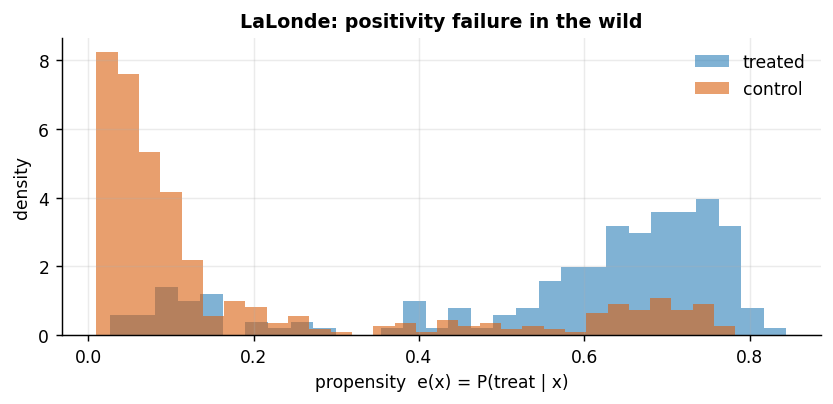

In [16]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    ll = data.load_lalonde()
    covs = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]
    T2, Y2 = ll["treat"].values, ll["re78"].values
    naive2 = Y2[T2==1].mean() - Y2[T2==0].mean()
    D2 = np.column_stack([np.ones(len(ll)), T2, ll[covs].values])
    adj2 = np.linalg.lstsq(D2, Y2, rcond=None)[0][1]
    print(f"LaLonde (observational comparison group), effect of training on 1978 earnings:")
    print(f"  naive difference of means : ${naive2:,.0f}   (biased — trained group started far poorer)")
    print(f"  covariate-adjusted        : ${adj2:,.0f}   (moves toward the ~$1,800 experimental truth)")

    # LaLonde's SECOND famous lesson: positivity failure in the wild. The non-experimental
    # comparison group is drawn from national surveys — masses of people who look nothing
    # like the trainees, i.e. e(x) ~ 0 for a huge share of controls.
    Xll = ll[covs].values.astype(float)
    Xs = (Xll - Xll.mean(0)) / Xll.std(0)                 # standardize for a stable logistic fit
    e_ll = est.propensity_scores(Xs, T2)
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    plots.overlap_plot(ax, e_ll, T2 == 1, title="LaLonde: positivity failure in the wild")
    fig.tight_layout()
    lo_ctrl = float((e_ll[T2 == 0] < 0.10).mean()); lo_trt = float((e_ll[T2 == 1] < 0.10).mean())
    print(f"\noverlap: {lo_ctrl:.0%} of the survey controls sit at e(x) < 0.10 vs {lo_trt:.0%} of trainees —")
    print("regression is extrapolating across thin support for most of the control pool, which is why the")
    print("adjusted estimate above still sits short of the ~$1,800 experimental truth.")

    # THE REPAIR THE LITERATURE POINTS AT, RUN. Dehejia-Wahba trim/match: throw away the controls
    # who could never have been trainees, then adjust on what is left. Does it close the shortfall
    # HERE, on this extract, with this plain propensity? Measure it — do not cite it.
    keep = (e_ll > 0.05) & (e_ll < 0.95)
    D3 = np.column_stack([np.ones(int(keep.sum())), T2[keep], Xll[keep]])
    adj_trim = float(np.linalg.lstsq(D3, Y2[keep], rcond=None)[0][1])
    n_trim, n_drop = int(keep.sum()), int((~keep).sum())
    smd_full = max(abs(_smd(Xs[:, j], T2)) for j in range(Xs.shape[1]))
    smd_trim = max(abs(_smd(Xs[keep][:, j], T2[keep])) for j in range(Xs.shape[1]))
    print(f"\ntrimmed to e(x) in (0.05, 0.95): {n_drop} of {len(ll)} rows dropped, n = {n_trim}")
    print(f"  covariate-adjusted, trimmed : ${adj_trim:,.0f}   (vs ${adj2:,.0f} untrimmed, ~$1,800 benchmark)")
    print(f"  worst covariate |SMD|       : {smd_full:.2f} full sample → {smd_trim:.2f} trimmed (bar 0.1)")
    print("\nRead that honestly: the trim buys BALANCE — the comparison group now looks like the trainees —")
    print("and it does NOT buy the benchmark; the estimate moves sideways, not up. Trimming removes the")
    print("extrapolation, it does not manufacture the trainees' missing counterfactual. Dehejia-Wahba get")
    print("there with a richer propensity specification and matching, not with this three-line trim, and the")
    print("gap between those two facts is the real lesson: a diagnostic tells you WHERE the estimate is")
    print("unsupported; it does not tell you what the supported estimate would have been.")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.")

**The payoff (what `CMP_REAL=1` prints).** Fetching the real LaLonde/NSW data (n = 614; 185 trained) and
running the *same two rungs* as our simulator gives the printout above: a naive difference of means that is
**negative** — training looks *harmful*, because the comparison group started far richer — and a
covariate-adjusted estimate that crosses back over zero to land within a few hundred dollars of the
≈ **+\$1,800** experimental truth.

Three more lessons the gated run adds. **(i) Positivity failure in the wild:** the propensity histogram the
gated cell draws shows roughly six in ten survey controls at $e(x)<0.1$ against almost none of the trainees
(the printed overlap line has the exact shares) — LaLonde is the canonical overlap-failure dataset, the
real-data twin of §6's overlap panel. **(ii) The honest residual:** covariate adjustment on that poor
overlap repairs the sign and the order of magnitude but still stops short of the ≈ **+\$1,800** benchmark.
**(iii) And the repair does not simply undo it.** The cell runs the trim the literature points at — keep
only the controls who could plausibly have been trainees — and reports what it actually buys: *balance*
(the worst covariate imbalance collapses toward the 0.1 bar) but *not* the benchmark (the estimate moves
sideways, not up). That is worth more than a citation would be. A trim deletes the region where the
regression was extrapolating; it does not reconstruct the counterfactual that was never in the data.
Dehejia–Wahba (1999) close the gap with a richer propensity specification and matching on their subsample —
a modelling choice, defended, not a mechanical fix — and the doubly-robust rung of §6 exists for the same
reason.

This is an even starker flip than the simulator's go/no-go — here the *sign* itself **reverses** once you adjust, driven by the same confounding, on the dataset that
made the field take confounding seriously. (The stored outputs above *are* the gated cell's, executed with
`CMP_REAL=1`. Without that variable the cell prints only its skip message and fetches nothing, which is
what keeps the offline test suite deterministic.)

## 9 · Price the identification error — the same mistake, in euros

Statistical bias becomes a business problem the moment someone acts on it. §3's confounded read-out
(naive ≈ €11 per contact vs €8 cost) says *email everyone*; the true ATE (≈ €5.6) says *a blanket send
loses money at this cost*. The simulator knows every customer's true $\tau_i$, so we can price what each
recommendation would actually have earned on this 3,000-customer base — plus the per-customer **oracle**
(email exactly those with $\tau_i > €8$), which no ATE-level rule can reach:

In [17]:
# §6's ladder ran on dag_control_demo. The euros are priced on THIS base (§3's observational panel),
# so the ladder has to be run here too — otherwise "adjustment repairs the number" is a promise, and
# the "right" policy below would be one only the simulator could have chosen. It is a fair fight: this
# panel has no hidden U (selection runs on engage/recency/frequency, all five features observed).
Xo, To, Yo = obs[featU].values, obs["T"].values, obs["y"].values
aipw_obs = est.aipw_ate(Xo, To, Yo, seed=1, n_boot=200 if FAST else 500)
pol_adj, (pol_adj_lo, pol_adj_hi) = float(aipw_obs["ate"]), aipw_obs["ci90"]

gain = obs["tau"] - COST                                     # realised per-customer profit if contacted
policies = pd.DataFrame([
    {"policy": "email everyone",         "decided by": f"naive €{naive_obs:.1f} > €{COST:.0f} (confounded)",
     "realised €": gain.sum()},
    {"policy": "email no one",           "decided by": f"AIPW €{pol_adj:.1f} < €{COST:.0f} (an ESTIMATE, on the observed features)",
     "realised €": 0.0},
    {"policy": "email no one",           "decided by": f"true ATE €{ate:.1f} < €{COST:.0f} (the oracle's average)",
     "realised €": 0.0},
    {"policy": "oracle: email τ > cost", "decided by": "per-customer truth (nb 01's target)",
     "realised €": gain.clip(lower=0).sum()},
])
policies["realised €"] = policies["realised €"].round(0).astype(int)
print(policies.to_string(index=False))
print(f"\nThe second row is the one an analyst can actually reach: the doubly-robust rung, fitted on the five")
print(f"observed features of THIS base, returns €{pol_adj:.2f} [90% CI €{pol_adj_lo:.2f}, €{pol_adj_hi:.2f}] — below the €{COST:.0f} cost, and it")
print(f"lands there without ever seeing a τ. Adjustment does not merely 'move the number': it flips the DECISION")
print(f"back, and the €{-gain.sum():,.0f} the confounded read-out would have burned is what that flip is worth.")
print(f"\nBreak-even: the blanket send only pays if a contact costs less than the true ATE, €{ate:.2f}. At €{COST:.0f} it does not.")
print(f"And the oracle row shows €{gain.clip(lower=0).sum():,.0f} sitting in per-customer targeting that NO average-level")
print("decision — however well identified — can touch: that gap is notebook 01's entire subject.")

                policy                                             decided by  realised €
        email everyone                           naive €9.7 > €8 (confounded)       -7255
          email no one AIPW €5.3 < €8 (an ESTIMATE, on the observed features)           0
          email no one              true ATE €5.6 < €8 (the oracle's average)           0
oracle: email τ > cost                    per-customer truth (nb 01's target)        9481

The second row is the one an analyst can actually reach: the doubly-robust rung, fitted on the five
observed features of THIS base, returns €5.34 [90% CI €4.68, €5.95] — below the €8 cost, and it
lands there without ever seeing a τ. Adjustment does not merely 'move the number': it flips the DECISION
back, and the €7,255 the confounded read-out would have burned is what that flip is worth.

Break-even: the blanket send only pays if a contact costs less than the true ATE, €5.58. At €8 it does not.
And the oracle row shows €9,481 sitting in per-c

> **The decision memo (what you tell the CMO).** The dashboard says the email pays for itself; it
> doesn't. Most of the gap is *who we emailed*, not what the email did — our historical targeting picked
> loyal, engaged customers who would have spent more anyway (**selection bias**), and on whom the email
> also works better than average (**ATT above ATE**); §3's decomposition splits the gap exactly, and the
> table above prices acting on it at roughly €7,000 burned per 3,000 contacts. The doubly-robust rung,
> fitted on the features we actually hold, gets to the right call on its own — it puts the effect below
> the €8 contact cost, which is the recommendation, and it needed no oracle to do it. That is the row to
> show: adjustment is not a statistical nicety, it is the difference between a send and a hold. What to do,
> in order: **randomize** when you can — a holdout kills selection bias by design (§3's green bar); when you
> can't, **adjust** for the confounders you measured (§6's ladder) and **stress** the ones you didn't
> (§6b's hidden-$U$ demo, which prices what a missed confounder costs at this same €8; notebook 01's Depth B
> turns that stress into a tipping point and an E-value). And note where the real money sits: not in the
> average at all, but in per-customer targeting (the oracle row) — which is exactly notebook 01's opening
> question.

## 10 · The cookbook map — every notebook, its estimand, and the assumption that carries it

Skim this once now and again whenever you open a new notebook — it is the intro's promise ("every later
notebook reads as a *named tool*") in one table, and a decent revision slide. Every one of them opens its
estimation work with **Step 0 · the classical read** — the same estimand and assumptions, the simplest
correct estimator, a point estimate and a confidence interval — before it fits anything Bayesian; the
reason is [§7.1 · Point estimate vs posterior](#point-estimate-vs-posterior), the passage those notebooks
cross-reference by name. Every "breaks when…" entry
is that notebook's falsification section: the foundations habit — name the assumption, then attack it —
scaled up.

| notebook | method | estimand | key identification assumption | breaks when… |
|---|---|---|---|---|
| **01** uplift targeting ⭐ | BCF / meta-learners | CATE | unconfoundedness + overlap | a hidden driver steered past sends (Depth B prices it) |
| **02** segment effects | interaction model + empirical-Bayes shrinkage | segment CATEs | as 01, within segments | the segment label proxies for the confounder itself |
| **03** price elasticity | hierarchical log-log | elasticity (continuous $T$) | price moves ⊥ demand shocks, given controls | simultaneity — managers cut price when demand is soft |
| **04** funnel mediation | SCM / natural effects | direct + indirect effects | sequential ignorability | an unmeasured mediator–outcome confounder |
| **05** what to control for | DAGs + adjustment sets | (whichever you target) | your DAG is right | you conditioned on a mediator/collider — or can't see one |
| **06** incrementality MMM | Bayesian MMM | channel contributions / ROAS (return on ad spend) | seasonality & spend confounding modelled | collinear channels, thin data (priors carry real weight) |
| **07 / 07b** geo lift | synthetic control | ATT (treated geo) | donors reconstruct the counterfactual (pre-fit transfers) | interference, shocked donors, short pre-periods |
| **08** loyalty rollout | DiD | ATT | parallel trends | treated stores were trending differently anyway |
| **09** threshold perk | RDD | local ATE at the cutoff | continuity — no sorting at the threshold | customers game the threshold (McCrary check) |
| **10** site redesign | ITS | post-period effect on the treated series | the pre-trend model extrapolates cleanly | anything else launched the same week |
| **11 / 11b** ad exposure | IV | **LATE** (compliers) | exclusion + a strong first stage | weak instrument, or one that touches the outcome directly |

### Exercises

No answer key — each of these checks itself against something this notebook already computes.

1. **Move the threshold.** §7.1's decision ran at `CONTACT_COST = 5.25`. Before touching the code, use the
   printed posterior mean, posterior sd and a normal table to predict `P(τ > cost)` at €5.60 and at €5.00;
   then change the constant and re-run the cell. Check: your two guesses against the recomputed posterior
   mass, and whether the SHIP verdict flips at either cost.
2. **Break positivity harder.** §6's positivity-failure demo uses a selection strength of 4.0 for its
   near-deterministic arm. Predict what happens to the clipped share and to the IPW estimate at 8.0, then
   edit and re-run. Check: against the gentle-selection row, which should barely move.
3. **Derive an OVB sign.** §6's hidden-$U$ demo wires $U$ into assignment and outcome with the same sign,
   so every adjusted rung lands *above* the truth. Flip `conf_y` to −3.0 — and add it to the
   `load_or_run` inputs dict, or the cache will hand back the old fit — then derive from the graph which way
   the ladder must now miss before re-running. Check: the printed table — the bias should change sign, not
   vanish.
4. **Refine the strata.** §3's g-formula demo cut loyalty into five quintiles. Re-run it with 10 strata and
   with 2, predicting each time whether the stratified average moves toward or away from the planted €6 and
   why. Check: the printed stratified line against the pooled one.
5. **Explain ATT ≠ ATE to a CMO.** In three sentences and no notation, explain why the effect on the
   customers we emailed differs from the effect on a random customer *in this notebook's data*. Check: your
   explanation should reproduce, in words, the two pieces §3's decomposition prints — selection bias and
   the targeting gap.


### The ten words to walk in with

**Treatment** · **counterfactual / potential outcome** (the branch you didn't observe) · **confounder**
(common cause of treatment and outcome) · **selection bias** (the who-was-chosen part of the naive gap —
§3's decomposition) · **randomization** (kills confounding by design) · **identification** (the
assumptions that make an effect recoverable) · **do-operator** (forcing vs observing) · **backdoor /
collider** (what to control for, and what never to) · **ATE / ATT / CATE** (whose average — §5's
estimand table) · **posterior & credible interval** (given data and model, how sure we are — §7's
workflow, guarded by R-hat/ESS) — as opposed to a **confidence interval** (a property of the *procedure*,
not a probability about the effect: [§7.1](#point-estimate-vs-posterior), the section every later
notebook's Step 0 points back to).

**Next:** [01 · uplift targeting](01_uplift_targeting.ipynb) (Anchor A, HTE) and
[07 · geo-lift synthetic control](07_geo_lift_synthetic_control.ipynb) (Anchor B, program evaluation) —
then the rest of the cookbook, with §10's map as the index.

In [18]:
# ---------------------------------------------------------------- Book export (cmp.report)
# Chapters 1 (potential outcomes, confounding, DAGs) and 2 (point estimate vs posterior) are
# generated from THIS executed run: every number the book prints is emitted here into
# book/build/results/nb00.json -> macros.tex (src/cmp/report.py). A missing macro is a LaTeX
# compile error, never a silent hole. Figures are re-rendered in book style (vector PDF, no
# in-figure title — the caption does that work) and closed immediately, so this cell changes
# nothing the notebook shows above.
#
# Two conventions, learned the hard way: cmp.report.table ESCAPES cell text (so cells are plain
# text — "€", "90% CI", no math) and passes CAPTIONS through raw (so captions are LaTeX, and a
# literal per-cent sign in one must be written "\%").
import matplotlib as mpl
from cmp import report as R

# Retire this notebook's OLD keys before writing the new ones. Without this the shard is
# read-modify-written, so a key we stop emitting keeps its macro (and its table file)
# forever — the one way a stale number could survive the injection pipeline.
R.begin("nb00")

def V(k, v, **kw):
    return R.value(f"nb00.{k}", v, **kw)

# ---- §1 · eight real customers, before any estimation -----------------------------------
# Chosen to SPAN the heterogeneity, never by hand: the largest planted effect (a
# persuadable), the most negative (a sleeping dog), the most engaged customer who was
# actually emailed, then filled out at quantiles of tau.
_pick = [int(obs["tau"].idxmax()),                              # persuadable
         int(obs["tau"].idxmin()),                              # sleeping dog
         int(obs.loc[obs["T"] == 1, "engage"].idxmax())]        # loyal, engaged, emailed
for _q in (0.10, 0.30, 0.45, 0.60, 0.75, 0.90, 0.97):
    if len(_pick) == 8:
        break
    _c = int((obs["tau"] - obs["tau"].quantile(_q)).abs().idxmin())
    if _c not in _pick:
        _pick.append(_c)
_sample = obs.loc[_pick].sort_values("tau", ascending=False)
_sg = lambda v: f"{v:+.1f}" if abs(v) >= 0.05 else "0.0"       # never print "-0.0"
V("sample_n", 8, fmt="d")
V("sample_tau_hi", float(_sample["tau"].max()), unit="EUR", fmt=".1f")
V("sample_tau_lo", float(_sample["tau"].min()), unit="EUR", fmt=".1f")
R.table(pd.DataFrame([
    {"Customer": f"C{i + 1}", "Recency (days)": f"{r.recency:.0f}",
     "Frequency": f"{r.frequency:.0f}", "Monetary (€)": f"{r.monetary:.0f}",
     "Engagement": f"{r.engage:.2f}", "Baseline mu0 (€)": f"{r.mu0:.1f}",
     "Effect tau (€)": _sg(float(r.tau)), "Emailed": "yes" if r["T"] == 1 else "no",
     "Spend Y (€)": f"{r.y:.1f}"}
    for i, (_, r) in enumerate(_sample.iterrows())
]), "nb00.sample_rows", align="lrrrrrrcr",
    caption=(f"Eight customers from the {len(obs):,}-customer observational file, before a single "
             f"estimator is run. Read the two middle columns against the last one: the "
             f"\\emph{{baseline}} $\\mu_0(x)$ is what a customer spends with no email, the "
             f"\\emph{{effect}} $\\tau(x)$ is what the email would add, and only their sum plus noise "
             f"--- the last column --- is ever observed. The rows are ordered by $\\tau$ and chosen to "
             f"span it: C1 is a \\emph{{persuadable}}, worth \\texteuro{_sample['tau'].max():.1f} of "
             f"extra spend; C8 is a \\emph{{sleeping dog}} whom the email costs "
             f"\\texteuro{abs(_sample['tau'].min()):.1f}; the customers in between sit at quantiles of "
             f"the planted effect. Two things to notice. The effect column has nothing to do with the "
             f"baseline column --- the customers who spend most are not the customers the email moves "
             f"most, which is why targeting is a separate problem from forecasting. And the "
             f"\\emph{{Emailed}} column is a \\emph{{tendency}}, not a rule: C1, the most valuable "
             f"customer in the table, was never emailed, while C8, the one it harms, was. Selection "
             f"operates on probabilities, so it is invisible row by row and overwhelming in the "
             f"aggregate (\\cref{{fig:fnd:assign}}). In a real file the two middle columns do not exist "
             f"at all --- they are here because a simulator wrote them."),
    label="tab:fnd:sample")

# ---- §1 · the fundamental problem: both potential outcomes, on six real customers --------
# Y(0) = y - tau*T and Y(1) = Y(0) + tau are the simulator's private knowledge. The three
# emailed customers are the most engaged of the treated arm, the three controls the least
# engaged of the control arm: exactly the selection the historical targeting produced.
# The offsets are searched (not hand-picked) so that the printed 2-decimal numbers satisfy
# naive = ATT + selection bias EXACTLY — the chapter does that arithmetic in prose.
_t_eng = obs.loc[obs["T"] == 1].sort_values("engage", ascending=False)
_c_eng = obs.loc[obs["T"] == 0].sort_values("engage")
_chosen = None
for _ot in range(20):
    for _oc in range(20):
        _t3, _c3 = _t_eng.iloc[_ot:_ot + 3], _c_eng.iloc[_oc:_oc + 3]
        if min(_t3["tau"].abs().min(), _c3["tau"].abs().min()) < 0.5:
            continue                       # every row must have a VISIBLE Y(1) - Y(0) gap
        _bt = float((_t3["y"] - _t3["tau"]).mean()); _bc = float(_c3["y"].mean())
        _nv = float(_t3["y"].mean()) - float(_c3["y"].mean()); _at = float(_t3["tau"].mean())
        if abs(round(_nv, 2) - (round(_at, 2) + round(_bt - _bc, 2))) < 1e-9:
            _chosen = (_t3, _c3); break
    if _chosen:
        break
_t3, _c3 = _chosen
_oracle = pd.concat([_t3, _c3])
_or_y0 = _oracle["y"] - _oracle["tau"] * _oracle["T"]          # untreated branch
_or_y1 = _or_y0 + _oracle["tau"]                               # treated branch
_med_eng = float(obs["engage"].median())
or_base_treated = float((_t3["y"] - _t3["tau"]).mean())
or_base_control = float(_c3["y"].mean())
or_treated_mean, or_control_mean = float(_t3["y"].mean()), float(_c3["y"].mean())
or_att = float(_t3["tau"].mean())
or_sel_bias = or_base_treated - or_base_control
or_naive = or_treated_mean - or_control_mean
assert np.isclose(or_naive, or_att + or_sel_bias), "the decomposition must balance on these six rows"
assert float(_c3["tau"].iloc[0]) < 0, "the caption says customer D is a sleeping dog — check it"
assert abs(round(or_naive, 2) - (round(or_att, 2) + round(or_sel_bias, 2))) < 1e-9
V("or_base_treated", or_base_treated, unit="EUR", fmt=".2f")
V("or_base_control", or_base_control, unit="EUR", fmt=".2f")
V("or_sel_bias", or_sel_bias, unit="EUR", fmt=".2f")
V("or_treated_mean", or_treated_mean, unit="EUR", fmt=".2f")
V("or_control_mean", or_control_mean, unit="EUR", fmt=".2f")
V("or_naive", or_naive, unit="EUR", fmt=".2f")
V("or_att", or_att, unit="EUR", fmt=".2f")
R.table(pd.DataFrame([
    {"Customer": chr(65 + i),
     "Segment": "loyal" if r.engage >= _med_eng else "casual",
     "Y(0) not emailed (€)": (f"{y0_:.2f} †" if r["T"] == 1 else f"{y0_:.2f}"),
     "Y(1) emailed (€)": (f"{y1_:.2f}" if r["T"] == 1 else f"{y1_:.2f} †"),
     "Emailed": "yes" if r["T"] == 1 else "no",
     "Observed Y (€)": f"{r.y:.2f}"}
    for i, ((_, r), y0_, y1_) in enumerate(zip(_oracle.iterrows(), _or_y0, _or_y1))
]), "nb00.oracle", align="llrrcr",
    caption=(f"The fundamental problem of causal inference, on six real rows of the file. Each customer "
             f"has \\emph{{both}} potential outcomes, and exactly one of them is observed: the daggered "
             f"entries ($\\dagger$) are the counterfactuals --- the branch that never happened --- and "
             f"they are printed here only because a simulator, and nothing else, knows them. A through C "
             f"were emailed (the most engaged of the treated arm); D through F were not (the least "
             f"engaged of the control arm), which is what the historical targeting rule does. Now read "
             f"the daggered column for A--C against the observed column for D--F: with \\emph{{no email "
             f"at all}} the emailed three would have spent \\texteuro{or_base_treated:.2f} on average "
             f"against the other three's \\texteuro{or_base_control:.2f} --- a head start of "
             f"\\texteuro{or_sel_bias:.2f} that has nothing to do with the email. The naive contrast of "
             f"the observed column, \\texteuro{or_treated_mean:.2f} minus "
             f"\\texteuro{or_control_mean:.2f} = \\texteuro{or_naive:.2f}, is that head start plus the "
             f"true effect on the emailed (\\texteuro{or_att:.2f}); the decomposition of "
             f"\\cref{{eq:fnd:decomp}} is visible here row by row. Note also that a "
             f"counterfactual is not always an improvement: for customer D the email would have "
             f"\\emph{{cost}} money --- $Y(1) < Y(0)$ --- which is the sleeping dog of "
             f"\\cref{{tab:fnd:sample}}, seen from the other side."),
    label="tab:fnd:oracle")

# ---- the simulator's constants, so no bare literal sits unexplained in an equation -------
PAR_SIGMA_EPS   = 8.0          # dgp.uplift_customers: spend noise SD
PAR_BETA_LOYAL  = 5.0          # dgp.dag_control_demo: loyalty -> spend (€/SD)
PAR_BETA_EMAIL  = float(true0)  # dgp.dag_control_demo: email -> spend — the planted effect
PAR_BETA_GAIN   = 3.0          # dgp.dag_control_demo: the unobserved trait G -> spend (€/SD)
PAR_SIGMA_DAG   = 4.0          # dgp.dag_control_demo: spend noise SD
PAR_ALPHA_LOYAL = 0.8          # dgp.dag_control_demo: loyalty -> send, on the logit scale
V("par_sigma_eps", PAR_SIGMA_EPS, unit="EUR", fmt=".0f")
V("par_beta_loyalty", PAR_BETA_LOYAL, unit="EUR", fmt=".0f")
V("par_beta_email", PAR_BETA_EMAIL, unit="EUR", fmt=".0f")
V("par_beta_gain", PAR_BETA_GAIN, unit="EUR", fmt=".0f")
V("par_sigma_dag", PAR_SIGMA_DAG, unit="EUR", fmt=".0f")
V("par_alpha_loyalty", PAR_ALPHA_LOYAL, fmt=".1f")
_resid_sd = float(np.hypot(PAR_BETA_GAIN, PAR_SIGMA_DAG))
R.table(pd.DataFrame([
    {"Symbol": "sigma_eps", "Value": f"{PAR_SIGMA_EPS:.0f}",
     "What it does": "SD of the spend noise in the customer simulator (€)",
     "Why this value": (f"it sets the signal-to-noise. It puts €{ser:.1f} of standard error on a "
                        f"difference of means, so the randomized estimate lands "
                        f"{abs(dr - true) / ser:.1f} SE from the truth and the confounded one "
                        f"{abs(do - true) / seo:.0f} SE out: bias is legible against noise")},
    {"Symbol": "alpha_loyalty", "Value": f"{PAR_ALPHA_LOYAL:.1f}",
     "What it does": "loyalty -> emailed, on the logit scale (one-confounder world)",
     "Why this value": (f"strong enough to confound, gentle enough to keep positivity: the propensity "
                        f"spans [{e_raw.min():.2f}, {e_raw.max():.2f}] and the clip binds on "
                        f"{clip_n} of {len(e_raw):,}. At 4.0 overlap collapses — the failure demo later")},
    {"Symbol": "beta_loyalty", "Value": f"{PAR_BETA_LOYAL:.0f}",
     "What it does": "loyalty -> spend (€ per SD of loyalty)",
     "Why this value": (f"with alpha_loyalty it sizes the backdoor: €{pooled - PAR_BETA_EMAIL:.2f} of "
                        f"confounding on a planted €{PAR_BETA_EMAIL:.0f}. Large enough to be unmissable, "
                        f"small enough that stratifying visibly repairs it (€{strat_ate:.2f})")},
    {"Symbol": "beta_email", "Value": f"{PAR_BETA_EMAIL:.0f}",
     "What it does": "email -> spend: the planted effect the ladder must recover (€)",
     "Why this value": ("this is the truth, not a knob: the number every rung is scored against, and "
                        "the only one in that world an analyst would never know")},
    {"Symbol": "beta_gain", "Value": f"{PAR_BETA_GAIN:.0f}",
     "What it does": "an unobserved trait G -> spend (€ per SD), never touching the email",
     "Why this value": ("the control case: G is omitted from every model and biases nothing, because it "
                        "does not drive the send. An omitted variable costs precision; only an omitted "
                        "CONFOUNDER costs correctness")},
    {"Symbol": "sigma_dag", "Value": f"{PAR_SIGMA_DAG:.0f}",
     "What it does": "SD of the spend noise in the one-confounder world (€)",
     "Why this value": (f"with beta_gain it leaves a residual spread of €{_resid_sd:.0f}, and the noise is "
                        f"independent of loyalty — homoskedastic by construction. That is what makes the "
                        f"HC1-versus-iid gap a measurement rather than a necessity")},
    {"Symbol": "cost", "Value": f"{COST:.0f}",
     "What it does": "€ cost of one contact: the go/no-go threshold",
     "Why this value": (f"it sits where identification error becomes a decision: the true ATE €{ate:.2f} "
                        f"is below it, the confounded read €{naive_obs:.2f} above. At €3, or €15, both "
                        f"agree and the chapter has nothing to price")},
]), "nb00.params", align=("l r >{\\raggedright\\arraybackslash}p{3.4cm} "
                         ">{\\raggedright\\arraybackslash}p{6.4cm}"),
    caption=("Every constant this chapter displays inside an equation, and the job it does. None of "
             "them is arbitrary: each is set where it makes a specific lesson legible, and the last "
             "column says which. The values are the simulator's "
             "(\\texttt{cmp.dgp.uplift\\_customers} and \\texttt{cmp.dgp.dag\\_control\\_demo}), read "
             "out of the code rather than retyped."),
    label="tab:fnd:params")

# --- §1–§3 · the two worlds, and the anatomy of the naive difference -------------------
V("n_customers", int(len(obs)), fmt=",d")
V("cost", COST, unit="EUR", fmt=".0f")
V("true_ate", float(true), unit="EUR", fmt=".1f")
V("rand_naive", float(dr), unit="EUR", fmt=".1f")
V("rand_se", float(ser), unit="EUR", fmt=".1f")
V("rand_se_dist", abs(dr - true) / ser, fmt=".1f")
V("obs_naive", float(do), unit="EUR", fmt=".1f")
V("obs_se", float(seo), unit="EUR", fmt=".1f")
V("obs_se_dist", abs(do - true) / seo, fmt=".1f")
V("naive_obs", float(naive_obs), unit="EUR", fmt=".2f")
V("att", float(att), unit="EUR", fmt=".2f")
V("sel_bias", float(sel_bias), unit="EUR", fmt=".2f")
V("ate", float(ate), unit="EUR", fmt=".2f")
V("targeting_gap", float(att - ate), unit="EUR", fmt=".2f")

# --- the g-formula, by hand -------------------------------------------------------------
V("true_dag", float(true0), unit="EUR", fmt=".0f")
V("pooled_naive", float(pooled), unit="EUR", fmt=".2f")
V("strat_ate", float(strat_ate), unit="EUR", fmt=".2f")
V("strat_lo_emailed", float(tab["% emailed"].iloc[0]), fmt=".0f")
V("strat_hi_emailed", float(tab["% emailed"].iloc[-1]), fmt=".0f")
R.table(pd.DataFrame([
    {"Quintile": r["stratum"], "Loyalty range": r["loyalty range"], "n": f"{r['n']:,}",
     "% emailed": f"{r['% emailed']:.0f}", "Difference within (€)": f"{r['diff within (€)']:.2f}"}
    for _, r in tab.iterrows()
]), "nb00.strata", align="llrrr",
    caption=(f"The adjustment formula, executed by hand. Within like-loyalty strata the email is worth "
             f"about the planted \\texteuro{true0:.0f} everywhere, and the strata-weighted average is "
             f"\\texteuro{strat_ate:.2f}. The pooled contrast is \\texteuro{pooled:.2f}, and the "
             f"emailed-share column says why: it climbs from {tab['% emailed'].iloc[0]:.0f}\\,\\% to "
             f"{tab['% emailed'].iloc[-1]:.0f}\\,\\% across the quintiles, so the pooled number compares "
             f"loyal emailed customers with casual controls. The \\texteuro{pooled - strat_ate:.2f} "
             f"difference is composition, not effect."),
    label="tab:fnd:strata")

# --- §4 · the collider, priced ---------------------------------------------------------
_c_all, _c_resp = float(_tcoef(Tc, Yc)), float(_tcoef(Tc[Cc], Yc[Cc]))
V("collider_all", _c_all, unit="EUR", fmt="+.2f")
V("collider_resp", _c_resp, unit="EUR", fmt="+.2f")
V("collider_share", 100 * float(Cc.mean()), fmt=".0f")
V("collider_n", int(nC), fmt=",d")
V("collider_n_resp", int(Cc.sum()), fmt=",d")
V("collider_phantom", abs(_c_resp) * int(Cc.sum()), unit="EUR", fmt=",.0f")

# --- §5 · which average ------------------------------------------------------------------
V("share_above_cost", 100 * float(share_hi), fmt=".0f")
V("share_negative", 100 * float(share_neg), fmt=".0f")

# --- §6 · the estimator ladder, classically ---------------------------------------------
_names = ["Naive (diff. in means)", "Regression (OLS)", "IPW", "AIPW (doubly robust)"]
_short = ["naive", "reg", "ipw", "aipw"]
_cov = ["Welch (unequal arm variances)", "HC1 (robust)",
        f"Bootstrap, {NB_IPW} resamples",
        f"Cross-fitted, bootstrap, {len(aipw['boot'])}"]
_buys = ["nothing: assumes the email was assigned independently of spend",
         "unconfoundedness, and a correct outcome model",
         "unconfoundedness, and a correct propensity model",
         "unconfoundedness, and EITHER model correct"]
for s, r in zip(_short, rungs):
    V(f"lad_{s}", r.estimate, unit="EUR", fmt=".2f")
    V(f"lad_{s}_lo", r.ci[0], unit="EUR", fmt=".2f")
    V(f"lad_{s}_hi", r.ci[1], unit="EUR", fmt=".2f")
    V(f"lad_{s}_se", r.se, unit="EUR", fmt=".2f")
    V(f"lad_{s}_err", r.estimate - true_ate, unit="EUR", fmt="+.2f")
_adj_worst = max(abs(r.estimate - true_ate) for r in rungs[1:])
V("lad_adj_worst", _adj_worst, unit="EUR", fmt=".2f")
V("ols_se_iid", float(ols_iid.se), unit="EUR", fmt=".3f",
  note="the same rung-2 fit with an iid covariance — the robustness premium, measured")
V("ols_se_hc", float(rungs[1].se), unit="EUR", fmt=".3f")
V("ols_se_gap_pct", float(se_gap_pct), fmt="+.2f")
V("aipw_n_folds", int(AIPW_FOLDS), fmt="d")
V("aipw_trim", float(AIPW_TRIM), fmt=".2f",
  note="est.aipw_ate winsorizes the propensity to [trim, 1-trim]; it drops no units")
R.table(pd.DataFrame([
    {"Estimator": n, "Est. (€)": f"{r.estimate:.2f}",
     "90% CI": f"[{r.ci[0]:.2f}, {r.ci[1]:.2f}]",
     "Standard error": c, "The assumption it buys": b}
    for n, r, c, b in zip(_names, rungs, _cov, _buys)
]), "nb00.ladder", align="lrc>{\\raggedright\\arraybackslash}p{2.2cm}>{\\raggedright\\arraybackslash}p{3.5cm}",
    caption=(f"The classical ladder, on one confounded sample of {len(Y):,} customers (planted effect "
             f"\\texteuro{true_ate:.0f}). Four point estimates, four 90\\,\\% \\emph{{confidence}} "
             f"intervals, each with the covariance assumption its data structure demands --- an interval "
             f"built on the wrong standard error is worse than no interval, because it is a confident "
             f"lie. The naive rung is \\texteuro{rungs[0].estimate - true_ate:+.2f} out; every adjusted "
             f"rung lands within \\texteuro{_adj_worst:.2f} of the truth. The last column is the price "
             f"of admission: an estimator is an assumption with arithmetic attached."),
    label="tab:fnd:ladder")

V("n_seeds", int(NS), fmt="d")
for k, s in zip(labels, _short):
    V(f"ms_{s}_mean", float(np.mean(draws[k])), unit="EUR", fmt=".2f")
    V(f"ms_{s}_bias", float(np.mean(draws[k]) - true_ate), unit="EUR", fmt="+.2f")
    V(f"ms_{s}_sd", float(np.std(draws[k])), unit="EUR", fmt=".2f")
    V(f"ms_{s}_mcse", mcse[k], unit="EUR", fmt=".3f")
    V(f"ms_{s}_bias_in_mcse", float((np.mean(draws[k]) - true_ate) / mcse[k]), fmt="+.1f")
V("aipw_covered", int(covered), fmt="d")
V("aipw_cov_pct", 100 * covered / NS, fmt=".0f")
R.table(pd.DataFrame([
    {"Estimator": n, "Mean (€)": f"{np.mean(draws[k]):.2f}",
     "Bias (€)": f"{np.mean(draws[k]) - true_ate:+.2f}",
     "MC-SE (€)": f"{mcse[k]:.3f}",
     "Bias / MC-SE": f"{(np.mean(draws[k]) - true_ate) / mcse[k]:+.1f}",
     "SD across samples (€)": f"{np.std(draws[k]):.2f}"}
    for n, k in zip(_names, labels)
]), "nb00.multiseed", align="lrrrrr",
    caption=(f"Unbiasedness is a property of repeated samples, not of one dataset --- and a bias is only "
             f"a bias relative to the Monte-Carlo error of the average that measured it. The four rungs "
             f"refit on {NS} fresh confounded panels (planted effect \\texteuro{true_ate:.0f}); the "
             f"fourth column is the column to read. The naive rung's "
             f"\\texteuro{np.mean(draws['naive']) - true_ate:+.2f} sits "
             f"{abs(np.mean(draws['naive']) - true_ate) / mcse['naive']:.0f} Monte-Carlo standard errors "
             f"from zero: it is real, and it does not shrink with $n$. Every adjusted rung sits within a "
             f"few, which is what a finite number of panels does to an unbiased estimator. The AIPW "
             f"90\\,\\% interval covered the planted effect on {covered} of {NS} panels "
             f"({100 * covered / NS:.0f}\\,\\%), which is what a 90\\,\\% interval is supposed to do."),
    label="tab:fnd:multiseed")

# --- overlap and balance -----------------------------------------------------------------
# All of these read the RAW propensity: a diagnostic computed on the clipped score would report
# the clip back to itself and could never fail at the boundary it is being checked against.
V("e_min", float(e_raw.min()), fmt=".2f", note="raw (unclipped) propensity")
V("e_max", float(e_raw.max()), fmt=".2f", note="raw (unclipped) propensity")
V("e_trt_min", e_trt_lo, fmt=".2f")
V("e_trt_max", e_trt_hi, fmt=".2f")
V("e_ctl_min", e_ctl_lo, fmt=".2f")
V("e_ctl_max", e_ctl_hi, fmt=".2f")
V("clip_frac", 100 * float(frac_clip), fmt=".2f")
V("clip_n", int(clip_n), fmt=",d")
V("smd_raw", abs(float(smd_raw)), fmt=".2f")
V("smd_ipw", abs(float(smd_ipw)), fmt=".2f")

# --- what adjustment cannot fix -----------------------------------------------------------
V("hidden_true", float(trueU), unit="EUR", fmt=".2f")
V("hidden_n_seeds", int(NSU), fmt="d")
for k, s, m in zip(labelsU, _short, meansU):
    V(f"hid_{s}", float(m), unit="EUR", fmt=".2f")
    V(f"hid_{s}_bias", float(m - trueU), unit="EUR", fmt="+.2f")
V("hidden_min_bias", float(min(meansU[1:]) - trueU), unit="EUR", fmt="+.2f")
R.table(pd.DataFrame([
    {"Estimator": n, "Mean (€)": f"{m:.2f}",
     "Range across seeds (€)": f"[{np.min(drawsU[k]):.2f}, {np.max(drawsU[k]):.2f}]",
     "Bias (€)": f"{m - trueU:+.2f}"}
    for n, k, m in zip(_names, labelsU, meansU)
]), "nb00.hidden", align="lrrr",
    caption=(f"No estimator upgrade fixes missing data. The same four rungs on {NSU} samples in which an "
             f"unobserved trait $U$ drives both the send and the spend (planted ATE "
             f"\\texteuro{trueU:.2f}); every rung adjusts for the five \\emph{{measured}} features only. "
             f"Regression, weighting and double robustness fail \\emph{{together}}, each by at least "
             f"\\texteuro{min(meansU[1:]) - trueU:+.2f}. Double robustness insures against a "
             f"mis-specified model \\emph{{of the observed features}}; it does not insure against a "
             f"feature that is absent."),
    label="tab:fnd:hidden")
# §6b: the same diagnostic sheet, on data whose backdoor is open — every line passes.
V("hid_e_min", float(e_h.min()), fmt=".2f")
V("hid_e_max", float(e_h.max()), fmt=".2f")
V("hid_clip_n", int(out_h), fmt=",d")
V("hid_smd_raw", float(smd_h_raw), fmt=".2f")
V("hid_smd_ipw", float(smd_h_ipw), fmt=".2f")
V("hid_panel_est", float(aipw_h["ate"]), unit="EUR", fmt=".2f")
V("hid_panel_se", float(aipw_h["se"]), unit="EUR", fmt=".2f")
V("hid_panel_lo", float(aipw_h["ci90"][0]), unit="EUR", fmt=".2f")
V("hid_panel_hi", float(aipw_h["ci90"][1]), unit="EUR", fmt=".2f")
V("hid_panel_true", true_h, unit="EUR", fmt=".2f")
V("hid_panel_bias", float(aipw_h["ate"] - true_h), unit="EUR", fmt="+.2f")
V("hidden_pol_burn", hidden_burn, unit="EUR", fmt=",.0f")
V("hidden_verdict", "SHIP" if hidden_ship else "DO NOT SHIP")

V("pos_ipw_ok", float(np.mean(ipw_ok)), unit="EUR", fmt=".2f")
V("pos_ipw_ok_sd", float(np.std(ipw_ok)), unit="EUR", fmt=".2f")
V("pos_ipw_bad", float(np.mean(ipw_bad)), unit="EUR", fmt=".2f")
V("pos_ipw_bad_sd", float(np.std(ipw_bad)), unit="EUR", fmt=".2f")
V("pos_clip_bad", 100 * float(np.mean(clip_bad)), fmt=".0f")
V("pos_clip_ok", 100 * float(np.mean(clip_ok)), fmt=".2f",
  note="gentle selection: the clipped share, measured on both arms rather than asserted to be zero")

# --- §9 · the identification error, in euros ----------------------------------------------
V("pol_everyone", float(gain.sum()), unit="EUR", fmt=",.0f")
V("pol_burn", float(-gain.sum()), unit="EUR", fmt=",.0f")
V("pol_oracle", float(gain.clip(lower=0).sum()), unit="EUR", fmt=",.0f")
V("pol_adj_est", pol_adj, unit="EUR", fmt=".2f")
V("pol_adj_lo", float(pol_adj_lo), unit="EUR", fmt=".2f")
V("pol_adj_hi", float(pol_adj_hi), unit="EUR", fmt=".2f")
V("breakeven_cost", float(ate), unit="EUR", fmt=".2f",
  note="the contact cost at which the blanket send breaks even: the true ATE")
R.table(pd.DataFrame([
    {"Policy": "Email everyone",
     "Decided by": f"naive €{naive_obs:.1f} > €{COST:.0f} (confounded)",
     "Realised (€)": f"{gain.sum():,.0f}"},
    {"Policy": "Email no one",
     "Decided by": f"AIPW €{pol_adj:.2f} [{pol_adj_lo:.2f}, {pol_adj_hi:.2f}] — estimated, not oracular; "
                   f"below the €{COST:.0f} cost",
     "Realised (€)": "0"},
    {"Policy": "Email no one",
     "Decided by": f"true ATE €{ate:.1f} < €{COST:.0f} (the oracle's average)",
     "Realised (€)": "0"},
    {"Policy": "Oracle: email only those it pays for",
     "Decided by": "per-customer truth (never observable)",
     "Realised (€)": f"{gain.clip(lower=0).sum():,.0f}"},
]), "nb00.policy", align="l>{\\raggedright\\arraybackslash}p{5.6cm}r",
    caption=(f"Identification error is a profit-and-loss line, not a statistics footnote. Each policy is "
             f"priced on the same {len(obs):,}-customer base using the simulator's knowledge of every "
             f"customer's true effect --- but only the \\emph{{pricing}} uses that knowledge; the second "
             f"row is \\emph{{decided}} by an estimate an analyst can actually produce. Acting on the "
             f"confounded \\texteuro{naive_obs:.1f} burns \\texteuro{-gain.sum():,.0f}. The "
             f"doubly-robust rung, fitted on the five observed features of this base, returns "
             f"\\texteuro{pol_adj:.2f} and lands on the correct side of the \\texteuro{COST:.0f} cost "
             f"without an oracle: that is what the \\texteuro{-gain.sum():,.0f} buys. The blanket send "
             f"breaks even only at a contact cost below \\texteuro{ate:.2f}. The oracle row is the prize "
             f"that per-customer targeting competes for, and that no average-level decision --- however "
             f"well identified --- can reach."),
    label="tab:fnd:policy")

# --- §8 · LaLonde --------------------------------------------------------------------------
if os.environ.get("CMP_REAL") == "1":
    LL_BENCHMARK = 1800.0   # published experimental benchmark (LaLonde 1986; Dehejia & Wahba 1999)
    V("ll_n", int(len(ll)), fmt=",d")
    V("ll_treated", int(T2.sum()), fmt=",d")
    V("ll_control", int((T2 == 0).sum()), fmt=",d")
    V("ll_n_covs", int(len(covs)), fmt="d")
    V("ll_naive", float(naive2), unit="USD", fmt=",.0f")
    V("ll_adj", float(adj2), unit="USD", fmt=",.0f")
    V("ll_benchmark", LL_BENCHMARK, unit="USD", fmt=",.0f",
      note="published experimental benchmark; cited, not estimated here")
    V("ll_shortfall", LL_BENCHMARK - float(adj2), unit="USD", fmt=",.0f")
    V("ll_swing", float(adj2 - naive2), unit="USD", fmt=",.0f")
    V("ll_ctrl_low_e", 100 * float(lo_ctrl), fmt=".0f")
    V("ll_trt_low_e", 100 * float(lo_trt), fmt=".0f")
    V("ll_adj_trim", adj_trim, unit="USD", fmt=",.0f",
      note="adjusted on the trimmed sample, e(x) in (0.05, 0.95) — the plain version of the DW repair")
    V("ll_trim_n", n_trim, fmt=",d")
    V("ll_trim_dropped", n_drop, fmt=",d")
    V("ll_smd_full", float(smd_full), fmt=".2f")
    V("ll_smd_trim", float(smd_trim), fmt=".2f")
    R.table(pd.DataFrame([
        {"Estimator": "Naive difference in means", "1978 earnings ($)": f"{naive2:,.0f}",
         "Reading": "training appears to have HARMED earnings"},
        {"Estimator": "Covariate-adjusted regression", "1978 earnings ($)": f"{adj2:,.0f}",
         "Reading": "right sign, right order of magnitude"},
        {"Estimator": f"Adjusted, trimmed to overlap (n = {n_trim:,})", "1978 earnings ($)": f"{adj_trim:,.0f}",
         "Reading": "the trim buys balance, not the benchmark"},
        {"Estimator": "Randomized benchmark (published)", "1978 earnings ($)": f"{LL_BENCHMARK:,.0f}",
         "Reading": "the experimental truth"},
    ]), "nb00.lalonde", align="lr>{\\raggedright\\arraybackslash}p{4.2cm}",
        caption=(f"The ladder on the dataset that made the field take confounding seriously. The "
                 f"{int(T2.sum())} trainees are compared with {int((T2 == 0).sum())} non-experimental "
                 f"controls drawn from national surveys. The naive contrast is \\emph{{negative}}: the "
                 f"trainees were far more disadvantaged to begin with. Adjusting for "
                 f"{len(covs)} measured covariates moves the estimate by \\${adj2 - naive2:,.0f} --- "
                 f"across zero, repairing the sign --- to within \\${LL_BENCHMARK - adj2:,.0f} of the "
                 f"randomized benchmark. The benchmark is the one number in this book taken from the "
                 f"literature rather than computed here \\citep{{lalonde1986, dehejia1999}}; the "
                 f"residual shortfall is the price of the overlap failure in \\cref{{fig:fnd:lalonde}}. "
                 f"The third row runs the plain version of the repair that failure points at --- drop the "
                 f"{n_drop} controls with $e(x) < 0.05$ and refit --- and reports what it actually buys "
                 f"on this extract: the worst covariate imbalance falls from {smd_full:.2f} to "
                 f"{smd_trim:.2f}, and the estimate moves to \\${adj_trim:,.0f}, sideways rather than up. "
                 f"Trimming removes the extrapolation; it does not reconstruct the counterfactual that was "
                 f"never sampled."),
        label="tab:fnd:lalonde")

    _ll_smd = [(c, float(_smd(Xll[:, j], T2))) for j, c in enumerate(covs)]
    _worst = max(_ll_smd, key=lambda kv: abs(kv[1]))
    V("ll_smd_worst", abs(_worst[1]), fmt=".2f")
    V("ll_smd_worst_name", _worst[0])
    R.table(pd.DataFrame([
        {"Covariate": c,
         "Mean (trainees)": f"{Xll[T2 == 1, j].mean():,.2f}",
         "Mean (survey controls)": f"{Xll[T2 == 0, j].mean():,.2f}",
         "Standardized difference": f"{s:+.2f}"}
        for j, (c, s) in enumerate(_ll_smd)
    ]), "nb00.ll_balance", align="lrrr",
        caption=(f"What the selection \\emph{{looks like}}. Covariate means for the {int(T2.sum())} "
                 f"trainees and the {int((T2 == 0).sum())} survey controls, with the standardized "
                 f"difference between them --- the gap in pooled standard deviations, the same "
                 f"quantity \\cref{{fig:fnd:overlap}} tracks for the simulator, and the same "
                 f"conventional bar of $0.1$. Almost nothing here clears it. The pre-training earnings "
                 f"are the ones that decide the story --- the trainees earned "
                 f"\\${Xll[T2 == 1, covs.index('re74')].mean():,.0f} in 1974 against the comparison "
                 f"group's \\${Xll[T2 == 0, covs.index('re74')].mean():,.0f}, before any training "
                 f"happened --- but the largest imbalance of all is \\texttt{{{_worst[0]}}} at "
                 f"{abs(_worst[1]):.2f} standard deviations, and the trainees are also far less often "
                 f"married. This is not a comparison group a covariate adjustment nudges into line; it "
                 f"is a different population, and the naive contrast of \\cref{{tab:fnd:lalonde}} is "
                 f"negative for exactly that reason."),
        label="tab:fnd:llbalance")
else:
    print("WARNING: CMP_REAL != 1 — the LaLonde macros were NOT emitted, and the book will not compile.")

# --- §7 · the Bayesian arm, and §7.1 · point estimate vs posterior -------------------------
V("bayes_mean", float(tau_post.mean()), unit="EUR", fmt=".2f")
V("bayes_lo", float(lo_b), unit="EUR", fmt=".2f")
V("bayes_hi", float(hi_b), unit="EUR", fmt=".2f")
V("bayes_width", float(hi_b - lo_b), unit="EUR", fmt=".2f")
V("bayes_sd", float(tau_post.std()), unit="EUR", fmt=".2f")
V("n_draws", int(BAYES["draws"] * BAYES["chains"]), fmt=",d")
V("n_chains", int(BAYES["chains"]), fmt="d")
V("rhat", float(rep["max_rhat"]), fmt=".3f")
V("ess", float(rep["min_ess_bulk"]), fmt=",.0f")
V("divergences", int(rep["n_divergences"] or 0), fmt="d")
V("ols_est", float(ols_rung2.estimate), unit="EUR", fmt=".2f")
V("ols_lo", float(ols_rung2.ci[0]), unit="EUR", fmt=".2f")
V("ols_hi", float(ols_rung2.ci[1]), unit="EUR", fmt=".2f")
V("ols_se", float(ols_rung2.se), unit="EUR", fmt=".2f")
V("ols_width", float(ols_rung2.ci[1] - ols_rung2.ci[0]), unit="EUR", fmt=".2f")
V("aipw_est", float(aipw["ate"]), unit="EUR", fmt=".2f")
V("aipw_lo", float(aipw["ci90"][0]), unit="EUR", fmt=".2f")
V("aipw_hi", float(aipw["ci90"][1]), unit="EUR", fmt=".2f")
V("aipw_width", float(aipw["ci90"][1] - aipw["ci90"][0]), unit="EUR", fmt=".2f")
V("est_gap", float(gap), unit="EUR", fmt=".3f")
V("est_gap_pct", 100 * float(gap / (ols_rung2.ci[1] - ols_rung2.ci[0])), fmt=".1f")
V("width_ratio_pct", 100 * float((hi_b - lo_b) / (ols_rung2.ci[1] - ols_rung2.ci[0]) - 1), fmt="+.1f")
V("contact_cost", CONTACT_COST, unit="EUR", fmt=".2f")
V("cost_in_sds", float((tau_post.mean() - CONTACT_COST) / tau_post.std()), fmt=".1f")
V("p_pays", float(p_pays), fmt=".2f")
V("boot_share", float(frac_above), fmt=".2f")
V("boot_gap", abs(float(p_pays) - float(frac_above)), fmt=".3f")
V("n_boot", int(NBOOT), fmt=",d")
V("verdict", "SHIP" if p_pays >= 0.9 else "DO NOT SHIP")
V("noadj_mean", float(tau_noadj.mean()), unit="EUR", fmt=".2f")
V("noadj_sd", float(tau_noadj.std()), unit="EUR", fmt=".2f")
V("noadj_jump", float(tau_noadj.mean() - tau_post.mean()), unit="EUR", fmt="+.2f")
V("noadj_wider_pct", 100 * float(tau_noadj.std() / tau_post.std() - 1), fmt=".0f")
V("prior_shift", float(shift), unit="EUR", fmt=".2f")
V("prior_tight_mean", float(sens[2.0].mean()), unit="EUR", fmt=".2f")
V("prior_flat_mean", float(sens[50.0].mean()), unit="EUR", fmt=".2f")
V("prior_tight_sd", float(sens[2.0].std()), unit="EUR", fmt=".2f")
V("prior_flat_sd", float(sens[50.0].std()), unit="EUR", fmt=".2f")
V("prior_ratio", 25, fmt="d", note="the prior sd sweep spans 2 -> 50, a factor of 25")

R.table(pd.DataFrame([
    {"Arm": "Classical · OLS rung 2 (HC1)", "Est. (€)": f"{ols_rung2.estimate:.2f}",
     "90% interval (€)": f"[{ols_rung2.ci[0]:.2f}, {ols_rung2.ci[1]:.2f}]",
     "Width (€)": f"{ols_rung2.ci[1] - ols_rung2.ci[0]:.2f}", "Kind of interval": "CONFIDENCE"},
    {"Arm": "Classical · AIPW (bootstrap)", "Est. (€)": f"{aipw['ate']:.2f}",
     "90% interval (€)": f"[{aipw['ci90'][0]:.2f}, {aipw['ci90'][1]:.2f}]",
     "Width (€)": f"{aipw['ci90'][1] - aipw['ci90'][0]:.2f}", "Kind of interval": "CONFIDENCE"},
    {"Arm": "Bayesian · rung 2 + priors", "Est. (€)": f"{tau_post.mean():.2f}",
     "90% interval (€)": f"[{lo_b:.2f}, {hi_b:.2f}]", "Width (€)": f"{hi_b - lo_b:.2f}",
     "Kind of interval": "CREDIBLE"},
]), "nb00.side", align="lrcrl",
    caption=(f"The same estimand, the same {len(Y):,} customers, the same linear specification; two "
             f"regimes of inference (planted effect \\texteuro{true_ate:.0f}). The point estimates "
             f"differ by \\texteuro{gap:.3f}, which is "
             f"{100 * gap / (ols_rung2.ci[1] - ols_rung2.ci[0]):.1f}\\,\\% of the confidence interval's "
             f"width, and the credible interval is "
             f"{100 * ((hi_b - lo_b) / (ols_rung2.ci[1] - ols_rung2.ci[0]) - 1):+.1f}\\,\\% wider than the "
             f"confidence interval. Bayes did not change the answer and bought nothing in precision. "
             f"The last column is the only column that differs --- and it is this chapter."),
    label="tab:pvp:side")

R.table(pd.DataFrame([
    {"The number": "Posterior mass above the cost",
     "It is a probability about": "the effect, given the data in hand",
     "Value": f"{p_pays:.2f}", "Feeds the rule?": "YES"},
    {"The number": "Bootstrap share above the cost",
     "It is a probability about": "the estimator, across datasets never collected",
     "Value": f"{frac_above:.2f}", "Feeds the rule?": "no"},
    {"The number": "Confidence-interval coverage",
     "It is a probability about": "the interval-building procedure, in repeated sampling",
     "Value": f"{100 * covered / NS:.0f}%", "Feeds the rule?": "no"},
]), "nb00.probability", align="l>{\\raggedright\\arraybackslash}p{5.0cm}rc",
    caption=(f"Three numbers, exactly one of which is a decision. All are computed on the same "
             f"{len(Y):,} customers at a threshold of \\texteuro{CONTACT_COST:.2f}. The first two agree "
             f"to two decimal places and are different objects; the third is a property of a factory, "
             f"not of the interval that came off it. Only the first can be fed to the rule "
             f"$\\Prob(\\text{{effect}} > \\text{{cost}}) \\ge 0.9$ --- and every euro decision in this "
             f"book consumes exactly that rule."),
    label="tab:pvp:probability")

R.table(pd.DataFrame([
    {"Prior sd on the effect": "2 — a tight sceptic",
     "Mean (€)": f"{sens[2.0].mean():.2f}", "SD (€)": f"{sens[2.0].std():.2f}",
     "90% CrI (€)": f"[{np.quantile(sens[2.0], 0.05):.2f}, {np.quantile(sens[2.0], 0.95):.2f}]"},
    {"Prior sd on the effect": "10 — the default",
     "Mean (€)": f"{tau_post.mean():.2f}", "SD (€)": f"{tau_post.std():.2f}",
     "90% CrI (€)": f"[{lo_b:.2f}, {hi_b:.2f}]"},
    {"Prior sd on the effect": "50 — nearly flat",
     "Mean (€)": f"{sens[50.0].mean():.2f}", "SD (€)": f"{sens[50.0].std():.2f}",
     "90% CrI (€)": f"[{np.quantile(sens[50.0], 0.05):.2f}, {np.quantile(sens[50.0], 0.95):.2f}]"},
]), "nb00.prior", align="lrrc",
    caption=(f"The prior does almost nothing; the likelihood is the whole ballgame. A twenty-five-fold "
             f"sweep of the prior standard deviation on the effect --- from a sceptic who all but rules "
             f"out the planted \\texteuro{true_ate:.0f} to a prior that is flat across any plausible "
             f"range --- moves the posterior mean by at most \\texteuro{shift:.2f}, and the interval "
             f"barely breathes. When a stakeholder objects that the priors are driving the answer, this "
             f"table is the reply; and when the data are thin, the same sweep is how one discovers that "
             f"they are."),
    label="tab:pvp:prior")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(R.book_style()):
    f, a = plt.subplots(figsize=(6.4, 3.2))
    a.bar(["randomized (A/B)", "observational (naive)"], [dr, do], yerr=[ser, seo],
          color=[plots.GREEN, plots.ORANGE], alpha=0.9, capsize=5, ecolor="k")
    a.axhline(true, color="k", ls="--")
    a.text(1.42, true + 0.35, f"true ATE €{true:.1f}", ha="right", fontsize=9)
    a.axhline(COST, color=plots.BLUE, ls=":")
    a.text(-0.42, COST + 0.25, f"€{COST:.0f} cost", fontsize=9, color=plots.BLUE)
    a.set_ylabel("naive difference of means (€)")
    f.tight_layout()
    R.figure(f, "nb00.confounding", caption=(
        f"The assignment mechanism is the whole story. The same simulator, the same planted effect "
        f"(\\texteuro{true:.1f}), the same {len(obs):,} customers --- only the rule that decides who "
        f"gets the email differs. Randomized, the naive difference of means is \\texteuro{dr:.1f}, "
        f"{abs(dr - true) / ser:.1f} standard errors from the truth: that is noise, and it shrinks like "
        f"$1/\\sqrt n$. Observational, it is \\texteuro{do:.1f}, {abs(do - true) / seo:.1f} standard "
        f"errors out: that is bias, and it does not shrink at all. Bars are $\\pm 1$ standard error. The "
        f"dotted line is the \\texteuro{COST:.0f} cost of a contact --- and the confounded bar is the "
        f"only one on the wrong side of it."),
        label="fig:fnd:confounding", width=r"0.82\linewidth")
    plt.close(f)

    # --- the two assignment rules, drawn ---------------------------------------------------
    f, aa = plt.subplots(1, 2, figsize=(6.9, 2.9))
    _eg = obs["engage"].values
    _e_eng = est.propensity_scores(_eg[:, None], obs["T"].values)   # send prob as a function of engagement
    _o = np.argsort(_eg)
    _q = pd.qcut(obs["engage"], 10, labels=False)                   # what the data actually did
    _emp = obs.groupby(_q).agg(e=("engage", "mean"), sent=("T", "mean"))
    aa[0].plot(_eg[_o], _e_eng[_o], color=plots.ORANGE, lw=2,
               label="observational: fitted send rule")
    aa[0].scatter(_emp["e"], _emp["sent"], s=22, color=plots.ORANGE, zorder=3,
                  label="observational: emailed share, by engagement decile")
    aa[0].axhline(0.5, color=plots.GREEN, lw=2, ls="--", label="randomized: a coin flip")
    aa[0].set_ylim(0, 1)
    aa[0].set_xlabel("engagement"); aa[0].set_ylabel("P(emailed)")
    aa[0].legend(fontsize=8, frameon=False, loc="upper left")
    _bins = np.linspace(0, 1, 26)
    aa[1].hist(obs.loc[obs["T"] == 1, "propensity"], bins=_bins, color=plots.BLUE, alpha=0.65,
               label="emailed")
    aa[1].hist(obs.loc[obs["T"] == 0, "propensity"], bins=_bins, color=plots.ORANGE, alpha=0.65,
               label="not emailed")
    aa[1].set_xlabel("send probability e(x)")
    aa[1].set_ylabel("customers"); aa[1].legend(fontsize=8.5, frameon=False)
    f.tight_layout()
    R.figure(f, "nb00.assign_mech", caption=(
        f"The only thing that differs between the two worlds is the rule on the left. "
        f"\\emph{{Left}}: the probability of being emailed as a function of engagement. Randomized, it "
        f"is flat at one half --- a coin flip knows nothing about the customer. Observational, it is a "
        f"curve, because marketers emailed the engaged: that curve \\emph{{is}} the targeting, and it is "
        f"the entire difference between the two bars of \\cref{{fig:fnd:confounding}}. \\emph{{Right}}: "
        f"the send probability each customer actually faced, split by what happened to them. The emailed "
        f"customers are drawn from the right of that distribution and the un-emailed from the left --- "
        f"the arms are not two samples of the same population. The planted effect, the customers and the "
        f"outcome equation are identical in both worlds; only this rule moves, and it moves the naive "
        f"answer by \\texteuro{do - dr:.1f}."),
        label="fig:fnd:assign")
    plt.close(f)

    # --- selection bias, made visible ------------------------------------------------------
    f, a = plt.subplots(figsize=(6.6, 3.2))
    _b = np.linspace(float(y0.min()), float(y0.max()), 45)
    a.hist(y0[tr], bins=_b, color=plots.BLUE, alpha=0.6, density=True, label="emailed")
    a.hist(y0[ct], bins=_b, color=plots.ORANGE, alpha=0.6, density=True, label="not emailed")
    m1, m0 = float(y0[tr].mean()), float(y0[ct].mean())
    a.axvline(m1, color=plots.BLUE, lw=2)
    a.axvline(m0, color=plots.ORANGE, lw=2)
    _top = a.get_ylim()[1]
    a.set_ylim(0, _top * 1.34)
    a.annotate("", xy=(m1, _top * 1.10), xytext=(m0, _top * 1.10),
               arrowprops=dict(arrowstyle="<->", color="k", lw=1.4))
    a.text(m1 + 2.0, _top * 1.10, f"selection bias €{sel_bias:.2f}", ha="left", va="center",
           fontsize=9.5)
    a.text(m0 - 2.0, _top * 0.96, f"not emailed: €{m0:.1f}", ha="right", fontsize=9,
           color=plots.ORANGE)
    a.text(m1 + 2.0, _top * 0.82, f"emailed: €{m1:.1f}", ha="left", fontsize=9, color=plots.BLUE)
    a.set_xlabel("spend WITHOUT an email, Y(0) (€)"); a.set_ylabel("density")
    a.legend(fontsize=9, frameon=False, loc="upper left")
    f.tight_layout()
    R.figure(f, "nb00.selection_gap", caption=(
        f"Selection bias is not an abstraction; it is a gap between two distributions that exist before "
        f"any email is sent. The untreated potential outcome $Y(0)$ --- what each of the {len(obs):,} "
        f"customers would have spent with \\emph{{no email at all}} --- split by who was emailed. The "
        f"emailed group would have spent \\texteuro{m1:.1f} on average and the un-emailed "
        f"\\texteuro{m0:.1f}: a head start of \\texteuro{sel_bias:.2f} that the email had nothing to do "
        f"with. That head start is the selection-bias term of the decomposition, and it is precisely "
        f"what the naive difference of \\texteuro{naive_obs:.2f} mistakes for an effect. Only a "
        f"simulator can draw this figure --- in a real file the emailed group's $Y(0)$ is the missing "
        f"half of \\cref{{tab:fnd:oracle}}."),
        label="fig:fnd:selgap", width=r"0.86\linewidth")
    plt.close(f)

    # --- seeing vs doing: the surgery -----------------------------------------------------
    def _dag_panel(ax, cut):
        pos = {"loyalty": (0.5, 1.0), "email": (0.05, 0.15), "spend": (0.95, 0.15)}
        edges = [("loyalty", "email"), ("loyalty", "spend"), ("email", "spend")]
        for src, dst in edges:
            back = (src, dst) in (("loyalty", "email"), ("loyalty", "spend"))
            if cut and (src, dst) == ("loyalty", "email"):
                style = dict(arrowstyle="-|>", color="#bbbbbb", lw=1.6, ls="dashed",
                             mutation_scale=16, shrinkA=18, shrinkB=18)
            elif cut and back:                      # the path is severed: nothing left to highlight
                style = dict(arrowstyle="-|>", color="#555555", lw=2.2,
                             mutation_scale=18, shrinkA=18, shrinkB=18)
            elif back:
                style = dict(arrowstyle="-|>", color=plots.ORANGE, lw=3.0,
                             mutation_scale=20, shrinkA=18, shrinkB=18)
            else:
                style = dict(arrowstyle="-|>", color="#555555", lw=2.2,
                             mutation_scale=18, shrinkA=18, shrinkB=18)
            x0, y_0 = pos[src]; x1, y_1 = pos[dst]
            ax.annotate("", xy=(x1, y_1), xytext=(x0, y_0), arrowprops=style)
        for node, (x, y_) in pos.items():
            c = "#eef3f8"
            if cut and node == "email":
                c = "#cfe8cf"
            ax.scatter([x], [y_], s=1900, color=c, edgecolors="#2c7fb8", zorder=3, linewidths=1.4)
            ax.text(x, y_, node, ha="center", va="center", fontsize=9, zorder=4)
        if cut:
            ax.text(0.24, 0.60, "arrow deleted\nby do(email = t)", ha="center", va="center",
                    fontsize=8.5, color="#888888")
            ax.text(0.05, -0.06, "set by fiat", ha="center", va="top", fontsize=8.5,
                    color=plots.GREEN)
            ax.text(0.50, 0.42, "no backdoor left", ha="center", va="center", fontsize=8.5,
                    color="#888888")
        else:
            ax.text(0.50, 0.62, "backdoor", ha="center", va="center", fontsize=9,
                    color=plots.ORANGE)
        ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.30, 1.15)
        ax.axis("off")

    f, ad = plt.subplots(1, 2, figsize=(6.9, 2.7))
    _dag_panel(ad[0], cut=False); _dag_panel(ad[1], cut=True)
    ad[0].text(0.5, -0.26, "SEEING: P(spend | email = t)", ha="center", va="top", fontsize=9.5)
    ad[1].text(0.5, -0.26, "DOING: P(spend | do(email = t))", ha="center", va="top", fontsize=9.5)
    f.tight_layout()
    R.figure(f, "nb00.do_surgery", caption=(
        "Intervening is graph surgery. \\emph{Left}: the graph as it stands. Loyalty causes both the "
        "email and the spend, so besides the causal arrow \\emph{email} $\\to$ \\emph{spend} there is a "
        "second, non-causal route between them --- \\emph{email} $\\leftarrow$ \\emph{loyalty} $\\to$ "
        "\\emph{spend}, drawn thick --- and any comparison of customers we merely \\emph{observed} at "
        "each level of the email carries it. That is a backdoor path. \\emph{Right}: the same graph "
        "under $do(\\textit{email} = t)$. Reaching in and setting the treatment deletes every arrow "
        "\\emph{into} it: loyalty no longer decides who is emailed, the backdoor is severed, and the "
        "only remaining route from email to spend is the causal one. This is what randomization does "
        "\\emph{physically} --- a coin flip is the surgery, performed in the world rather than on the "
        "graph --- and it is why an experiment needs no adjustment. When the surgery is not available, "
        "the backdoor formula reproduces its effect arithmetically, by conditioning on loyalty."),
        label="fig:fnd:surgery")
    plt.close(f)

    # --- confounding as a number ----------------------------------------------------------
    backdoor_gap = float(pooled - true0)
    V("backdoor_gap", backdoor_gap, unit="EUR", fmt=".2f")
    f, a = plt.subplots(figsize=(6.0, 3.2))
    a.bar(["seeing\nP(spend | emailed)", "doing\nP(spend | do(email))"], [pooled, true0],
          color=[plots.ORANGE, plots.GREEN], alpha=0.9, width=0.55)
    a.set_ylim(0, pooled * 1.38)
    a.text(0, pooled + 0.15, f"€{pooled:.2f}", ha="center", fontsize=9.5)
    a.text(1, true0 + 0.15, f"€{true0:.2f}", ha="center", fontsize=9.5)
    a.annotate("", xy=(0.34, pooled), xytext=(0.34, true0),
               arrowprops=dict(arrowstyle="<->", color="k", lw=1.4))
    a.text(0.40, (pooled + true0) / 2, f"€{backdoor_gap:.2f}\nbackdoor through loyalty",
           ha="left", va="center", fontsize=9)
    a.set_ylabel("email effect on spend (€)")
    f.tight_layout()
    R.figure(f, "nb00.seeing_doing", caption=(
        f"Confounding, as a number. On the one-confounder world (planted effect "
        f"\\texteuro{true0:.0f}), the contrast between the customers we \\emph{{observe}} with an email "
        f"and those we observe without one is \\texteuro{pooled:.2f}. The effect of \\emph{{doing}} the "
        f"email --- setting it by fiat, as in the right-hand panel of \\cref{{fig:fnd:surgery}} --- is "
        f"\\texteuro{true0:.0f}. The \\texteuro{backdoor_gap:.2f} between them is not an error term and "
        f"not noise: it is association flowing along the backdoor path through loyalty, and it is the "
        f"exact quantity the adjustment formula removes. Blocking that path by stratifying on loyalty "
        f"closes it and returns \\texteuro{strat_ate:.2f} (\\cref{{tab:fnd:strata}}). Seeing and doing "
        f"are different questions, and only one of them is worth money."),
        label="fig:fnd:seeingdoing", width=r"0.74\linewidth")
    plt.close(f)

    # --- the strata table, drawn ----------------------------------------------------------
    f, ast = plt.subplots(1, 2, figsize=(6.9, 2.9))
    ast[0].bar(tab["stratum"], tab["diff within (€)"], color=plots.BLUE, alpha=0.9)
    ast[0].axhline(true0, color="k", ls="--", label=f"true €{true0:.0f}")
    ast[0].axhline(pooled, color=plots.ORANGE, ls=":", label=f"pooled €{pooled:.2f}")
    ast[0].set_ylim(0, pooled * 1.50)
    ast[0].legend(fontsize=8.5, loc="upper center", ncol=2, frameon=True, framealpha=1.0,
                  edgecolor="none")
    ast[0].set_xlabel("loyalty quintile (low → high)")
    ast[0].set_ylabel("emailed − not emailed (€)")
    ast[1].bar(tab["stratum"], tab["% emailed"], color=plots.GOLD, alpha=0.95)
    ast[1].axhline(50, color="k", lw=0.8, ls=":")
    ast[1].text(-0.45, 52, "half the stratum", ha="left", fontsize=8.5, color="0.35")
    ast[1].set_ylim(0, 100)
    ast[1].set_xlabel("loyalty quintile (low → high)")
    ast[1].set_ylabel("% of stratum emailed")
    f.tight_layout()
    R.figure(f, "nb00.strata_plot", caption=(
        f"The adjustment formula, and the mechanism it repairs. \\emph{{Left}}: within each like-loyalty "
        f"quintile the email is worth about the planted \\texteuro{true0:.0f} (dashed) --- everywhere, "
        f"and nowhere near the pooled \\texteuro{pooled:.2f} (dotted). Comparing like with like recovers "
        f"the truth; pooling does not. \\emph{{Right}}: why. The share of each quintile that was emailed "
        f"climbs from {tab['% emailed'].iloc[0]:.0f}\\,\\% to {tab['% emailed'].iloc[-1]:.0f}\\,\\% as "
        f"loyalty rises, so the pooled contrast is largely comparing loyal customers with casual ones "
        f"and booking the difference as an email effect. This single panel is the confounding: remove "
        f"the slope on the right and the gap on the left disappears with it."),
        label="fig:fnd:strataplot")
    plt.close(f)

    # --- the tau spread, with the two shares SHOWN rather than asserted --------------------
    _TAU_MIN, _TAU_MAX = float(rand["tau"].min()), float(rand["tau"].max())
    f, a = plt.subplots(figsize=(6.6, 3.0))
    a.hist(rand["tau"], bins=45, color=plots.BLUE, alpha=0.85)
    _lo_x, _hi_x = _TAU_MIN - 1.5, _TAU_MAX + 1.5
    a.set_xlim(_lo_x, _hi_x)
    _top = a.get_ylim()[1]
    a.set_ylim(0, _top * 1.18)
    a.axvspan(COST, _hi_x, color=plots.GREEN, alpha=0.13, zorder=0)
    a.axvspan(_lo_x, 0, color=plots.ORANGE, alpha=0.13, zorder=0)
    a.axvline(rand["tau"].mean(), color="k", ls="--")
    a.text(rand["tau"].mean() - 0.6, _top * 1.06, f"ATE €{rand['tau'].mean():.1f}", ha="right",
           fontsize=9)
    a.axvline(COST, color=plots.ORANGE, lw=1.4)
    a.axvline(0, color="k", lw=0.8)
    a.text((COST + _hi_x) / 2, _top * 0.72,
           f"{100 * share_hi:.0f}% clear the\n€{COST:.0f} cost", ha="center", fontsize=9,
           color=plots.GREEN)
    a.text(_lo_x / 2, _top * 0.72, f"{100 * share_neg:.0f}% are\nharmed", ha="center", fontsize=9,
           color=plots.ORANGE)
    a.text(COST + 0.5, _top * 1.06, f"cost €{COST:.0f}", ha="left", fontsize=9,
           color=plots.ORANGE)
    a.set_xlabel("true per-customer effect (€)"); a.set_ylabel("customers")
    f.tight_layout()
    R.figure(f, "nb00.tau_spread", caption=(
        f"One average, opposite per-customer decisions. The planted per-customer effect across the "
        f"{len(rand):,} randomized customers. The ATE of \\texteuro{rand['tau'].mean():.1f} sits below "
        f"the \\texteuro{COST:.0f} cost of a contact, so the average-level rule says \\emph{{email no "
        f"one}} --- and yet the shaded region on the right holds the {100 * share_hi:.0f}\\,\\% of "
        f"customers whose own effect clears the cost, while the shaded region on the left holds the "
        f"{100 * share_neg:.0f}\\,\\% the email actively harms. Spend is booked as contribution "
        f"throughout --- the unit margin is normalised to one, so a euro of incremental spend is a euro "
        f"of profit --- which is what makes the cost line directly comparable to the effect. Naming the "
        f"estimand is not pedantry: the ATE and the CATE issue opposite instructions about the same "
        f"campaign."),
        label="fig:fnd:tau", width=r"0.86\linewidth")
    plt.close(f)

    f, axd = plt.subplots(1, 3, figsize=(6.9, 2.3))
    plots.draw_dag(axd[0], {"loyalty": (0.5, 1.0), "email": (0.05, 0.2), "spend": (0.95, 0.2)},
                   [("loyalty", "email"), ("loyalty", "spend"), ("email", "spend")],
                   node_colors={"loyalty": "#cfe8cf"})
    plots.draw_dag(axd[1], {"email": (0.05, 0.6), "opened": (0.5, 0.9), "spend": (0.95, 0.6)},
                   [("email", "opened"), ("opened", "spend"), ("email", "spend")],
                   node_colors={"opened": "#fde0c0"})
    plots.draw_dag(axd[2], {"email": (0.05, 0.9), "spend": (0.95, 0.9), "resp": (0.5, 0.15)},
                   [("email", "resp"), ("spend", "resp")], node_colors={"resp": "#f4a6a6"})
    for a_, lab in zip(axd, ["confounder — adjust", "mediator — do not adjust",
                             "collider — do not adjust"]):
        a_.text(0.5, -0.10, lab, ha="center", va="top", fontsize=9.5)
    f.tight_layout()
    R.figure(f, "nb00.dags", caption=(
        "The three graphs that settle the adjustment set, and only one of them calls for adjustment. "
        "\\emph{Left}: loyalty is a common cause of the email and of spend. It opens a backdoor path, "
        "and conditioning closes it. \\emph{Centre}: whether the email was opened lies \\emph{on} the "
        "causal path, so conditioning on it removes part of the very effect being measured. "
        "\\emph{Right}: whether the customer responded is a common effect of the email and of spend --- "
        "a collider --- and conditioning on it manufactures an association that was never there. The "
        "instinct to control for everything available gets two of these three wrong, and "
        "\\cref{sec:fnd:collider} prices the third."),
        label="fig:fnd:dags")
    plt.close(f)

    f, axl = plt.subplots(1, 2, figsize=(6.9, 3.1))
    cols_ = [plots.ORANGE, plots.BLUE, plots.GOLD, plots.GREEN]
    xs = np.arange(4)
    ests = [r.estimate for r in rungs]
    elo_ = [r.estimate - r.ci[0] for r in rungs]; ehi_ = [r.ci[1] - r.estimate for r in rungs]
    axl[0].bar(xs, ests, color=cols_, alpha=0.9)
    axl[0].errorbar(xs, ests, yerr=[elo_, ehi_], fmt="none", ecolor="k", capsize=4)
    axl[0].axhline(true_ate, color="k", ls="--")
    axl[0].text(3.4, true_ate + 0.18, f"true €{true_ate:.0f}", ha="right", fontsize=9)
    axl[0].set_xticks(xs); axl[0].set_xticklabels(["naive", "regression", "IPW", "AIPW"])
    axl[0].set_ylabel("estimated effect (€, 90% CI)")
    for i, k in enumerate(labels):
        jit = np.linspace(-0.20, 0.20, len(draws[k]))
        axl[1].scatter(np.full(len(draws[k]), i) + jit, draws[k], s=8, color=cols_[i], alpha=0.45)
        axl[1].plot([i - 0.28, i + 0.28], [np.mean(draws[k])] * 2, color="k", lw=2)
    axl[1].axhline(true_ate, color="k", ls="--")
    axl[1].set_xticks(range(4)); axl[1].set_xticklabels(labels)
    axl[1].set_ylabel(f"estimate on {NS} fresh samples (€)")
    f.tight_layout()
    R.figure(f, "nb00.rungs", caption=(
        f"The estimator ladder. \\emph{{Left}}: one confounded sample (planted effect "
        f"\\texteuro{true_ate:.0f}), four estimators, four 90\\,\\% confidence intervals. The naive "
        f"difference is biased upward by \\texteuro{rungs[0].estimate - true_ate:+.2f}; each adjusted "
        f"rung closes the backdoor its own way and lands near the truth. \\emph{{Right}}: the same four "
        f"refit on {NS} fresh samples. Bias is what survives repetition --- the naive cloud sits above "
        f"the truth and stays there, while the adjusted clouds centre on it. Note too that on this seed "
        f"\\emph{{two}} of the adjusted intervals --- HC1's and AIPW's --- sit entirely below "
        f"\\texteuro{true_ate:.0f}. They miss \\emph{{together}}, because they are reading the same "
        f"unlucky {len(Y):,} customers; that is one 1-in-10 event seen twice, not two of them. Which is "
        f"precisely why coverage is audited over {NS} fresh panels (right) and never over one."),
        label="fig:fnd:ladder")
    plt.close(f)

    f, axo = plt.subplots(1, 2, figsize=(6.9, 2.9))
    bins_ = np.linspace(0, 1, 26)
    axo[0].hist(e_raw[T == 1], bins=bins_, alpha=0.6, color=plots.BLUE, label="treated (emailed)")
    axo[0].hist(e_raw[T == 0], bins=bins_, alpha=0.6, color=plots.ORANGE, label="control")
    axo[0].axvspan(clip_lo, clip_hi, color="0.85", alpha=0.30, zorder=0)
    for b_ in (clip_lo, clip_hi):
        axo[0].axvline(b_, color="k", ls="--", lw=1)
    axo[0].set_xlabel("estimated propensity e(x)"); axo[0].set_ylabel("customers")
    axo[0].legend(fontsize=9, frameon=False)
    axo[1].bar(["raw", "IPW-weighted"], [abs(smd_raw), abs(smd_ipw)],
               color=[plots.ORANGE, plots.GREEN], alpha=0.9)
    axo[1].axhline(0.1, color="k", ls=":", lw=1)
    axo[1].text(1.45, 0.115, "0.1 rule of thumb", ha="right", fontsize=9)
    axo[1].set_ylabel("|SMD| in loyalty between arms")
    f.tight_layout()
    R.figure(f, "nb00.overlap", caption=(
        f"Positivity can be tested; unconfoundedness cannot. \\emph{{Left}}: the \\emph{{unclipped}} "
        f"estimated propensity by arm --- the diagnostic is deliberately computed before the clip, since a "
        f"histogram of clipped scores would report the clip back to itself and could never fail at the "
        f"boundary it is being tested against. The emailed arm spans "
        f"$[{e_trt_lo:.2f}, {e_trt_hi:.2f}]$ and the control arm $[{e_ctl_lo:.2f}, {e_ctl_hi:.2f}]$: the "
        f"two occupy the same region, and the conventional $[0.05, 0.95]$ clip would bind on {clip_n} of "
        f"{len(e_raw):,} customers, so \\cref{{as:fnd:overlap}} holds here. \\emph{{Right}}: the "
        f"standardized mean difference in loyalty between the arms falls from {abs(smd_raw):.2f} to "
        f"{abs(smd_ipw):.2f} once the inverse-propensity weights are applied, well under the conventional "
        f"$0.1$ bar. This is what an IPW estimator is \\emph{{doing}} when it works, and the figure that "
        f"shows it is not doing it when it fails (\\cref{{fig:fnd:lalonde}})."),
        label="fig:fnd:overlap")
    plt.close(f)

    f, a = plt.subplots(figsize=(6.4, 3.0))
    a.bar(labelsU, meansU, color=[plots.ORANGE, plots.BLUE, plots.GOLD, plots.GREEN], alpha=0.9,
          yerr=[err_lo, err_hi], capsize=4, ecolor="k")
    a.axhline(trueU, color="k", ls="--")
    a.text(3.4, trueU + 0.3, f"true €{trueU:.1f}", ha="right", fontsize=9)
    a.set_ylabel("estimated ATE (€)")
    f.tight_layout()
    R.figure(f, "nb00.hidden_u", caption=(
        f"The boundary of estimation, drawn. All four rungs refit on data in which an unobserved trait "
        f"shifts both the send and the spend, each adjusting for the measured features only "
        f"({NSU} samples; whiskers are min--max; planted ATE \\texteuro{trueU:.2f}). Every adjusted rung "
        f"sits at least \\texteuro{min(meansU[1:]) - trueU:+.2f} above the truth. They fail "
        f"\\emph{{together}}, because they are all closing the same backdoors and none of them can see "
        f"the open one --- and they fail \\emph{{quietly}}, because nothing in the output of any of them "
        f"says so. This is why identification is settled before estimation, and never by it."),
        label="fig:fnd:hidden", width=r"0.82\linewidth")
    plt.close(f)

    if os.environ.get("CMP_REAL") == "1":
        f, a = plt.subplots(figsize=(6.4, 3.0))
        plots.overlap_plot(a, e_ll, T2 == 1)
        a.legend(fontsize=9, frameon=False)
        f.tight_layout()
        R.figure(f, "nb00.lalonde_overlap", caption=(
            f"Positivity failure in the wild --- and the same diagnostic that passed in "
            f"\\cref{{fig:fnd:overlap}}, now failing. The estimated propensity for the LaLonde trainees "
            f"and for the survey comparison group: {100 * lo_ctrl:.0f}\\,\\% of the controls sit below "
            f"$e(x) = 0.10$, against {100 * lo_trt:.0f}\\,\\% of the trainees. Most of the comparison "
            f"pool looks nothing like a trainee, so a regression that adjusts for covariates is "
            f"extrapolating across thin support --- which is why the adjusted estimate lands "
            f"\\${1800 - adj2:,.0f} short of the experimental benchmark rather than on top of it, and "
            f"why the field moved to propensity trimming and matching \\citep{{dehejia1999}}. What that "
            f"move buys is measured, not assumed: trimming to the overlap region ({n_trim:,} of "
            f"{len(ll):,} rows) drives the worst covariate imbalance from {smd_full:.2f} to "
            f"{smd_trim:.2f} and leaves the estimate at \\${adj_trim:,.0f} --- balance, not the "
            f"benchmark."),
            label="fig:fnd:lalonde", width=r"0.82\linewidth")
        plt.close(f)

        # --- LaLonde: the selection, drawn -------------------------------------------------
        f, axc = plt.subplots(2, 2, figsize=(6.9, 4.6))
        _panels = [("re74", "1974 earnings ($)"), ("re75", "1975 earnings ($)"),
                   ("age", "age (years)"), ("educ", "education (years)")]
        _n1, _n0 = int((T2 == 1).sum()), int((T2 == 0).sum())
        for ax_, (c, xlab) in zip(axc.ravel(), _panels):
            v = ll[c].values.astype(float)
            bb = np.linspace(float(v.min()), float(v.max()), 26)
            ax_.hist(v[T2 == 1], bins=bb, color=plots.BLUE, alpha=0.65,
                     weights=np.full(_n1, 1 / _n1), label="trainees")
            ax_.hist(v[T2 == 0], bins=bb, color=plots.ORANGE, alpha=0.55,
                     weights=np.full(_n0, 1 / _n0), label="survey controls")
            ax_.set_xlabel(xlab); ax_.set_ylabel("share of group")
        axc[0, 0].legend(fontsize=9, frameon=False)
        f.tight_layout()
        R.figure(f, "nb00.ll_covariates", caption=(
            f"The selection is not subtle. Four of the eight covariates, for the {int(T2.sum())} "
            f"trainees and the {int((T2 == 0).sum())} survey controls. The two earnings panels are the "
            f"story: in 1974 and 1975 --- \\emph{{before}} any training --- most trainees earned "
            f"essentially nothing, while the comparison group, drawn from national surveys, was in "
            f"work. The trainees are also younger and less educated. A naive difference in 1978 "
            f"earnings between these two groups measures who they were, not what the training did, "
            f"which is why it comes out \\emph{{negative}} (\\cref{{tab:fnd:lalonde}}). The "
            f"standardized differences behind these pictures are in \\cref{{tab:fnd:llbalance}}."),
            label="fig:fnd:llcov")
        plt.close(f)

        # --- LaLonde: the headline, as a figure ---------------------------------------------
        f, a = plt.subplots(figsize=(6.6, 3.2))
        _vals = [float(naive2), float(adj2), float(adj_trim)]
        _labs = ["naive\ndifference", "covariate-\nadjusted", "adjusted,\ntrimmed"]
        a.bar(_labs, _vals, color=[plots.ORANGE, plots.BLUE, plots.GOLD], alpha=0.9, width=0.55)
        a.axhline(0, color="k", lw=1.0)
        a.axhline(1800, color=plots.GREEN, ls="--", lw=1.6)
        a.text(2.45, 1800 + 120, "randomized benchmark $1,800", ha="right", fontsize=9,
               color=plots.GREEN)
        for i, v in enumerate(_vals):
            a.text(i, v + (70 if v > 0 else -300),
                   f"${v:,.0f}" if v > 0 else f"-${abs(v):,.0f}", ha="center",
                   va="bottom" if v > 0 else "top", fontsize=9.5)
        a.set_ylim(min(_vals) - 700, 2600)
        a.set_ylabel("effect on 1978 earnings ($)")
        f.tight_layout()
        R.figure(f, "nb00.ll_bars", caption=(
            f"Adjustment moves the estimate across zero. The effect of training on 1978 earnings, "
            f"estimated three ways on the non-experimental comparison group, against the randomized "
            f"benchmark of roughly \\$1,800 \\citep{{lalonde1986, dehejia1999}}. The naive difference "
            f"is \\${naive2:,.0f} --- training appears to have \\emph{{harmed}} earnings, because the "
            f"trainees started far poorer (\\cref{{fig:fnd:llcov}}). Adjusting for the eight measured "
            f"covariates swings the estimate by \\${adj2 - naive2:,.0f}, across zero, to within "
            f"\\${abs(1800 - adj2):,.0f} of the benchmark. Trimming to the overlap region moves it "
            f"sideways rather than up: the trim buys balance, not the benchmark. The distance from the "
            f"blue bar to the dashed line is what the overlap failure of \\cref{{fig:fnd:lalonde}} "
            f"costs, and it is the honest residual --- adjustment repaired the sign and the order of "
            f"magnitude, and did not reconstruct a counterfactual that was never sampled."),
            label="fig:fnd:llbars", width=r"0.86\linewidth")
        plt.close(f)

    # ---------------- Chapter 2 ----------------
    f, a = plt.subplots(figsize=(6.9, 3.4))
    bins_c2 = np.linspace(min(tau_post.min(), boot_tau.min()) - 0.1,
                          max(tau_post.max(), boot_tau.max()) + 0.1, 70)
    a.hist(tau_post, bins=bins_c2, density=True, color=plots.BLUE, alpha=0.65,
           label="posterior of the EFFECT  p(τ | data)")
    a.hist(boot_tau, bins=bins_c2, density=True, color=plots.ORANGE, alpha=0.55,
           label="bootstrap of the ESTIMATOR  τ̂")
    top_ = a.get_ylim()[1] * 1.28
    a.set_ylim(0, top_)
    box_ = dict(fc="white", ec="none", alpha=0.85, pad=1.0)
    a.axvline(CONTACT_COST, color="k", ls=":")
    a.text(CONTACT_COST, top_ * 0.58, f" cost €{CONTACT_COST:.2f}", fontsize=9, bbox=box_)
    a.axvline(true_ate, color="k", ls="--")
    a.text(true_ate, top_ * 0.58, f" true €{true_ate:.0f}", fontsize=9, bbox=box_)
    a.set_xlabel("effect on spend, € per contact"); a.set_ylabel("density")
    a.legend(fontsize=9, frameon=False, loc="upper left")
    f.tight_layout()
    R.figure(f, "nb00.point_vs_post", caption=(
        f"Nearly the same picture; emphatically not the same object. The posterior of the effect from "
        f"the Bayesian rung~2, and the bootstrap distribution of the OLS estimator from the identical "
        f"specification ({NBOOT:,} resamples), on the same {len(Y):,} customers. To the right of the "
        f"cost line lie {p_pays:.2f} of the posterior mass and {frac_above:.2f} of the bootstrap "
        f"re-estimates. The first is $\\Prob(\\tau > c \\mid \\text{{data}})$, the quantity the decision "
        f"rule consumes; the second is a statement about how the estimate would scatter across datasets "
        f"that were never collected. They agree to two decimal places here --- large $n$, weak priors, a "
        f"symmetric likelihood --- and that near-coincidence is precisely why the confusion is so "
        f"durable and so hard to kill."),
        label="fig:pvp:overlay")
    plt.close(f)

    f, a = plt.subplots(figsize=(6.2, 3.0))
    posts_ = [sens[2.0], tau_post, sens[50.0]]
    pm_ = [p.mean() for p in posts_]
    plo_ = [np.quantile(p, 0.05) for p in posts_]; phi_ = [np.quantile(p, 0.95) for p in posts_]
    a.errorbar(range(3), pm_, yerr=[np.subtract(pm_, plo_), np.subtract(phi_, pm_)],
               fmt="o", color=plots.BLUE, capsize=4)
    a.axhline(true_ate, color="k", ls="--")
    a.text(2.45, true_ate + 0.03, f"true €{true_ate:.0f}", ha="right", fontsize=9)
    a.set_xticks(range(3))
    a.set_xticklabels(["prior sd 2\ntight sceptic", "prior sd 10\ndefault",
                       "prior sd 50\nnearly flat"], fontsize=9)
    a.set_ylabel("posterior mean ± 90% CrI (€)")
    f.tight_layout()
    R.figure(f, "nb00.prior_sweep", caption=(
        f"The prior does almost nothing; the likelihood is the whole ballgame. The same model on the "
        f"same {len(Y):,} customers under three priors spanning a factor of twenty-five in scale. The "
        f"posterior mean moves by at most \\texteuro{shift:.2f} and the interval barely breathes. This "
        f"is a measurement, not a promise --- which is exactly why the same sweep is the instrument that "
        f"would reveal the opposite verdict on thin data, where the prior does carry weight."),
        label="fig:pvp:prior", width=r"0.80\linewidth")
    plt.close(f)

    f, a = plt.subplots(figsize=(6.6, 3.1))
    lo_all_ = float(min(tau_post.min(), tau_noadj.min())) - 0.3
    hi_all_ = float(max(tau_post.max(), tau_noadj.max())) + 0.3
    bt_ = np.linspace(lo_all_, hi_all_, 70)
    a.hist(tau_post, bins=bt_, color=plots.BLUE, alpha=0.75, density=True,
           label="adjusts for loyalty (correct graph)")
    a.hist(tau_noadj, bins=bt_, color=plots.ORANGE, alpha=0.75, density=True,
           label="omits loyalty (open backdoor)")
    a.axvline(true_ate, color="k", ls="--")
    a.text(true_ate, a.get_ylim()[1] * 0.90, f" true €{true_ate:.0f}", fontsize=9)
    a.set_xlabel("effect on spend, € per contact"); a.set_ylabel("posterior density")
    a.legend(fontsize=9, frameon=False)
    f.tight_layout()
    R.figure(f, "nb00.confident_wrong", caption=(
        f"What a posterior cannot do. The same likelihood, the same priors, the same sampler, one "
        f"dropped covariate. Omitting loyalty re-opens the backdoor, and the posterior obediently "
        f"concentrates on the confounded answer --- \\texteuro{tau_noadj.mean():.2f} against a truth of "
        f"\\texteuro{true_ate:.0f} --- inside an interval only "
        f"{100 * (tau_noadj.std() / tau_post.std() - 1):.0f}\\,\\% wider than the correct model's, which "
        f"no reader would take as a warning. Both fits converge. Both are beautiful. One is wrong. A "
        f"posterior quantifies uncertainty about the parameters of the model it is handed; it has no "
        f"opinion whatever about whether that model identifies a causal effect."),
        label="fig:pvp:wrong", width=r"0.88\linewidth")
    plt.close(f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb00.')])} keys emitted "
      f"to book/build/results/nb00.json")


book export: 227 keys emitted to book/build/results/nb00.json


In [ ]:
# ---------------------------------------------------------------- Book export, continued
# Three additions the chapter references, emitted AFTER R.begin("nb00") so they land in the
# same shard. Every input is reused, not recomputed: Tc/Yc/Cc are the zero-effect collider
# world of the "explaining away" cell; e_raw/T are the classical/IPW rung's estimated
# propensity; smd_raw is the loyalty imbalance the overlap cell already measured.

# ---- §4 · the collider, "explaining away" drawn side by side -----------------------------
# Zero-effect world: Tc = randomized email, Yc = spend (true email effect EXACTLY €0),
# Cc = "responded" (a common effect of BOTH email and spend). LEFT compares spend by email
# status over everyone (no gap); RIGHT repeats it among responders only (a spurious, wrong-
# signed gap) — the collider bias, in euros.
_ct1, _ct0 = (Tc == 1), (Tc == 0)
def _cgrp(mask):
    v = Yc[mask]
    return float(v.mean()), float(v.std(ddof=1) / np.sqrt(len(v)))
_all_e, _all_e_se = _cgrp(_ct1);        _all_n, _all_n_se = _cgrp(_ct0)
_rsp_e, _rsp_e_se = _cgrp(_ct1 & Cc);   _rsp_n, _rsp_n_se = _cgrp(_ct0 & Cc)
_gap_all, _gap_rsp = _all_e - _all_n, _rsp_e - _rsp_n
_clo = min(_all_e, _all_n, _rsp_e, _rsp_n) - 1.2
_chi = max(_all_e, _all_n, _rsp_e, _rsp_n) + 1.6
with mpl.rc_context(R.book_style()):
    f, ac = plt.subplots(1, 2, figsize=(6.9, 3.0), sharey=True)
    for _ax, (_me, _se, _mn, _sn, _gap, _xl) in zip(ac, [
            (_all_e, _all_e_se, _all_n, _all_n_se, _gap_all, "all customers"),
            (_rsp_e, _rsp_e_se, _rsp_n, _rsp_n_se, _gap_rsp, "responders only (C = 1)")]):
        _ax.bar(["emailed", "not\nemailed"], [_me, _mn], yerr=[_se, _sn],
                color=[plots.BLUE, plots.ORANGE], alpha=0.9, capsize=5, ecolor="k")
        _ax.set_ylim(_clo, _chi)
        _ax.set_xlabel(_xl)
        _ax.annotate("", xy=(0, _me), xytext=(1, _mn),
                     arrowprops=dict(arrowstyle="<->", color="k", lw=1.2))
        _ax.text(0.5, max(_me, _mn) + 0.35, f"gap €{_gap:+.2f}", ha="center", fontsize=9)
    ac[0].set_ylabel("average spend Y (€)")
    f.tight_layout()
    R.figure(f, "nb00.collider_explaining_away", caption=(
        f"Explaining away, in the zero-effect world of \\cref{{eq:fnd:collider}}. The email's true effect "
        f"on spend is \\emph{{exactly}} \\texteuro0, and \\emph{{responded}} is a common effect of both "
        f"the email and the spend --- a collider. \\emph{{Left}}: across all {int(nC):,} customers the "
        f"average spend of the emailed and the un-emailed is the same to within noise (a gap of "
        f"\\texteuro{_gap_all:+.2f}, bars $\\pm 1$ standard error), exactly as a \\texteuro0 randomized "
        f"effect should read. \\emph{{Right}}: the identical comparison restricted to the "
        f"{int(Cc.sum()):,} \\emph{{responders}} manufactures a spurious \\texteuro{_gap_rsp:+.2f} gap of "
        f"the \\emph{{wrong sign}} --- among responders, being emailed already explains the response, so "
        f"the emailed responders needed less spend to get there. Conditioning on a post-treatment common "
        f"effect invents an association that was never in the data, which is why a collider stays out of "
        f"the adjustment set (\\cref{{fig:fnd:dags}})."),
        label="fig:fnd:collideraway", width=r"0.92\linewidth")
    plt.close(f)

# ---- §6 · one IPW weight, made concrete: a rarely-emailed customer ------------------------
# From the classical/IPW rung: e_raw is the ESTIMATED propensity e(x)=P(emailed | loyalty),
# T the email indicator. Take the emailed customer with the LOWEST estimated propensity — the
# one an IPW estimator leans on hardest — and report her e-hat and her weight 1/e-hat.
_trt_idx = np.where(T == 1)[0]
_j = int(_trt_idx[np.argmin(e_raw[T == 1])])
_ehat = float(e_raw[_j])
V("ipw_ehat", _ehat, fmt=".3f",
  note="lowest estimated propensity among the emailed customers (the honest, unclipped e(x))")
V("ipw_weight", 1.0 / _ehat, fmt=".1f", note="her inverse-propensity weight 1/e-hat")

# ---- §6 · the loyalty imbalance as a signed standardized mean difference -----------------
# smd_raw = (mean_treated - mean_control) / pooled SD of loyalty, computed in the overlap cell.
V("smd_loyalty", float(smd_raw), fmt=".2f",
  note="signed SMD of loyalty between emailed and not-emailed in the observational world")

print(f"added: collider gap all €{_gap_all:+.2f} vs responders €{_gap_rsp:+.2f}  ·  "
      f"IPW e-hat {_ehat:.3f} -> weight {1.0 / _ehat:.1f}  ·  loyalty SMD {smd_raw:+.2f}")
